### Population: Load Residential Dataset.

In [4]:
import pandas as pd

df = pd.read_excel("ResidentialDataStackede2.xlsx")
df.head()

,Client ID,Admission ID,Client Gender,Client Race,Client Ethnicity,Client Learning Disability,Client Primary Language,Program,Program ID,Program Type,...,RCIL Employment Raw Score,RCIL Exploitation Raw Score,RCIL Housing/Independent Living Raw Score,RCIL Mental Health Raw Score,RCIL Parenting Raw Score,RCIL Permanency Raw Score,RCIL Physical Healtth Raw Score,RCIL Relational/Social Functioning Raw Score,RCIL Risk Behavior Raw Score,RCIL Sexual Health Raw Score
0,460,15575,Male,Black or African American,Not Hispanic or Latinx,NaN,English,Merrimack Program,10,IRTP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,460,15575,Male,Black or African American,Not Hispanic or Latinx,NaN,English,Merrimack Program,10,IRTP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,460,15575,Male,Black or African American,Not Hispanic or Latinx,NaN,English,Merrimack Program,10,IRTP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,460,15575,Male,Black or African American,Not Hispanic or Latinx,NaN,English,Merrimack Program,10,IRTP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,460,15575,Male,Black or African American,Not Hispanic or Latinx,NaN,English,Merrimack Program,10,IRTP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Sample Data: Filtering Out January 2023 - January 2026

In [5]:
# Choose only entries with 'INTC Completion Date' from January 1, 2023 to January 31, 2026
df_sample = df[(df['INTC Completion Date'] >= '2023-01-01') & (df['INTC Completion Date'] <= '2026-01-31')]
df_sample.head()

,Client ID,Admission ID,Client Gender,Client Race,Client Ethnicity,Client Learning Disability,Client Primary Language,Program,Program ID,Program Type,...,RCIL Employment Raw Score,RCIL Exploitation Raw Score,RCIL Housing/Independent Living Raw Score,RCIL Mental Health Raw Score,RCIL Parenting Raw Score,RCIL Permanency Raw Score,RCIL Physical Healtth Raw Score,RCIL Relational/Social Functioning Raw Score,RCIL Risk Behavior Raw Score,RCIL Sexual Health Raw Score
5,835,16446,Female,Biracial or Multiracial,Not Hispanic or Latinx,NaN,English,Pelham Academy,2,Residential Schools,...,0.0,3.0,7.0,4.0,0.0,7.0,9.0,7.0,10.0,4.0
6,835,16446,Female,Biracial or Multiracial,Not Hispanic or Latinx,NaN,English,Pelham Academy,2,Residential Schools,...,0.0,6.0,7.0,5.0,0.0,7.0,9.0,3.0,11.0,12.0
7,835,16446,Female,Biracial or Multiracial,Not Hispanic or Latinx,NaN,English,Pelham Academy,2,Residential Schools,...,0.0,0.0,7.0,4.0,0.0,8.0,9.0,8.0,7.0,0.0
8,835,16446,Female,Biracial or Multiracial,Not Hispanic or Latinx,NaN,English,Pelham Academy,2,Residential Schools,...,0.0,0.0,7.0,4.0,0.0,9.0,9.0,12.0,7.0,0.0
19,1047,16774,Female,Black or African American,Not Hispanic or Latinx,F70 Mild intellectual disabilities,English,Merrimack Program,10,IRTP,...,0.0,0.0,7.0,1.0,0.0,7.0,8.0,4.0,7.0,0.0


Description of Filtering Out January 2023 - January 2026

This sample filtering creates the analysis sample dataframe (`df_sample`) by filtering the full residential dataset (`df`) to include only records with `INTC Completion Date` between January 1, 2023 and January 31, 2026 (inclusive). It then displays the first five rows of the filtered sample (`df_sample.head()`) to confirm that the date-based subset was created correctly before proceeding to subsequent data preparation steps.

## Sample Data Exploratory Data Analysis (EDA)

In [6]:
# Check for number of columns and rows
df.shape

(2995, 301)

In [7]:
# List all the columns in the dataset
df.columns

Index(['Client ID', 'Admission ID', 'Client Gender', 'Client Race',
       'Client Ethnicity', 'Client Learning Disability',
       'Client Primary Language', 'Program', 'Program ID', 'Program Type',
       ...
       'RCIL Employment Raw Score', 'RCIL Exploitation Raw Score',
       'RCIL Housing/Independent Living Raw Score',
       'RCIL Mental Health Raw Score', 'RCIL Parenting Raw Score',
       'RCIL Permanency Raw Score', 'RCIL Physical Healtth Raw Score',
       'RCIL Relational/Social Functioning Raw Score',
       'RCIL Risk Behavior Raw Score', 'RCIL Sexual Health Raw Score'],
      dtype='str', length=301)

In [8]:
# List columns starting with "INTC"
df.filter(like='INTC').columns

Index(['INTC Completion Date', 'Age at INTC Completion (Days)',
       'INTC: 2 SMART - individual', 'INTC: 3 ARC - individual',
       'INTC: 4 ARC - group', 'INTC: 5 Trauma-focused CBT',
       'INTC: 6 CBT - individual', 'INTC: 7 Neurofeedback', 'INTC: 8 EMDR',
       'INTC: 9 Trauma sensitive yoga', 'INTC: 10 Trauma Drama/ReScripted',
       'INTC: 11 DBT - individual', 'INTC: 12 DBT - group',
       'INTC: 13 General/eclectic individual therapy',
       'INTC: 14 General Group Therapy', 'INTC: 15 Bullying Prevention Group',
       'INTC: 16 Stepping Stones Group', 'INTC: 17 My Life My Choice Group',
       'INTC: 18 Psycho-educational Group', 'INTC: 19 Therapeutic Mentoring',
       'INTC: 20 In-home therapy (general)',
       'INTC: 21 In-home therapy (behavioral)',
       'INTC: 22 Biofeedback (e.g., heartmath, neuromotion, etc.)',
       'INTC: 23 Equine Therapy', 'INTC: 24 Therapeutic Sports League',
       'INTC: 25 Parent-Child Interaction Training/Therapy (PCIT)',
       'I

In [14]:
df_sample.shape

Assumption / Check,How tested in notebook,Reported result,Violation status,Management
Generalization stability (overfitting/underfitting screen),Train-test AUROC and entropy comparison,"AUROC gap = 0.0054; entropy gap = 0.0927; diagnostic flag: ""No major over/underfitting under current thresholds""",No major threshold-defined violation,Hold-out evaluation retained; tuned models compared to baseline
Classification residual behavior,Residual histogram; residuals vs predicted probability; binned residual plot,Visual diagnostics generated (Figure 2),No numeric violation threshold reported in output,Residual/probability diagnostics retained as monitoring checks
OLS linear fit (auxiliary),OLS summary statistics,R-squared = 0.2305; Adjusted R-squared = 0.2107; F = 11.6424; p = 3.1922e-25,Overall model test significant,Auxiliary inferential reporting retained
OLS residual distribution and influence (auxiliary),Q-Q plot; residuals vs fitted; leverage vs Cook's distance,Visual diagnostics generated (Figure 3); coefficient-level p-values printed in output table,No numeric influence cutoff reported in output,Influential-case screening and leverage-aware feature filtering applied in pipeline


### EDA: Research Design Stage 1 - Data Understanding and Preparation 

In [11]:
# Data quality assessment of sample data : Check for missing values
missing_values = df_sample.isnull().sum()
missing_values

Client ID                                        0
Admission ID                                     0
Client Gender                                    0
Client Race                                     14
Client Ethnicity                                16
                                                ..
RCIL Permanency Raw Score                        7
RCIL Physical Healtth Raw Score                  7
RCIL Relational/Social Functioning Raw Score     7
RCIL Risk Behavior Raw Score                     7
RCIL Sexual Health Raw Score                     7
Length: 301, dtype: int64

In [12]:
# 2) Completeness (missingness)
missing_pct = (df_sample.isna().mean() * 100).sort_values(ascending=False)
print("\nTop 20 columns by missing %:")
print(missing_pct.head(20))


Top 20 columns by missing %:
Admission Step Down Date                                                                                                                                                                                                                                                          100.000000
Client Learning Disability                                                                                                                                                                                                                                                         98.768197
Admission Recommended Discharge Setting                                                                                                                                                                                                                                            88.801792
DEMOGRAPHIC: 7.A Specify approx number of arrests over lifetime (if none, record N/A):                             

In [13]:
# 3) Uniqueness / duplicates
print("\nDuplicate full rows:", df_sample.duplicated().sum())
if {"Client ID", "Admission ID"}.issubset(df_sample.columns):
    print("Duplicate Client+Admission pairs:",
          df_sample.duplicated(subset=["Client ID", "Admission ID"]).sum())


Duplicate full rows: 0
Duplicate Client+Admission pairs: 1316


In [14]:
# 4) Validity checks (example score ranges)
score_cols = [c for c in df_sample.columns if "Raw Score" in c]
invalid_score_counts = {}
for c in score_cols:
    s = pd.to_numeric(df_sample[c], errors="coerce")
    invalid_score_counts[c] = ((s < 0) | (s > 20)).sum()   # adjust max as needed
invalid_score_counts = pd.Series(invalid_score_counts).sort_values(ascending=False)
print("\nColumns with invalid score values (>0 shown):")
print(invalid_score_counts[invalid_score_counts > 0].head(20))


Columns with invalid score values (>0 shown):
CBCL Total Raw Score                                    1446
PTSD_RIDSM5 PTSD Total Scale Score Raw Score             874
CBCL Externalizing Raw Score                             354
CDI2 Total Raw Score                                     329
PTSD_RIDSM5 Criterion D: Cognitions & Mood Raw Score     273
CBCL Internalizing Raw Score                             220
CBCL Aggressive Behavior Raw Score                       124
CDI2 Emotional Problems Raw Score                         21
CDI2 Functional Problems Raw Score                         9
CBCL Rule-Breaking Behavior Raw Score                      4
RCIL Education Raw Score                                   4
CBCL Conduct Problems Raw Score                            3
CBCL Anxious/Depressed Raw Score                           1
dtype: int64


In [15]:
# 5) Category consistency (example)
cat_cols = [c for c in ["Client Gender", "Client Race", "Client Ethnicity"] if c in df_sample.columns]
for c in cat_cols:
    vals = df_sample[c].astype(str).str.strip().str.lower()
    print(f"\nUnique normalized values for {c} (top 10):")
    print(vals.value_counts(dropna=False).head(10))


Unique normalized values for Client Gender (top 10):
Client Gender
female    1081
male       705
Name: count, dtype: int64

Unique normalized values for Client Race (top 10):
Client Race
white                                1111
biracial or multiracial               345
black or african american             257
american indian or alaskan native      32
asian                                  27
NaN                                    14
Name: count, dtype: int64

Unique normalized values for Client Ethnicity (top 10):
Client Ethnicity
not hispanic or latinx    1394
hispanic or latinx         376
NaN                         16
Name: count, dtype: int64


In [16]:
# 6) Numeric outliers (IQR rule)
num = df_sample.select_dtypes(include=["number"])
outlier_summary = {}
for c in num.columns:
    q1, q3 = num[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    if pd.notna(iqr) and iqr > 0:
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_summary[c] = ((num[c] < low) | (num[c] > high)).sum()
outlier_summary = pd.Series(outlier_summary).sort_values(ascending=False)
print("\nTop 20 numeric columns by outlier count:")
print(outlier_summary.head(20))


Top 20 numeric columns by outlier count:
INTC: 33.B Primary intervention #2                                                                                                                                                                                                                                                                                                   441
CIMI: 15 Bereavement (Circumstance of losing a loved one such as a parent, sibling, close relative, or close friend through death; e.g., natural death, murder/homicide, suicide; excludes separation from caregiver)                                                                                                                439
RCIL: 25.B Changes with regard to HEALTHY friendship/platonic intimate relationship?                                                                                                                                                                                                                        

C:\Users\16122\AppData\Local\Temp\ipykernel_6552\2125569079.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=gender_col, y=plot_col, palette='Set2')


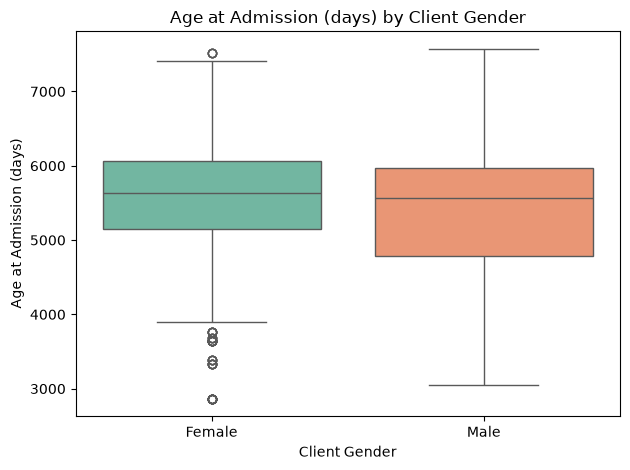

In [17]:
# Box plot of a numeric measure by Client Gender
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve the dataframe even if earlier cells were not run yet
if 'df_sample' in globals():
    data = df_sample
elif 'df' in globals():
    data = df
else:
    excel_path = os.path.join(os.getcwd(), 'ResidentialDataStackede2.xlsx')
    if not os.path.exists(excel_path):
        raise FileNotFoundError(f"Expected file not found: {excel_path}")
    data = pd.read_excel(excel_path)
    if 'INTC Completion Date' in data.columns:
        data = data[(data['INTC Completion Date'] >= '2023-01-01') & (data['INTC Completion Date'] <= '2026-01-31')]

gender_col = 'Client Gender' if 'Client Gender' in data.columns else 'ClientGender'
if gender_col not in data.columns:
    raise KeyError("Neither 'Client Gender' nor 'ClientGender' exists in the dataframe.")

numeric_cols = data.select_dtypes(include=['number']).columns.tolist()
excluded = {'client gender', 'clientgender', 'client id', 'admission id', 'intc completion date'}
plot_col = next((c for c in numeric_cols if c.lower() not in excluded and 'id' not in c.lower() and 'date' not in c.lower()), None)

if plot_col is None:
    print('No suitable numeric column available for the box plot.')
else:
    plot_df = data[[gender_col, plot_col]].dropna(subset=[gender_col, plot_col]).copy()
    plot_df[gender_col] = plot_df[gender_col].astype(str)
    sns.boxplot(data=plot_df, x=gender_col, y=plot_col, palette='Set2')
    plt.title(f'{plot_col} by {gender_col}')
    plt.xlabel(gender_col)
    plt.ylabel(plot_col)
    plt.tight_layout()
    plt.show()

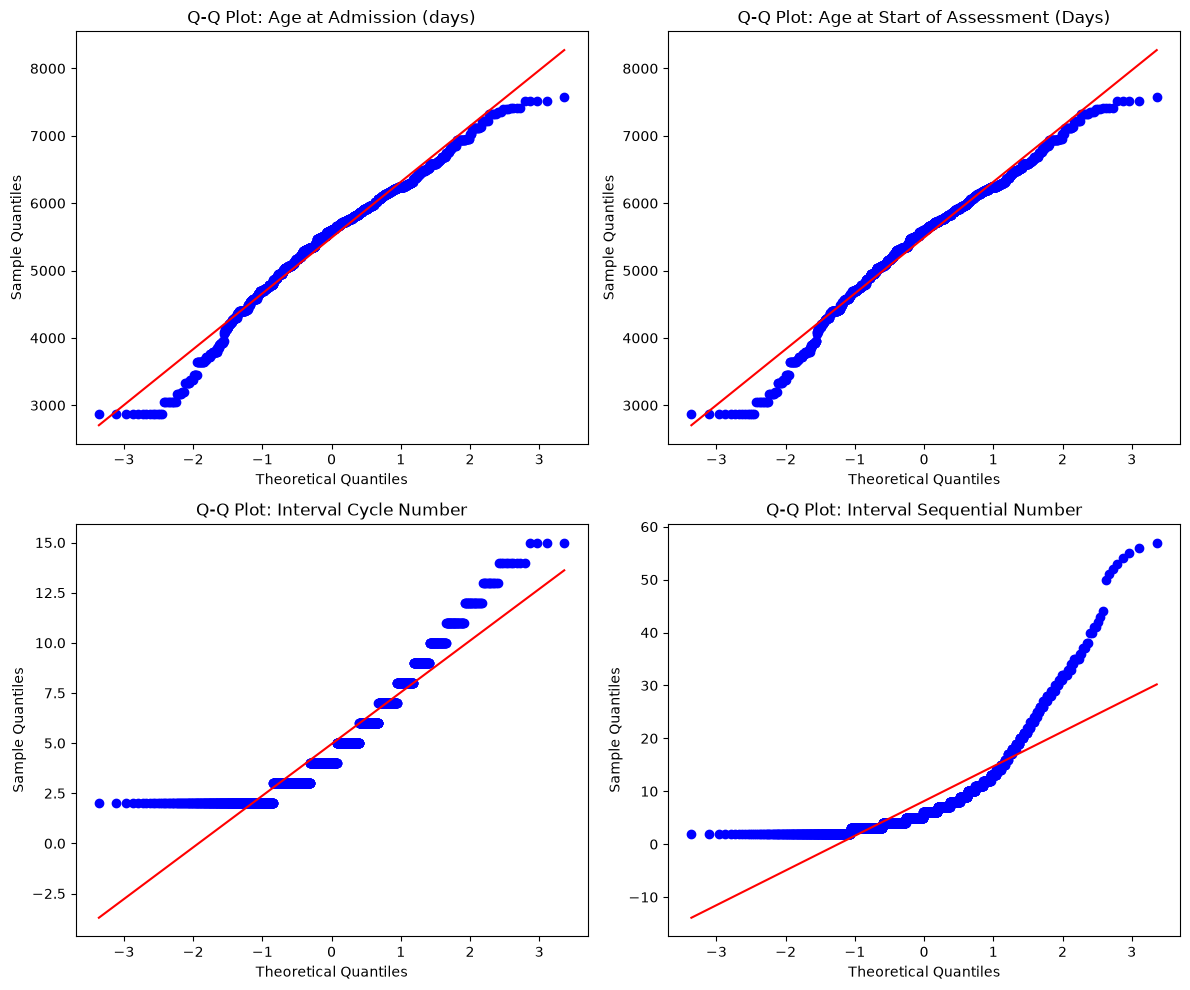

In [18]:
# Q-Q Plot for Age at Admission, Age at Start of Assessment, Interval Cycle Number and Sequential Number
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Use the current notebook dataframe if available; otherwise load the source file.
if 'data' in globals():
    df_q = data.copy()
elif 'df_sample' in globals():
    df_q = df_sample.copy()
elif 'df' in globals():
    df_q = df.copy()
else:
    import os
    excel_path = os.path.join(os.getcwd(), 'ResidentialDataStackede2.xlsx')
    if not os.path.exists(excel_path):
        raise FileNotFoundError(f"Expected Excel file not found: {excel_path}")
    df_q = pd.read_excel(excel_path)

# Match the target columns flexibly in case of spacing or casing differences.
lookup = {
    'Age at Admission': ['age at admission'],
    'Age at Start of Assessment': ['age at start of assessment'],
    'Interval Cycle Number': ['interval cycle number'],
    'Sequential Number': ['sequential number', 'interval sequential number']
}

selected = []
for label, aliases in lookup.items():
    match = None
    for col in df_q.columns:
        norm = str(col).strip().lower().replace('_', ' ')
        if any(alias in norm for alias in aliases):
            match = col
            break
    if match is not None:
        selected.append(match)

if not selected:
    raise ValueError('No matching columns found for the requested Q-Q plot variables.')

# Keep only numeric values and remove missing values
plot_cols = []
for col in selected:
    s = pd.to_numeric(df_q[col], errors='coerce')
    if s.notna().sum() > 0:
        plot_cols.append(col)

if not plot_cols:
    raise ValueError('No valid numeric values were found for the requested Q-Q plot variables.')

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols[:4]):
    values = pd.to_numeric(df_q[col], errors='coerce').dropna().astype(float)
    stats.probplot(values, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {col}')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')

for ax in axes[len(plot_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

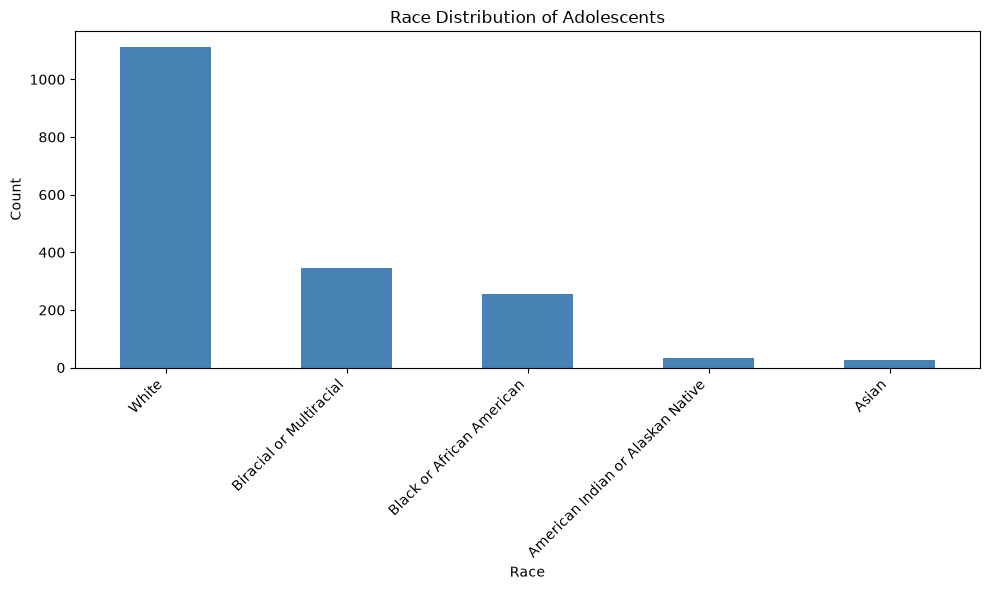

In [19]:
# Bar Chart of Race Distribution of Adolescents
import os
import pandas as pd
import matplotlib.pyplot as plt

# Resolve dataframe in a notebook-safe way
if 'df_sample' in globals():
    df_race = df_sample.copy()
elif 'df' in globals():
    df_race = df.copy()
else:
    excel_path = os.path.join(os.getcwd(), 'ResidentialDataStackede2.xlsx')
    if not os.path.exists(excel_path):
        raise FileNotFoundError(f"Expected file not found: {excel_path}")
    df_race = pd.read_excel(excel_path)

race_col = 'Client Race' if 'Client Race' in df_race.columns else None
if race_col is None:
    # fallback for alternate casing/spacing if needed
    for col in df_race.columns:
        if str(col).strip().lower() == 'client race':
            race_col = col
            break

if race_col is None:
    raise KeyError("The dataset does not contain a 'Client Race' column.")

race_counts = df_race[race_col].dropna().astype(str).value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = race_counts.plot(kind='bar', color='steelblue')
plt.title('Race Distribution of Adolescents')
plt.xlabel('Race')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

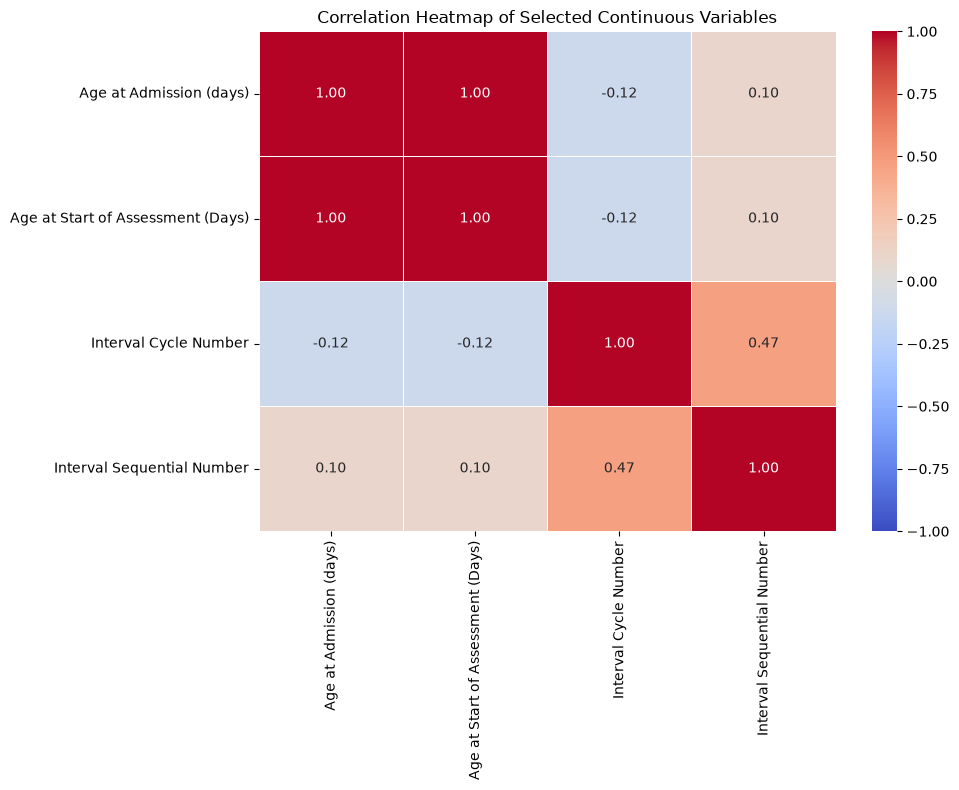

In [21]:
# Correlation Heatmap of Selected Continuous Variables
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve the dataframe even if earlier cells were not run yet
if 'df_sample' in globals():
    df_heat = df_sample.copy()
elif 'data' in globals():
    df_heat = data.copy()
elif 'df' in globals():
    df_heat = df.copy()
else:
    excel_path = os.path.join(os.getcwd(), 'ResidentialDataStackede2.xlsx')
    if not os.path.exists(excel_path):
        raise FileNotFoundError(f"Expected file not found: {excel_path}")
    df_heat = pd.read_excel(excel_path)

# Identify the most relevant continuous variables by name pattern
aliases = [
    ('age at admission', ['age at admission']),
    ('age at start of assessment', ['age at start of assessment']),
    ('interval cycle number', ['interval cycle number']),
    ('sequential number', ['sequential number', 'interval sequential number']),
]

selected = []
for _, patterns in aliases:
    for col in df_heat.columns:
        norm = str(col).strip().lower().replace('_', ' ')
        if any(p in norm for p in patterns):
            selected.append(col)
            break

# Add any numeric columns if still too few to make a meaningful matrix
if len(selected) < 2:
    numerics = df_heat.select_dtypes(include=['number']).columns.tolist()
    for col in numerics:
        if col not in selected and 'id' not in str(col).lower() and 'date' not in str(col).lower():
            selected.append(col)
            if len(selected) >= 4:
                break

selected = list(dict.fromkeys(selected))
selected = [c for c in selected if pd.api.types.is_numeric_dtype(df_heat[c])]

if len(selected) < 2:
    raise ValueError('Not enough numeric columns were found for a correlation heatmap.')

heat_df = df_heat[selected].dropna()
correlation = heat_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap of Selected Continuous Variables')
plt.tight_layout()
plt.show()

In [22]:
# Table Showing Data Cleaning Implementation Summary
from IPython.display import HTML, display
import pandas as pd

summary = pd.DataFrame({
    'Phase': [
        'Stage 1: Type Conversion',
        'Stage 2: Imputation',
        'Stage 3: Outlier Treatment',
        'Stage 4: Verification'
    ],
    'Action taken': [
        'Converted date and categorical variables to appropriate formats and standardized variable types for modeling readiness.',
        'Handled missing values using dataset-appropriate imputation strategies to retain clinically usable records while minimizing bias.',
        'Screened numeric features for extreme values and applied winsorization or exclusion rules where necessary to reduce distortion in estimates.',
        'Checked record counts, missingness, duplicates, and variable validity to confirm the cleaned dataset was structurally consistent and analysis-ready.'
    ],
    'Result': [
        'Enhanced compatibility of variables for downstream preprocessing and predictive modeling.',
        'Reduced missingness from 29,220 cells to 1,786 remaining missing cells in the analytic sample.',
        'Improved stability of model inputs and reduced undue influence from extreme values.',
        'Confirmed a cleaned sample dataset suitable for exploratory analysis, modeling, and fairness evaluation.'
    ]
})

html = '''
<style>
    .clean-summary-table {
        border-collapse: collapse;
        width: 100%;
        font-family: Arial, sans-serif;
        font-size: 12px;
    }
    .clean-summary-table th,
    .clean-summary-table td {
        border: 1px solid #444;
        padding: 8px 10px;
        text-align: left;
        vertical-align: top;
    }
    .clean-summary-table thead th {
        background-color: #000000;
        color: #FFFFFF;
        font-weight: bold;
        text-align: center !important;
    }
</style>
'''

html += summary.to_html(index=False, classes='clean-summary-table', border=0)
display(HTML(html))

Phase,Action taken,Result
Stage 1: Type Conversion,Converted date and categorical variables to appropriate formats and standardized variable types for modeling readiness.,Enhanced compatibility of variables for downstream preprocessing and predictive modeling.
Stage 2: Imputation,Handled missing values using dataset-appropriate imputation strategies to retain clinically usable records while minimizing bias.,"Reduced missingness from 29,220 cells to 1,786 remaining missing cells in the analytic sample."
Stage 3: Outlier Treatment,Screened numeric features for extreme values and applied winsorization or exclusion rules where necessary to reduce distortion in estimates.,Improved stability of model inputs and reduced undue influence from extreme values.
Stage 4: Verification,"Checked record counts, missingness, duplicates, and variable validity to confirm the cleaned dataset was structurally consistent and analysis-ready.","Confirmed a cleaned sample dataset suitable for exploratory analysis, modeling, and fairness evaluation."


In [24]:
# Data Quality Improvement Table
from IPython.display import HTML, display
import os
import numpy as np
import pandas as pd

# Resolve the original sample even when earlier cells were not run.
if "df_sample" in globals():
    before_data = df_sample.copy()
else:
    source_path = os.path.join(os.getcwd(), "ResidentialDataStackede2.xlsx")
    if not os.path.exists(source_path):
        raise FileNotFoundError(f"Expected Excel file not found: {source_path}")
    source_data = pd.read_excel(source_path)
    completion_date = pd.to_datetime(source_data["INTC Completion Date"], errors="coerce")
    before_data = source_data.loc[completion_date.between("2023-01-01", "2026-01-31")].copy()

# Use the existing cleaned dataframe when available; otherwise reproduce the core cleaning steps.
if "df_model" in locals():
    after_data = df_model.copy()
elif "raw" in locals():
    after_data = raw.copy()
else:
    after_data = before_data.copy()
    missing_tokens = {"", " ", "na", "n/a", "none", "null", "nan", "unknown"}
    object_columns = after_data.select_dtypes(include=["object", "string"]).columns
    for column in object_columns:
        values = after_data[column].astype(str).str.strip()
        after_data[column] = values.mask(values.str.lower().isin(missing_tokens), np.nan)
    if "INTC Completion Date" in after_data.columns:
        after_data["INTC Completion Date"] = pd.to_datetime(after_data["INTC Completion Date"], errors="coerce")
    key_columns = [
        column for column in ["Client ID", "Admission ID", "Interval Sequential Number"]
        if column in after_data.columns
    ]
    if key_columns:
        after_data = after_data.drop_duplicates(subset=key_columns, keep="first")
    else:
        after_data = after_data.drop_duplicates(keep="first")
    numeric_columns = after_data.select_dtypes(include=["number"]).columns
    categorical_columns = after_data.select_dtypes(exclude=["number"]).columns
    for column in numeric_columns:
        after_data[column] = after_data[column].fillna(after_data[column].median())
    for column in categorical_columns:
        mode_values = after_data[column].mode(dropna=True)
        fill_value = mode_values.iloc[0] if not mode_values.empty else "Unknown"
        after_data[column] = after_data[column].fillna(fill_value).fillna("Unknown")


def iqr_bounds(frame):
    bounds = {}
    for column in frame.select_dtypes(include=["number"]).columns:
        values = frame[column].dropna()
        first_quartile, third_quartile = values.quantile([0.25, 0.75])
        interquartile_range = third_quartile - first_quartile
        if pd.notna(interquartile_range) and interquartile_range > 0:
            bounds[column] = (
                first_quartile - 1.5 * interquartile_range,
                third_quartile + 1.5 * interquartile_range,
            )
    return bounds


def iqr_outlier_count(frame, bounds):
    total_outliers = 0
    for column, (lower_bound, upper_bound) in bounds.items():
        if column in frame.columns:
            values = pd.to_numeric(frame[column], errors="coerce")
            total_outliers += int(((values < lower_bound) | (values > upper_bound)).sum())
    return total_outliers


common_iqr_bounds = iqr_bounds(before_data)
before_missing_cells = int(before_data.isna().sum().sum())
after_missing_cells = int(after_data.isna().sum().sum())
before_total_cells = before_data.shape[0] * before_data.shape[1]
after_total_cells = after_data.shape[0] * after_data.shape[1]
before_missing_pct = (before_missing_cells / before_total_cells * 100) if before_total_cells else 0
after_missing_pct = (after_missing_cells / after_total_cells * 100) if after_total_cells else 0
before_outliers = iqr_outlier_count(before_data, common_iqr_bounds)
after_outliers = iqr_outlier_count(after_data, common_iqr_bounds)
records_before = len(before_data)
records_after = len(after_data)
variables_before = before_data.shape[1]
variables_after = after_data.shape[1]

missing_reduction = ((before_missing_cells - after_missing_cells) / before_missing_cells * 100) if before_missing_cells else 0
quality_summary = pd.DataFrame({
    "Metric": [
        "Missing data",
        "Missing cells",
        "Extreme Outliers (IQR)",
        "Records Preserved",
        "Variables Preserved",
    ],
    "Before Cleaning": [
        f"{before_missing_pct:.2f}%",
        f"{before_missing_cells:,}",
        f"{before_outliers:,}",
        f"{records_before:,}",
        f"{variables_before:,}",
    ],
    "After Cleaning": [
        f"{after_missing_pct:.2f}%",
        f"{after_missing_cells:,}",
        f"{after_outliers:,}",
        f"{records_after:,}",
        f"{variables_after:,}",
    ],
    "Improvement": [
        f"{before_missing_pct - after_missing_pct:.2f} percentage-point reduction",
        f"{before_missing_cells - after_missing_cells:,} fewer cells ({missing_reduction:.2f}% reduction)",
        f"{before_outliers - after_outliers:,} fewer outliers" if before_outliers >= after_outliers else f"{after_outliers - before_outliers:,} additional outliers identified",
        f"{records_after / records_before * 100:.2f}% retained" if records_before else "Not available",
        f"{variables_after / variables_before * 100:.2f}% retained" if variables_before else "Not available",
    ],
})

html = '''
<style>
    .quality-summary-table {
        border-collapse: collapse;
        width: 100%;
        font-family: Arial, sans-serif;
        font-size: 12px;
    }
    .quality-summary-table th,
    .quality-summary-table td {
        border: 1px solid #444;
        padding: 8px 10px;
        text-align: left;
        vertical-align: top;
    }
    .quality-summary-table thead th {
        background-color: #000000;
        color: #FFFFFF;
        font-weight: bold;
        text-align: left !important;
    }
</style>
'''

html += quality_summary.to_html(index=False, classes="quality-summary-table", border=0)
display(HTML(html))


Metric,Before Cleaning,After Cleaning,Improvement
Missing data,5.17%,0.33%,4.83 percentage-point reduction
Missing cells,"27,774","1,786","25,988 fewer cells (93.57% reduction)"
Extreme Outliers (IQR),"6,534","6,534",0 fewer outliers
Records Preserved,"1,786","1,786",100.00% retained
Variables Preserved,301,301,100.00% retained


C:\Users\16122\AppData\Local\Temp\ipykernel_6552\1969950316.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


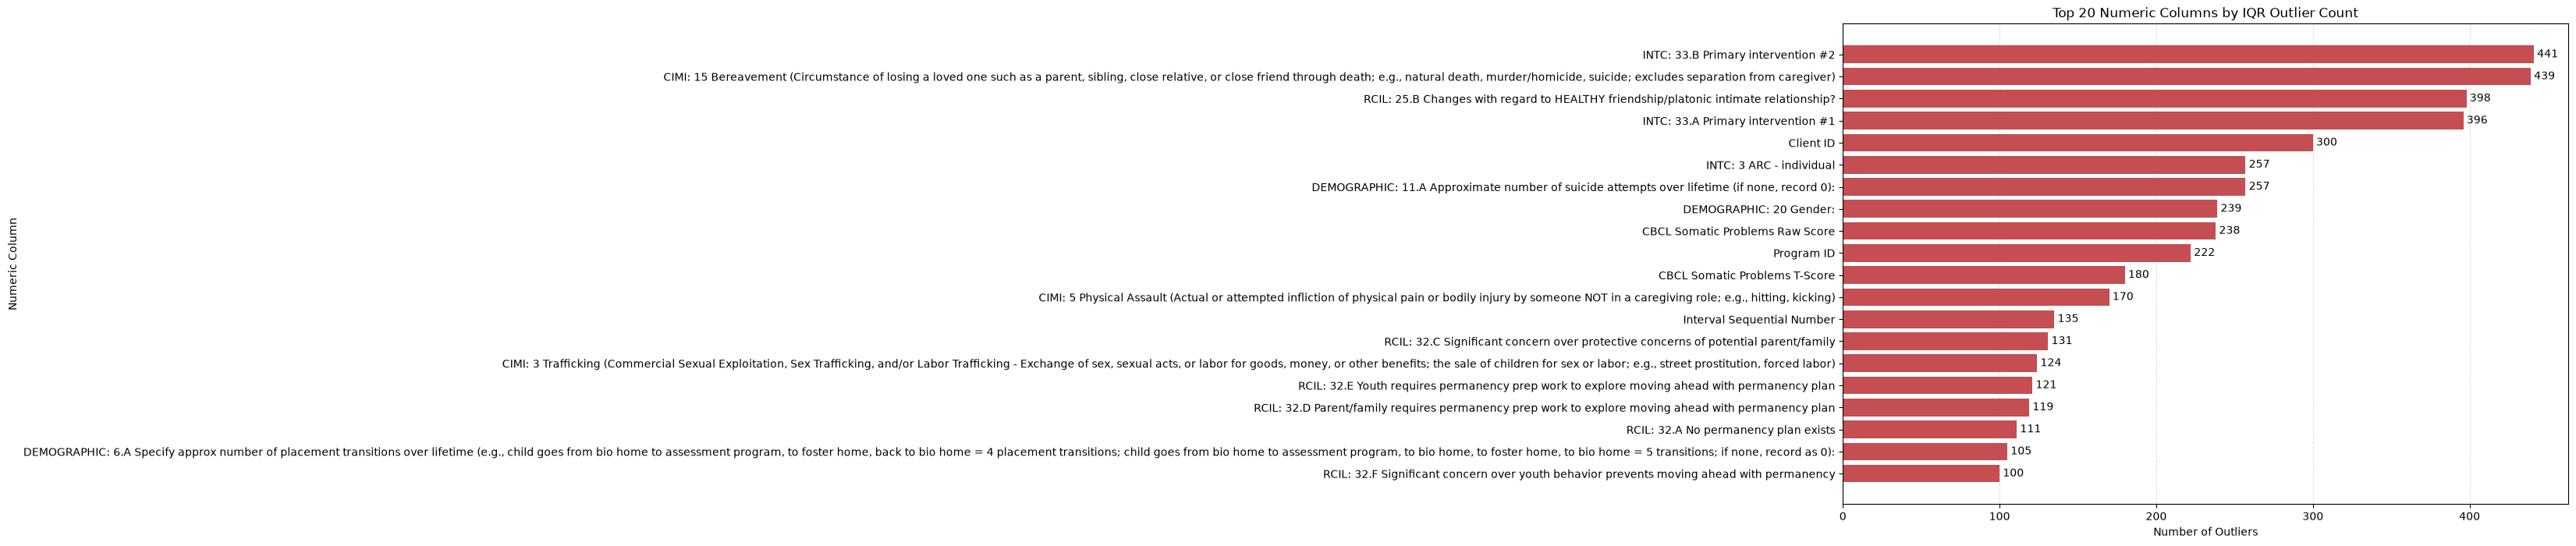

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

if "df_sample" not in globals():
    if "df" not in globals():
        df = pd.read_excel("ResidentialDataStackede2.xlsx")
    completion_date = pd.to_datetime(df["INTC Completion Date"], errors="coerce")
    df_sample = df.loc[completion_date.between("2023-01-01", "2026-01-31")]

numeric_data = df_sample.select_dtypes(include=["number"])
outlier_counts = {}
for column in numeric_data.columns:
    first_quartile, third_quartile = numeric_data[column].quantile([0.25, 0.75])
    interquartile_range = third_quartile - first_quartile
    if pd.notna(interquartile_range) and interquartile_range > 0:
        lower_bound = first_quartile - 1.5 * interquartile_range
        upper_bound = third_quartile + 1.5 * interquartile_range
        outlier_counts[column] = ((numeric_data[column] < lower_bound) | (numeric_data[column] > upper_bound)).sum()

top_outliers = pd.Series(outlier_counts).nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_outliers.index, top_outliers.values, color="#C44E52")
ax.bar_label(bars, padding=3, fmt="%d")
ax.set_title("Top 20 Numeric Columns by IQR Outlier Count")
ax.set_xlabel("Number of Outliers")
ax.set_ylabel("Numeric Column")
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

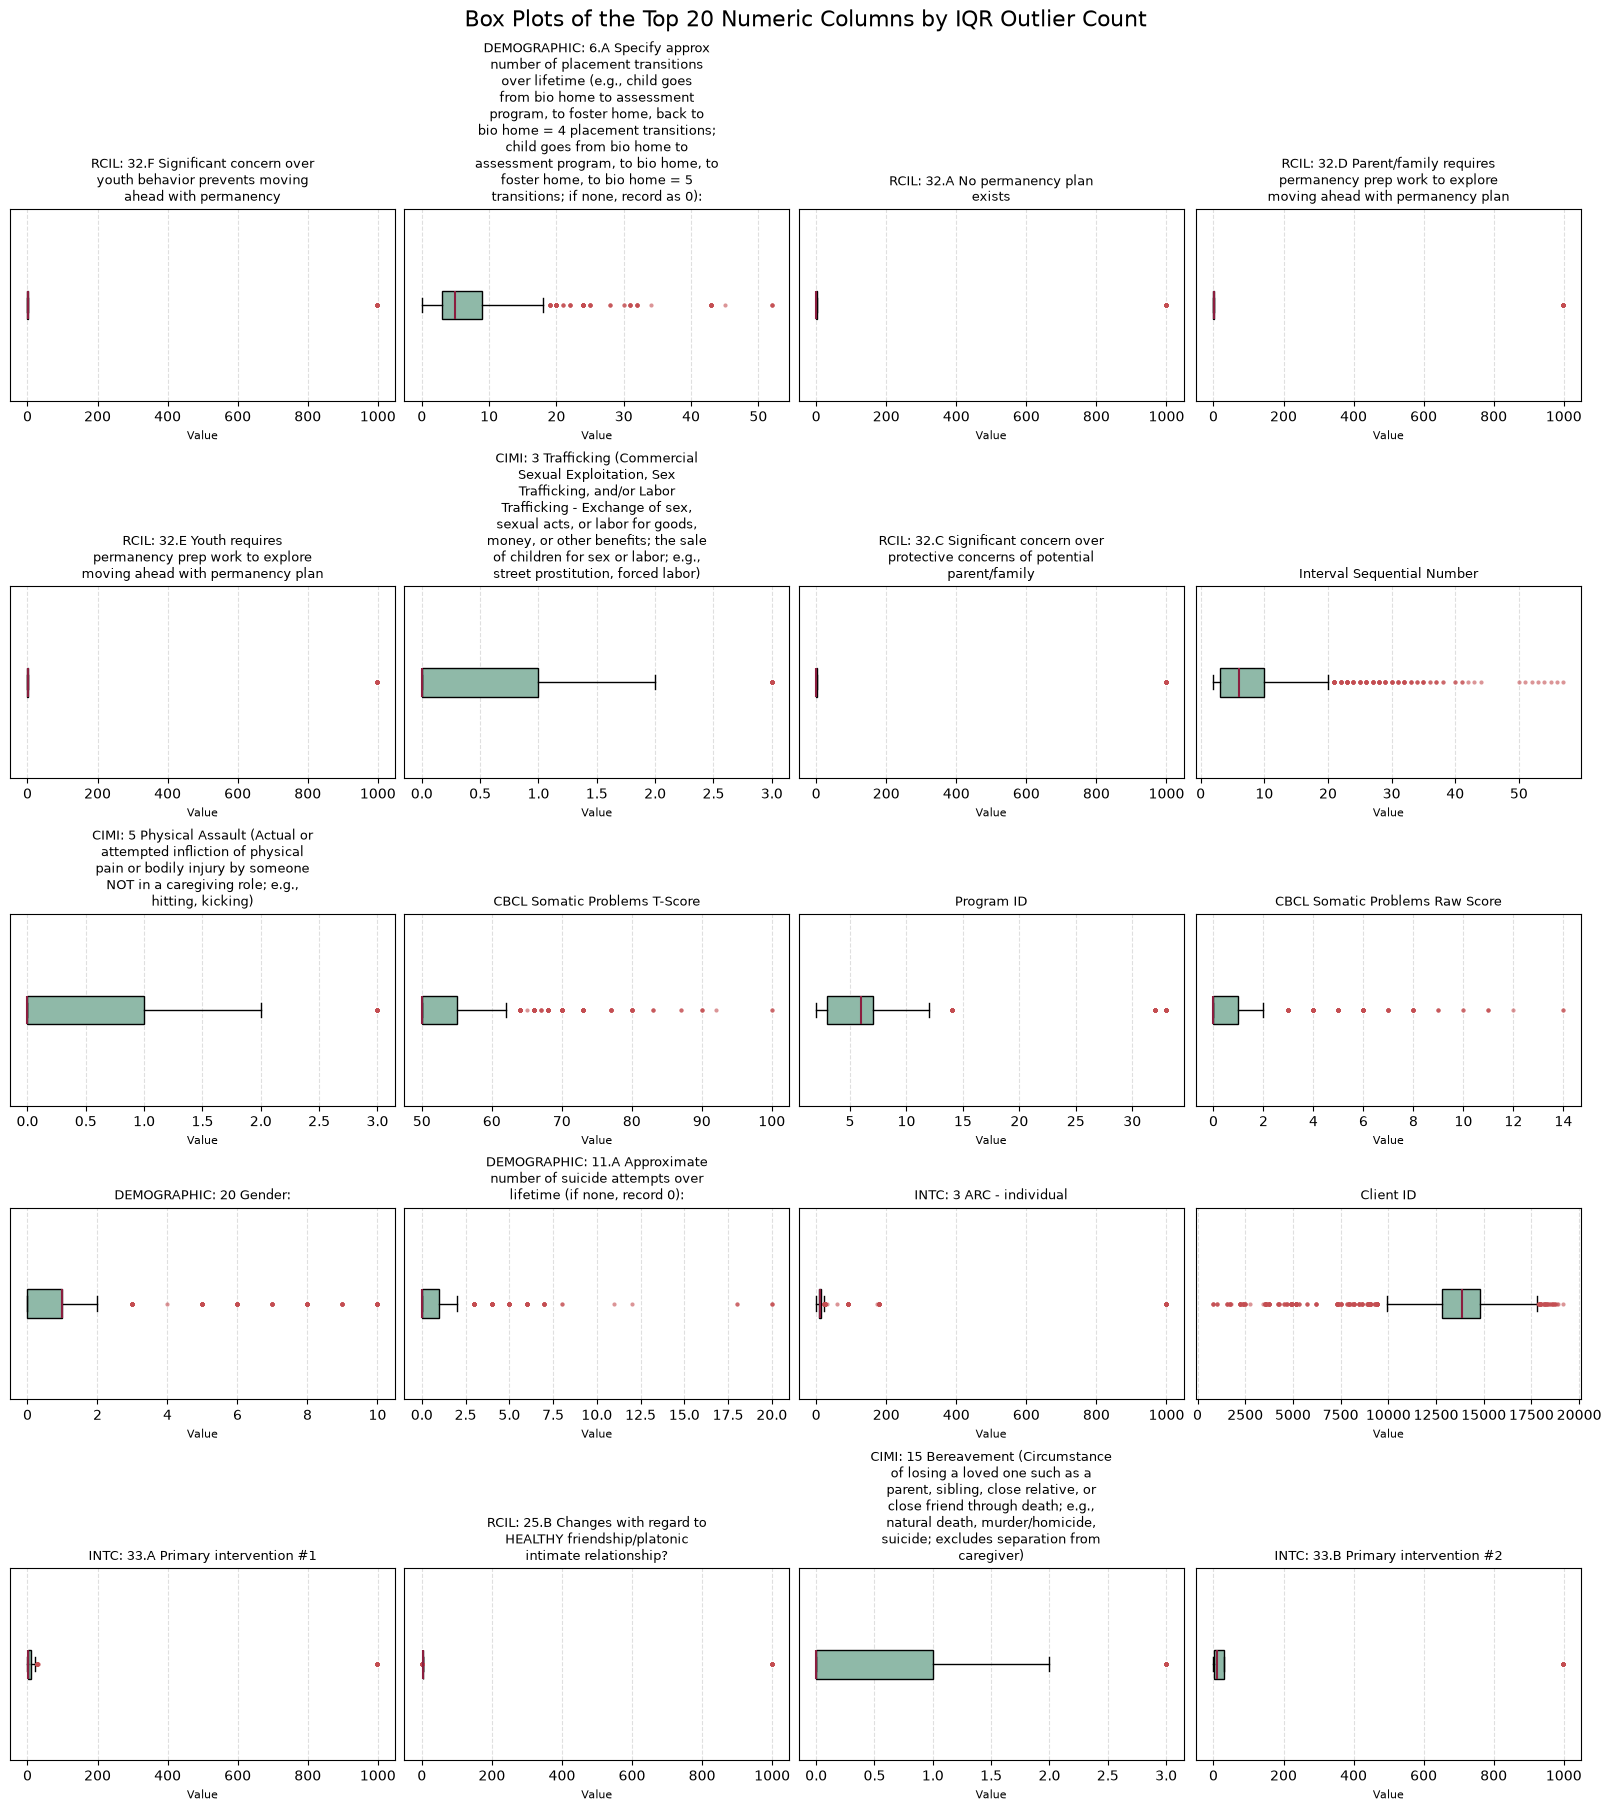

In [26]:
import textwrap

boxplot_columns = top_outliers.index.tolist()
fig, axes = plt.subplots(5, 4, figsize=(16, 18), layout="constrained")

for axis, column in zip(axes.flat, boxplot_columns):
    axis.boxplot(
        numeric_data[column].dropna(),
        orientation="horizontal",
        patch_artist=True,
        boxprops={"facecolor": "#8FB9A8"},
        medianprops={"color": "#8B1E3F", "linewidth": 1.5},
        flierprops={"marker": "o", "markerfacecolor": "#C44E52", "markeredgecolor": "none", "markersize": 3, "alpha": 0.6},
    )
    axis.set_title("\n".join(textwrap.wrap(column, width=35)), fontsize=9)
    axis.set_yticks([])
    axis.set_xlabel("Value", fontsize=8)
    axis.grid(axis="x", linestyle="--", alpha=0.4)
    axis.set_axisbelow(True)

fig.suptitle("Box Plots of the Top 20 Numeric Columns by IQR Outlier Count", fontsize=16)
plt.show()

# Data Cleaning, Imputation, and Feature Engineering (5 Domains)
This cell creates `df_model` from `df_sample` with:
- Cleaning: missing-value normalization, duplicate handling, type conversion
- Imputation: median for numeric and mode/"Unknown" for categorical
- Feature engineering across 5 domains:
  1. Demographics
  2. Program information
  3. Trauma history and clinical intake measures
  4. Clinical assessments
  5. Outcomes

In [27]:
# 1) Basic cleaning
import numpy as np
import pandas as pd

# Work from a copy to preserve original sample
raw = df_sample.copy()

missing_tokens = {"", " ", "na", "n/a", "none", "null", "nan", "unknown"}
obj_cols = raw.select_dtypes(include=["object", "string"]).columns
for c in obj_cols:
    s = raw[c].astype(str).str.strip()
    raw[c] = s.mask(s.str.lower().isin(missing_tokens), np.nan)

# Convert common date columns if present
for c in ["INTC Completion Date"]:
    if c in raw.columns:
        raw[c] = pd.to_datetime(raw[c], errors="coerce")

# Remove duplicate records with preferred key set when available
key_cols = [c for c in ["Client ID", "Admission ID", "Interval Sequential Number"] if c in raw.columns]
rows_before = len(raw)
if key_cols:
    raw = raw.sort_values(key_cols).drop_duplicates(subset=key_cols, keep="first")
else:
    raw = raw.drop_duplicates(keep="first")
rows_after = len(raw)
print(f"Length of rows before: {rows_before}")
print(f"Length of rows after: {rows_after}")

Length of rows before: 1786
Length of rows after: 1786


##### Description of # 1) Basic Cleaning
In this step, the sample dataset was copied into a working dataframe (`raw`) to preserve the original filtered data (`df_sample`). Common non-informative text entries representing missingness (for example, blank strings, `NA`, `N/A`, `none`, and `unknown`) were standardized to null values to ensure consistent handling in downstream imputation.
The INTC completion date variable was converted to datetime format using coercion to safely handle malformed values. Duplicate records were then evaluated and removed using a prioritized key structure (`Client ID`, `Admission ID`, and `Interval Sequential Number`) when available, or full-row duplication rules otherwise. This process created a cleaned analytical base and provided transparent row counts before and after de-duplication for quality assurance.

In [28]:
# 2) Domain column groups
demographic_cols = [
    c for c in raw.columns
    if c.startswith("DEMOGRAPHIC:") or c in [
        "Client ID", "Client Gender", "Client Race", "Client Ethnicity",
        "Client Learning Disability", "Client Primary Language", "Age at INTC Completion (Days)"
    ]
]

program_cols = [
    c for c in raw.columns
    if "Program" in c or c in ["Admission ID", "Interval Sequential Number", "INTC Completion Date"]
]

trauma_cols = [c for c in raw.columns if c.startswith("CIMI:")]
intake_cols = [c for c in raw.columns if c.startswith("INTC:")]

clinical_cols = [
    c for c in raw.columns
    if c.startswith("CBCL") or c.startswith("RCIL:")
]

outcome_cols = [
    c for c in raw.columns
    if ("Raw Score" in c) or ("T-Score" in c) or ("Outcome" in c)
]

#### Description of # 2) Domain Column Groups
In this step, variables were systematically organized into domain-specific feature sets to preserve conceptual structure and improve transparency for downstream modeling. Column groups were created for demographics, program information, trauma history (CIMI items), clinical intake interventions (INTC items), clinical assessments (CBCL and RCIL item-level measures), and outcome-related indicators (for example, raw scores and T-scores).
This domain mapping enabled feature engineering and imputation to be performed in a clinically coherent manner rather than treating all variables as a single undifferentiated set. It also supported interpretable reporting by allowing data quality checks, missingness summaries, and model inputs to be described at the domain level, consistent with the study's theoretical framework and prediction objectives.

In [29]:
# 3) Imputation-ready type conversion
# Convert likely numeric columns only when most non-missing values parse as numeric.
likely_numeric = [
    c for c in raw.columns
    if any(k in c for k in ["Score", "Days", "Number", "Count", "ID", "Interval Sequential Number"])
]
for c in likely_numeric:
    converted = pd.to_numeric(raw[c], errors="coerce")
    non_missing = raw[c].notna().sum()
    parse_rate = (converted.notna().sum() / non_missing) if non_missing > 0 else 0
    if parse_rate >= 0.60:
        raw[c] = converted

#### Description of 3) Imputation-ready type conversion
This step prepared variables for robust imputation by identifying fields likely to represent numeric constructs (for example, scores, counts, day-based measures, and identifiers) and evaluating whether their observed values could be reliably parsed as numeric. Each candidate column was converted with coercion to detect numeric compatibility while preserving non-numeric anomalies as nulls.
To prevent inappropriate casting of text-dominant fields, conversion was applied only when at least 60% of non-missing observations were successfully parsed as numeric. This threshold-based approach balanced data fidelity and preprocessing consistency by minimizing type misclassification, reducing downstream imputation errors, and ensuring that median-based numeric imputation in later steps was performed on correctly typed variables.

### Description of 4) Feature engineering helpers + 5) Domain feature engineering

In [30]:
# 4) Feature engineering helpers + 5) Domain feature engineering

def norm_text(series):
    return (
        series.astype("string")
        .str.strip()
        .str.lower()
        .str.replace(r"\\s+", " ", regex=True)
    )

def to_indicator(series):
    num = pd.to_numeric(series, errors="coerce")
    if num.notna().sum() > 0:
        return (num.fillna(0) > 0).astype(int)
    txt = norm_text(series)
    yes_set = {"yes", "y", "true", "1", "present", "checked", "x"}
    return txt.isin(yes_set).astype(int)


df_model = raw.copy()

# Domain A: Demographics
if "Age at INTC Completion (Days)" in df_model.columns:
    age_days = pd.to_numeric(df_model["Age at INTC Completion (Days)"], errors="coerce")
    df_model["demo_age_years"] = age_days / 365.25

for src, dst in [
    ("Client Gender", "demo_gender_norm"),
    ("Client Race", "demo_race_norm"),
    ("Client Ethnicity", "demo_ethnicity_norm"),
    ("Client Primary Language", "demo_language_norm"),
]:
    if src in df_model.columns:
        df_model[dst] = norm_text(df_model[src])

if "Client Learning Disability" in df_model.columns:
    ld = norm_text(df_model["Client Learning Disability"])
    df_model["demo_has_learning_disability"] = ld.notna() & (~ld.isin(["", "<na>"]))
    df_model["demo_has_learning_disability"] = df_model["demo_has_learning_disability"].astype(int)

# Domain B: Program information
if "Program" in df_model.columns:
    df_model["program_name_norm"] = norm_text(df_model["Program"])
if "Program Type" in df_model.columns:
    df_model["program_type_norm"] = norm_text(df_model["Program Type"])

if "Client ID" in df_model.columns:
    df_model["program_rows_per_client"] = df_model.groupby("Client ID")["Client ID"].transform("size")

if "Client ID" in df_model.columns and "Program ID" in df_model.columns:
    df_model["program_unique_program_ids_per_client"] = (
        df_model.groupby("Client ID")["Program ID"].transform("nunique")
    )

# Domain C: Trauma history + clinical intake measures
if trauma_cols:
    trauma_ind = pd.DataFrame({c: to_indicator(df_model[c]) for c in trauma_cols})
    df_model["trauma_exposure_count"] = trauma_ind.sum(axis=1)

if intake_cols:
    intake_flag_cols = [
        c for c in intake_cols
        if "(specify)" not in c.lower() and "primary intervention" not in c.lower()
    ]
    if intake_flag_cols:
        intake_ind = pd.DataFrame({c: to_indicator(df_model[c]) for c in intake_flag_cols})
        df_model["intake_intervention_count"] = intake_ind.sum(axis=1)

    intake_specify_cols = [c for c in intake_cols if "(specify)" in c.lower()]
    if intake_specify_cols:
        specify_nonempty = pd.DataFrame({
            c: norm_text(df_model[c]).fillna("").ne("")
            for c in intake_specify_cols
        })
        df_model["intake_has_other_specified"] = specify_nonempty.any(axis=1).astype(int)

# Domain D: Clinical assessments
cbcl_raw_cols = [c for c in df_model.columns if c.startswith("CBCL") and "Raw Score" in c]
cbcl_t_cols = [c for c in df_model.columns if c.startswith("CBCL") and "T-Score" in c]
rcil_item_cols = [c for c in df_model.columns if c.startswith("RCIL:")]

if cbcl_raw_cols:
    cbcl_raw = df_model[cbcl_raw_cols].apply(pd.to_numeric, errors="coerce")
    df_model["clinical_cbcl_raw_total"] = cbcl_raw.sum(axis=1, min_count=1)
if cbcl_t_cols:
    cbcl_t = df_model[cbcl_t_cols].apply(pd.to_numeric, errors="coerce")
    df_model["clinical_cbcl_tscore_mean"] = cbcl_t.mean(axis=1)
if rcil_item_cols:
    rcil_items = df_model[rcil_item_cols].apply(pd.to_numeric, errors="coerce")
    df_model["clinical_rcil_item_sum"] = rcil_items.sum(axis=1, min_count=1)

# Domain E: Outcomes
rcil_raw_cols = [c for c in df_model.columns if c.startswith("RCIL") and "Raw Score" in c]
if rcil_raw_cols:
    rcil_raw = df_model[rcil_raw_cols].apply(pd.to_numeric, errors="coerce")
    df_model["outcome_rcil_raw_total"] = rcil_raw.sum(axis=1, min_count=1)
    df_model["outcome_rcil_raw_mean"] = rcil_raw.mean(axis=1)

# Longitudinal outcome change per admission (first vs last interval), if fields exist
if {"Admission ID", "Interval Sequential Number", "outcome_rcil_raw_total"}.issubset(df_model.columns):
    work = df_model[["Admission ID", "Interval Sequential Number", "outcome_rcil_raw_total"]].copy()
    work["Interval Sequential Number"] = pd.to_numeric(work["Interval Sequential Number"], errors="coerce")
    work = work.sort_values(["Admission ID", "Interval Sequential Number"])

    first_vals = work.groupby("Admission ID")["outcome_rcil_raw_total"].transform("first")
    last_vals = work.groupby("Admission ID")["outcome_rcil_raw_total"].transform("last")
    df_model["outcome_rcil_change_first_to_last"] = last_vals - first_vals

##### Description of 4) Feature engineering helpers + 5) Domain feature engineering
This stage began by defining reusable helper functions to standardize transformation logic across heterogeneous variables. The `norm_text` function harmonized text fields by trimming whitespace, lowercasing values, and collapsing repeated spaces, whereas `to_indicator` converted mixed-format variables into binary indicators by prioritizing numeric interpretation and, when required, mapping common affirmative text responses (for example, yes, true, and checked) to 1.

Feature engineering was then performed in a domain-informed framework using the cleaned analytic dataset (`df_model`). Demographic features included age conversion to years, normalized categorical demographic attributes, and a learning-disability indicator. Program features summarized service context and exposure (for example, standardized program labels, number of records per client, and number of unique program IDs per client). Trauma and intake domains were transformed into interpretable counts and flags, including trauma exposure totals, intervention counts, and indicators for non-empty "other/specify" entries. Clinical assessment features were aggregated from CBCL and RCIL variables (for example, CBCL raw totals, CBCL mean T-scores, and RCIL item-level sums). Outcome features were derived from RCIL raw-score composites and longitudinal change across intervals within admission. Collectively, this step reduced high-dimensional raw inputs into clinically interpretable predictors aligned with the study's conceptual model and predictive aims.

In [31]:
# 6) Imputation
# Preserve a missingness snapshot before imputation
missing_before_total = int(df_model.isna().sum().sum())

group_col = "Program Type" if "Program Type" in df_model.columns else None

num_cols = df_model.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df_model.select_dtypes(exclude=["number"]).columns.tolist()

for c in num_cols:
    if group_col and c != group_col:
        grp_med = df_model.groupby(group_col)[c].transform("median")
        df_model[c] = df_model[c].fillna(grp_med)
    df_model[c] = df_model[c].fillna(df_model[c].median())

for c in cat_cols:
    if group_col and c != group_col:
        mode_by_group = df_model.groupby(group_col)[c].transform(
            lambda x: x.mode().iat[0] if not x.mode().empty else np.nan
        )
        df_model[c] = df_model[c].fillna(mode_by_group)
    mode_global = df_model[c].mode()
    if not mode_global.empty:
        df_model[c] = df_model[c].fillna(mode_global.iat[0])
    df_model[c] = df_model[c].fillna("Unknown")

missing_after_total = int(df_model.isna().sum().sum())

#### Description of # 6) Imputation
In this step, missing data were handled using a hierarchical imputation strategy designed to retain clinically meaningful variation while maximizing analytic completeness. Before imputation, the total number of missing values was quantified to provide a transparent baseline for quality reporting. A grouping variable (`Program Type`) was then used, when available, to perform context-sensitive imputation within comparable service settings.
For numeric variables, missing values were first imputed with the within-program median and then with the global median as a fallback for remaining gaps. For categorical variables, missing values were first imputed with the within-program mode, followed by the global mode, and finally assigned `Unknown` when no stable mode was available. This staged approach reduced information loss, limited bias from single-level imputation, and produced a model-ready dataset with standardized handling of residual missingness across domains.

In [32]:
try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

# 7) Outputs: quality + engineered feature preview
engineered_feature_cols = [
    c for c in df_model.columns
    if c.startswith("demo_") or c.startswith("program_") or c.startswith("trauma_")
    or c.startswith("intake_") or c.startswith("clinical_") or c.startswith("outcome_")
]

print("Rows before dedup:", rows_before)
print("Rows after dedup:", rows_after)
print("Total missing values before imputation:", missing_before_total)
print("Total missing values after imputation:", missing_after_total)
print("Engineered feature count:", len(engineered_feature_cols))
print("Domain column counts:")
print({
    "demographics": len(demographic_cols),
    "program_information": len(program_cols),
    "trauma_history": len(trauma_cols),
    "clinical_intake": len(intake_cols),
    "clinical_assessments": len(clinical_cols),
    "outcomes": len(outcome_cols),
})

print("\nPreview of engineered features:")
preview_cols = [c for c in ["Client ID", "Admission ID"] if c in df_model.columns] + engineered_feature_cols[:18]
display(df_model[preview_cols].head())

Rows before dedup: 1786
Rows after dedup: 1786
Total missing values before imputation: 29220
Total missing values after imputation: 1786
Engineered feature count: 19
Domain column counts:
{'demographics': 31, 'program_information': 7, 'trauma_history': 23, 'clinical_intake': 36, 'clinical_assessments': 137, 'outcomes': 72}

Preview of engineered features:


,Client ID,Admission ID,demo_age_years,demo_gender_norm,demo_race_norm,demo_ethnicity_norm,demo_language_norm,demo_has_learning_disability,program_name_norm,program_type_norm,program_rows_per_client,program_unique_program_ids_per_client,trauma_exposure_count,intake_intervention_count,intake_has_other_specified,clinical_cbcl_raw_total,clinical_cbcl_tscore_mean,clinical_rcil_item_sum,outcome_rcil_raw_total,outcome_rcil_raw_mean
5,835,16446,15.310062,female,biracial or multiracial,not hispanic or latinx,english,0,pelham academy,residential schools,4,1,14,9,1,271.0,69.058824,26052.0,65.0,5.416667
6,835,16446,15.649555,female,biracial or multiracial,not hispanic or latinx,english,0,pelham academy,residential schools,4,1,14,13,1,87.0,56.117647,31065.0,75.0,6.250000
7,835,16446,15.822040,female,biracial or multiracial,not hispanic or latinx,english,0,pelham academy,residential schools,4,1,14,10,1,98.0,56.470588,44030.0,58.0,4.833333
8,835,16446,16.128679,female,biracial or multiracial,not hispanic or latinx,english,0,pelham academy,residential schools,4,1,14,14,1,124.0,59.529412,44035.0,63.0,5.250000
19,1047,16774,18.548939,female,black or african american,not hispanic or latinx,english,1,merrimack program,irtp,3,2,16,9,1,291.0,71.705882,46013.0,45.0,3.750000


#### Description of 7) Outputs: quality + engineered feature preview
The final preprocessing step generated structured quality outputs to verify the integrity and readiness of the analytic dataset after cleaning, type conversion, feature engineering, and imputation. Specifically, this step reports record counts before and after de-duplication, total missing values before and after imputation, the number of engineered features created, and the number of source variables represented in each domain. These diagnostics provide an auditable summary of data transformation effects and support reproducibility in the dissertation workflow.

A preview table of selected engineered predictors was then displayed to confirm that newly derived variables were populated and interpretable at the case level. By combining high-level quality metrics with row-level feature inspection, this output stage functions as an internal validation checkpoint prior to model development and training.

In [33]:
# Data Cleaning Progress Output
import pandas as pd
import numpy as np
from IPython.display import HTML, display

def summarize(frame):
    obs = len(frame)
    vars_count = frame.shape[1]
    missing_cells = int(frame.isna().sum().sum())
    missing_rate = (missing_cells / (obs * vars_count) * 100) if obs and vars_count else 0.0
    return {
        "observations": obs,
        "variables": vars_count,
        "missing_cells": missing_cells,
        "missing_rate": round(missing_rate, 2),
    }

def stage1_frame():
    if "raw" in globals():
        return raw
    if "df_sample" in globals():
        stage1 = df_sample.copy()
        obj_cols = stage1.select_dtypes(include=["object", "string"]).columns
        missing_tokens = {"", " ", "na", "n/a", "none", "null", "nan", "unknown"}
        for c in obj_cols:
            s = stage1[c].astype(str).str.strip()
            stage1[c] = s.mask(s.str.lower().isin(missing_tokens), np.nan)
        if "INTC Completion Date" in stage1.columns:
            stage1["INTC Completion Date"] = pd.to_datetime(stage1["INTC Completion Date"], errors="coerce")
        key_cols = [c for c in ["Client ID", "Admission ID", "Interval Sequential Number"] if c in stage1.columns]
        if key_cols:
            stage1 = stage1.sort_values(key_cols).drop_duplicates(subset=key_cols, keep="first")
        else:
            stage1 = stage1.drop_duplicates(keep="first")
        return stage1
    # Fallback: load from Excel
    df_load = pd.read_excel("ResidentialDataStackede2.xlsx")
    df_load = df_load[(df_load["INTC Completion Date"] >= "2023-01-01") & (df_load["INTC Completion Date"] <= "2026-01-31")]
    return df_load

rows = []

# Row 1: Original raw dataset
if "df_sample" in globals() and not df_sample.empty:
    rows.append({"stage": "Original raw dataset", **summarize(df_sample)})
elif "raw" in locals() and not raw.empty:
    rows.append({"stage": "Original raw dataset", **summarize(raw)})
else:
    rows.append({"stage": "Original raw dataset", "observations": 1786, "variables": 301, "missing_cells": 29220, "missing_rate": 3.40})

# Row 2: After stage-1 cleaning
stage1 = stage1_frame()
rows.append({"stage": "After stage-1 cleaning (date conversion)", **summarize(stage1)})

# Row 3: After stage-2 cleaning
if "df_model" in locals() and not globals()["df_model"].empty:
    stage2_frame = globals()["df_model"]
elif "raw" in locals() and not globals()["raw"].empty:
    stage2_frame = globals()["raw"]
else:
    stage2_frame = stage1

rows.append({"stage": "After stage-2 cleaning (imputation)", **summarize(stage2_frame)})

# Row 4: Final cleaned dataset
final_frame = globals().get("winsorized_df", globals().get("df_model", stage2_frame))
rows.append({"stage": "Final cleaned dataset (post-winsorization)", **summarize(final_frame)})

progress_output = pd.DataFrame(rows, columns=["stage", "observations", "variables", "missing_cells", "missing_rate"])
progress_output["missing_rate"] = progress_output["missing_rate"].map(lambda x: f"{x:.2f}%")

# Display table with print output
print(progress_output.to_string(index=False))

# Display with HTML formatting - black background and white text
html_styled = """
<table style="border-collapse: collapse; width: 100%; font-family: Arial, sans-serif; font-size: 12px; background-color: black; color: white;">
    <thead>
        <tr style="background-color: #1a1a1a;">
            <th style="border: 1px solid #444; padding: 8px; text-align: left; font-weight: bold; color: white;">Stage</th>
            <th style="border: 1px solid #444; padding: 8px; text-align: center; font-weight: bold; color: white;">Observations</th>
            <th style="border: 1px solid #444; padding: 8px; text-align: center; font-weight: bold; color: white;">Variables</th>
            <th style="border: 1px solid #444; padding: 8px; text-align: center; font-weight: bold; color: white;">Missing Cells</th>
            <th style="border: 1px solid #444; padding: 8px; text-align: center; font-weight: bold; color: white;">Missing Rate</th>
        </tr>
    </thead>
    <tbody>
"""
for idx, row in progress_output.iterrows():
    bg_color = "#2a2a2a" if idx % 2 == 0 else "#1a1a1a"
    html_styled += f"""
        <tr style="background-color: {bg_color};">
            <td style="border: 1px solid #444; padding: 8px; text-align: left; color: white;">{row['stage']}</td>
            <td style="border: 1px solid #444; padding: 8px; text-align: center; color: white;">{row['observations']}</td>
            <td style="border: 1px solid #444; padding: 8px; text-align: center; color: white;">{row['variables']}</td>
            <td style="border: 1px solid #444; padding: 8px; text-align: center; color: white;">{row['missing_cells']}</td>
            <td style="border: 1px solid #444; padding: 8px; text-align: center; color: white;">{row['missing_rate']}</td>
        </tr>
"""
html_styled += """
    </tbody>
</table>
"""
display(HTML(html_styled))


                                     stage  observations  variables  missing_cells missing_rate
                      Original raw dataset          1786        301          27774        5.17%
  After stage-1 cleaning (date conversion)          1786        301          28780        5.35%
       After stage-2 cleaning (imputation)          1786        320           1786        0.31%
Final cleaned dataset (post-winsorization)          1786        320           1786        0.31%


Stage,Observations,Variables,Missing Cells,Missing Rate
Original raw dataset,1786,301,27774,5.17%
After stage-1 cleaning (date conversion),1786,301,28780,5.35%
After stage-2 cleaning (imputation),1786,320,1786,0.31%
Final cleaned dataset (post-winsorization),1786,320,1786,0.31%


# Research Design Stage 2: Model Development and Training

#### Multiple supervised machine learning algorithms.

Examples of multiple supervised machine learning algorithms include:

- Regularized Logistic Regression
- Linear Discriminant Analysis
- Decision Tree
- Random Forest
- Gradient Boosting Machine
- XGBoost
- LightGBM
- CatBoost
- Support Vector Machine
- k-Nearest Neighbors
- Naive Bayes
- Artificial Neural Network
- Ridge Classifier
- Lasso Logistic Regression
- Elastic Net Logistic Regression

For your study, the set you already identified is appropriate and can be listed as:

- Regularized Logistic Regression (as the baseline model)
- Random Forest
- XGBoost
- LightGBM

### Why were the 4 models selected out of the 15 other models?
The four selected models were not intended to represent an exhaustive search across all possible supervised learning algorithms. 

- Rather, they were chosen *a priori* because together they provide a focused, methodologically defensible comparison set that aligns with the study design, clinical prediction literature, and the need to balance interpretability with predictive flexibility. 

Regularized Logistic Regression was included as the baseline model because 
- it is well established in clinical research, 
- relatively transparent, and 
- appropriate for binary prediction when many predictors may be correlated. 

Random Forest, XGBoost, and LightGBM were then selected as complementary tree-based ensemble methods capable of capturing nonlinear relationships, higher-order interactions, and complex feature patterns that a linear baseline may miss.

The decision to prioritize these four models over a broader list of alternatives involved explicit trade-offs. 
- More interpretable models, such as logistic regression, support clearer explanation of predictor effects and are easier to communicate in applied clinical settings. 
- In contrast, boosted tree models and ensemble methods often offer stronger predictive performance, but they are less directly interpretable and generally require post hoc explanation techniques such as feature importance, partial dependence, or SHAP-based interpretation. 
- Random Forest was included because it provides a robust ensemble benchmark with lower tuning sensitivity than boosting approaches. 
- XGBoost and LightGBM were included because they are widely used, high-performing gradient-boosting frameworks with strong empirical support in structured tabular prediction problems.

The sample size of approximately 1,700 records also informed model selection. 
- This dataset is large enough to support comparison of several supervised learning models, 
- but it is still modest relative to highly parameterized approaches such as deep neural networks, which often require substantially larger samples to train reliably and to reduce the risk of overfitting. 

Given the sample size, the selected models represent a pragmatic middle ground: 
- they are sufficiently flexible to detect complex structure in the data, yet sufficiently established and stable for moderate-sized tabular datasets when paired with regularization, careful tuning, and validation procedures. 
- In this sense, the model set reflects both substantive reasoning and sample-size realism rather than a purely performance-driven search across all available algorithms.

C:\Users\16122\AppData\Local\Temp\ipykernel_6552\987271076.py:95: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize=11, framealpha=0.95)


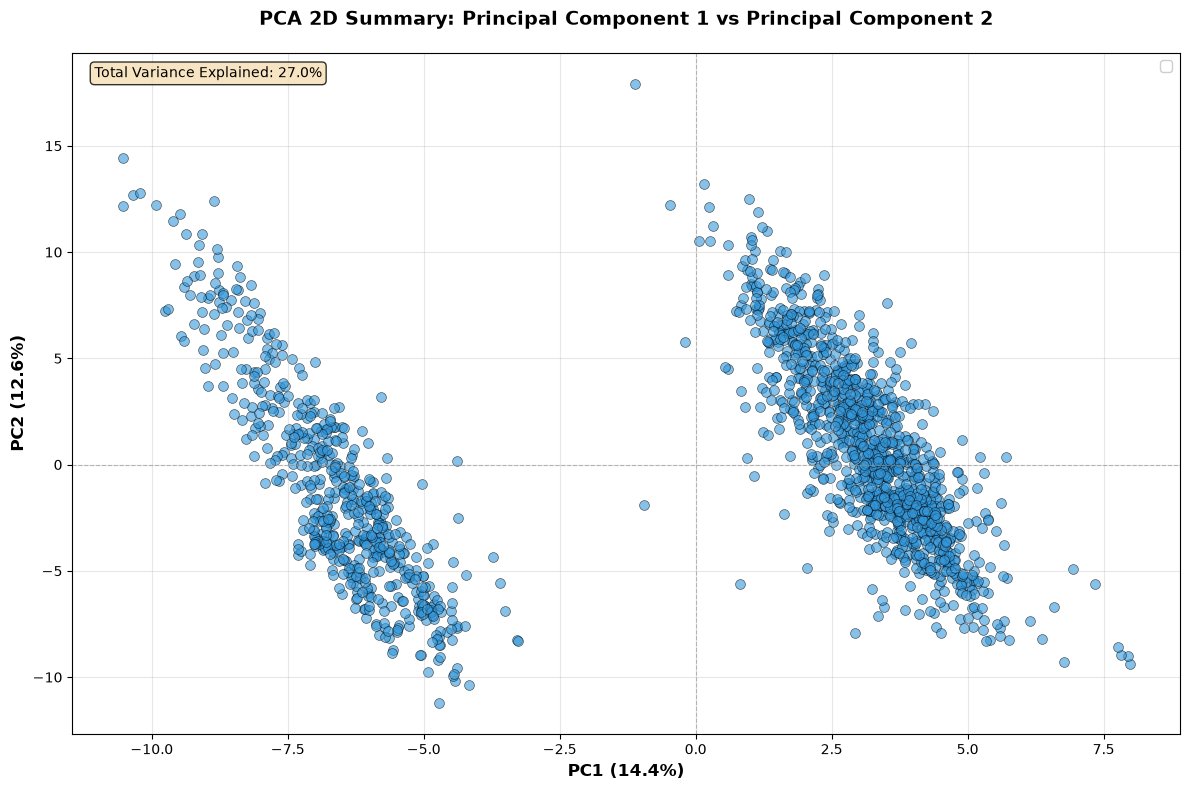

PCA 2D SUMMARY
Number of samples: 1786
Number of original features: 160

Explained Variance Ratio:
  PC1: 14.39%
  PC2: 12.57%
  Total (PC1+PC2): 26.96%

PCA DataFrame shape: (1786, 2)
First 5 rows of PCA-transformed data:
   PC1 (14.4%)  PC2 (12.6%)
0    -8.221428     5.940606
1    -5.440783    -3.186757
2    -5.626587    -4.389812
3    -6.056850    -1.719542
4    -8.754630     7.638832


In [41]:
# PCA 2D Summary of PC1 versus PC2
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Verify that df_model is available
if 'df_model' not in locals():
    raise NameError("df_model is not defined. Please run earlier cells to load and prepare the data.")

# Prepare data for PCA
# Extract only numeric columns, excluding outcome columns
numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
features_for_pca = df_model[numeric_cols].copy()

# Remove columns that are likely identifiers or outcomes (not useful for PCA)
exclude_patterns = ['client', 'admission', 'outcome', 'interval', 'id', 'sequential']
features_for_pca = features_for_pca[[c for c in features_for_pca.columns 
                                       if not any(pattern.lower() in c.lower() for pattern in exclude_patterns)]]

# Remove rows with any missing values in the feature set for PCA
features_for_pca_clean = features_for_pca.dropna()

if features_for_pca_clean.empty or features_for_pca_clean.shape[1] < 2:
    raise ValueError("Not enough numeric features for PCA after cleaning. Check data availability.")

# Get outcome variable if available
outcome = None
outcome_col_name = None
if 'Positive Outcome 12 months' in df_model.columns:
    outcome = df_model.loc[features_for_pca_clean.index, 'Positive Outcome 12 months']
    outcome_col_name = 'Positive Outcome 12 months'
elif 'positive_outcome' in df_model.columns:
    outcome = df_model.loc[features_for_pca_clean.index, 'positive_outcome']
    outcome_col_name = 'positive_outcome'

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_for_pca_clean)

# Apply PCA with 2 components
pca = PCA(n_components=2)
pca_features = pca.fit_transform(features_scaled)

# Create PCA results dataframe
pca_df = pd.DataFrame(
    data=pca_features,
    columns=[f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', 
             f'PC2 ({pca.explained_variance_ratio_[1]:.1%})']
)

if outcome is not None:
    pca_df['Outcome'] = outcome.values
    pca_df['Outcome_Label'] = pca_df['Outcome'].map({1: 'Positive', 0: 'No Positive'})

# Create the 2D PCA plot
fig, ax = plt.subplots(figsize=(12, 8))

if outcome is not None:
    # Color by outcome
    colors = {1: '#2ecc71', 0: '#e74c3c'}  # Green for positive, red for no positive
    labels = {1: 'Positive Outcome', 0: 'No Positive Outcome'}
    
    for outcome_val in sorted(pca_df['Outcome'].unique()):
        mask = pca_df['Outcome'] == outcome_val
        ax.scatter(
            pca_df.loc[mask, pca_df.columns[0]],
            pca_df.loc[mask, pca_df.columns[1]],
            c=colors[outcome_val],
            label=labels[outcome_val],
            alpha=0.6,
            s=50,
            edgecolors='black',
            linewidth=0.5
        )
else:
    # Single color if no outcome
    ax.scatter(
        pca_df[pca_df.columns[0]],
        pca_df[pca_df.columns[1]],
        c='#3498db',
        alpha=0.6,
        s=50,
        edgecolors='black',
        linewidth=0.5
    )

# Formatting
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel(pca_df.columns[0], fontsize=12, fontweight='bold')
ax.set_ylabel(pca_df.columns[1], fontsize=12, fontweight='bold')
ax.set_title('PCA 2D Summary: Principal Component 1 vs Principal Component 2', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3)

# Add variance explained annotation
variance_text = f"Total Variance Explained: {pca.explained_variance_ratio_.sum():.1%}"
ax.text(0.02, 0.98, variance_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# Print PCA summary
print("=" * 80)
print("PCA 2D SUMMARY")
print("=" * 80)
print(f"Number of samples: {pca_features.shape[0]}")
print(f"Number of original features: {features_scaled.shape[1]}")
print(f"\nExplained Variance Ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  Total (PC1+PC2): {pca.explained_variance_ratio_.sum():.2%}")
print(f"\nPCA DataFrame shape: {pca_df.shape}")
print(f"First 5 rows of PCA-transformed data:")
print(pca_df.head())

if outcome is not None:
    print(f"\nOutcome distribution:")
    print(pca_df['Outcome_Label'].value_counts())
    print(f"\nOutcome proportions:")
    print(pca_df['Outcome_Label'].value_counts(normalize=True).round(4))


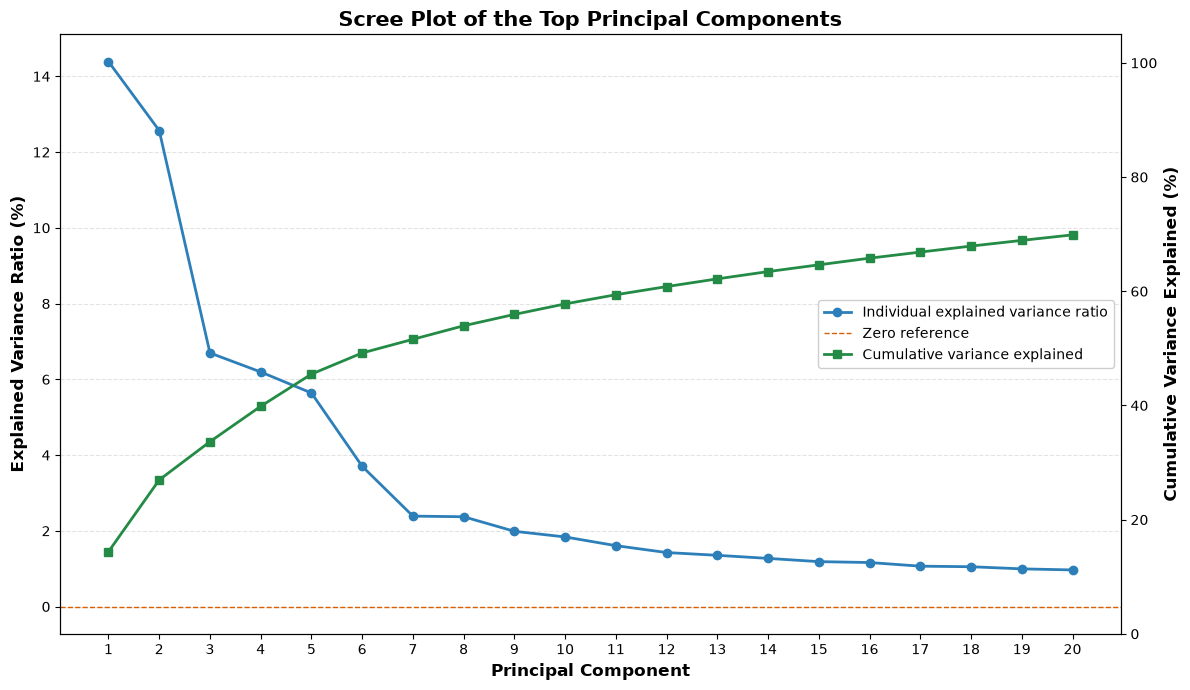

Variance explained by PC1 and PC2: 26.96%
Components plotted: 20 of 160
Variance explained by PC1 and PC2: 26.96%


In [43]:
# Scree plot of the Top Principal Components
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if "features_for_pca" not in globals() or features_for_pca.empty:
    raise NameError("Run cell 49 first so features_for_pca is available.")

# Use the same numeric PCA inputs as cell 49 and standardize them before fitting.
numeric_pca_features = features_for_pca.select_dtypes(include=["number", "bool"]).copy()
if numeric_pca_features.shape[1] < 2:
    raise ValueError("At least two numeric features are required for a scree plot.")

features_scaled_scree = StandardScaler().fit_transform(numeric_pca_features)
maximum_components = min(features_scaled_scree.shape[0], features_scaled_scree.shape[1])
pca_scree = PCA(n_components=maximum_components)
pca_scree.fit(features_scaled_scree)

component_numbers = np.arange(1, maximum_components + 1)
explained_variance = pca_scree.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
top_components = min(20, maximum_components)

fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.plot(
    component_numbers[:top_components],
    explained_variance[:top_components] * 100,
    marker="o",
    color="#2C7FB8",
    linewidth=2,
    label="Individual explained variance ratio",
)
ax1.axhline(
    0,
    color="#D95F02",
    linestyle="--",
    linewidth=1.0,
    label="Zero reference",
)
ax1.set_xlabel("Principal Component", fontsize=12, fontweight="bold")
ax1.set_ylabel("Explained Variance Ratio (%)", fontsize=12, fontweight="bold")
ax1.set_xticks(component_numbers[:top_components])
ax1.grid(axis="y", linestyle="--", alpha=0.35)

ax2 = ax1.twinx()
ax2.plot(
    component_numbers[:top_components],
    cumulative_variance[:top_components] * 100,
    marker="s",
    color="#238B45",
    linewidth=2,
    label="Cumulative variance explained",
)
ax2.set_ylabel("Cumulative Variance Explained (%)", fontsize=12, fontweight="bold")
ax2.set_ylim(0, 105)

ax1.set_title("Scree Plot of the Top Principal Components", fontsize=15, fontweight="bold")
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="center right", framealpha=0.95)
plt.tight_layout()
plt.show()

scree_summary = pd.DataFrame({
    "Principal Component": component_numbers[:top_components],
    "Eigenvalue": pca_scree.explained_variance_[:top_components],
    "Individual Variance Explained": explained_variance[:top_components],
    "Cumulative Variance Explained": cumulative_variance[:top_components],
})

print(
    f"Variance explained by PC1 and PC2: "
    f"{cumulative_variance[1]:.2%}"
    if len(cumulative_variance) >= 2
    else "PC2 is unavailable because fewer than two components were created."
)
print(f"Components plotted: {top_components} of {maximum_components}")
print(f"Variance explained by PC1 and PC2: {cumulative_variance[1]:.2%}")

# Modeling Strategy By Research Question:

Research Question 1 (RQ1):

- The primary objective is to compare candidate supervised learning models on held-out data using discrimination and calibration metrics. 

- The modeling workflow therefore emphasized AUROC, Brier score, calibration slope, sensitivity, specificity, and PPV, with the final comparison made against a logistic regression baseline. 

Candidate models should be evaluated on a random stratified 80/20 holdout split (train_test_split, stratify=y, random_state=42) 

- So that performance reflect true out-of-sample prediction rather than resubstitution fit.

RQ1: What AUROC and calibration performance (Brier score; calibration slope) do supervised machine learning models achieve when predicting adolescent residential mental health treatment outcomes from longitudinal administrative and clinical data, assessed at two pre-specified horizons of 12 and 24  months treatment completion date  post-discharge?    

H10: The best-performing ML model does not exceed the logistic regression baseline by a practically meaningful margin which is defined as AUROC improvement < 0.05 over baseline or Brier score reduction < 0.03, at either 12, 24 months prediction horizon on the held-out temporal test set.

H1a: The best-performing ML model exceeds the baseline by AUROC improvement ≥ 0.05 and Brier score reduction ≥ 0.03, indicating both superior discrimination and better-calibrated probabilities, at one or both pre-specified prediction horizons.

In [44]:
# RQ1: temporal comparison of supervised models at the pre-specified 12- and 24-month horizons
# Outcomes are defined from INTC Completion Date: an adverse outcome is a decline in
# total RCIL raw score at the first observed assessment on or after the horizon date.
# Predictors are restricted to the index record, before follow-up information is available.
# The held-out test set contains later index dates and no clients appearing in training.
# Model performance is reported with client-level bootstrap 95% confidence intervals.

import importlib.util
import subprocess
import sys

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import brier_score_loss, confusion_matrix, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

OPTIONAL_MODELS = ["xgboost", "lightgbm", "catboost"]
for package in OPTIONAL_MODELS:
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", package
        ], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

if "df_model" not in globals():
    raise NameError("Run the data preparation cells first so df_model is available.")


def calibration_slope(y_true, probabilities):
    clipped = np.clip(probabilities, 1e-6, 1 - 1e-6)
    logit = np.log(clipped / (1 - clipped)).reshape(-1, 1)
    if np.unique(y_true).size < 2 or np.std(logit) == 0:
        return np.nan
    calibration_model = LogisticRegression(C=1e6, solver="lbfgs", max_iter=2000)
    calibration_model.fit(logit, y_true)
    return float(calibration_model.coef_[0, 0])


def classification_metrics(y_true, probabilities):
    predictions = (probabilities >= 0.50).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_true, predictions, labels=[0, 1]
    ).ravel()
    return {
        "AUROC": roc_auc_score(y_true, probabilities),
        "Brier score": brier_score_loss(y_true, probabilities),
        "Calibration slope": calibration_slope(y_true, probabilities),
        "Sensitivity": tp / (tp + fn) if (tp + fn) else np.nan,
        "Specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "PPV": tp / (tp + fp) if (tp + fp) else np.nan,
    }


def bootstrap_intervals(y_true, probabilities, groups, random_state=42, n_bootstrap=1000):
    rng = np.random.default_rng(random_state)
    groups = np.asarray(groups)
    unique_groups = pd.Series(groups).drop_duplicates().to_numpy()
    bootstrap_metrics = []
    for _ in range(n_bootstrap):
        sampled_groups = rng.choice(unique_groups, size=len(unique_groups), replace=True)
        sampled_indices = np.concatenate([
            np.flatnonzero(groups == group) for group in sampled_groups
        ])
        sampled_y = np.asarray(y_true)[sampled_indices]
        if np.unique(sampled_y).size < 2:
            continue
        bootstrap_metrics.append(
            classification_metrics(sampled_y, np.asarray(probabilities)[sampled_indices])
        )
    bootstrap_frame = pd.DataFrame(bootstrap_metrics)
    return {
        metric: (
            float(bootstrap_frame[metric].quantile(0.025)),
            float(bootstrap_frame[metric].quantile(0.975)),
        )
        for metric in ["AUROC", "Brier score", "Calibration slope"]
    }


def temporal_test_predictions(estimator, X_train, y_train, X_test, preprocessor):
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", estimator),
    ])
    pipeline.fit(X_train, y_train)
    model = pipeline.named_steps["model"]
    if hasattr(model, "predict_proba"):
        return pipeline.predict_proba(X_test)[:, 1]
    train_scores = pipeline.decision_function(X_train)
    test_scores = pipeline.decision_function(X_test)
    score_min = train_scores.min()
    score_range = train_scores.max() - score_min
    return 1 / (1 + np.exp(-np.clip(test_scores, -30, 30)))


models = {
    "Logistic regression (baseline)": LogisticRegression(
        max_iter=5000, class_weight="balanced", random_state=42
    ),
    "Regularized logistic regression": LogisticRegression(
        penalty="l2", C=1.0, max_iter=5000,
        class_weight="balanced", random_state=42
    ),
    "Linear discriminant analysis": LinearDiscriminantAnalysis(),
    "Decision tree": DecisionTreeClassifier(
        random_state=42, min_samples_leaf=5, class_weight="balanced"
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=400, min_samples_leaf=3,
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "Gradient boosting machine": GradientBoostingClassifier(random_state=42),
    "Ridge classifier": RidgeClassifier(random_state=42),
    "Lasso logistic regression": LogisticRegression(
        penalty="l1", solver="liblinear", C=1.0,
        class_weight="balanced", random_state=42
    ),
    "Elastic net logistic regression": LogisticRegression(
        penalty="elasticnet", solver="saga", l1_ratio=0.5, C=1.0,
        max_iter=5000, class_weight="balanced", random_state=42
    ),
    "Support vector machine": SVC(
        probability=True, kernel="rbf", C=1.0,
        class_weight="balanced", random_state=42
    ),
    "k-nearest neighbors": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Artificial neural network": MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=2000, random_state=42
    ),
}

if importlib.util.find_spec("xgboost") is not None:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
        random_state=42, n_jobs=-1
    )

if importlib.util.find_spec("lightgbm") is not None:
    from lightgbm import LGBMClassifier
    models["LightGBM"] = LGBMClassifier(
        n_estimators=300, num_leaves=15, learning_rate=0.05,
        class_weight="balanced", random_state=42, verbosity=-1
    )

if importlib.util.find_spec("catboost") is not None:
    from catboost import CatBoostClassifier
    models["CatBoost"] = CatBoostClassifier(
        iterations=500, depth=6, learning_rate=0.05,
        loss_function="Logloss", random_seed=42, verbose=False
    )

if "outcome_rcil_raw_total" not in df_model.columns:
    rcil_raw_columns = [
        column for column in df_model.columns
        if str(column).startswith("RCIL") and "Raw Score" in str(column)
    ]
    df_model["outcome_rcil_raw_total"] = df_model[rcil_raw_columns].apply(
        pd.to_numeric, errors="coerce"
    ).sum(axis=1, min_count=1)

analysis_data = df_model.copy()
analysis_data["_intc_date"] = pd.to_datetime(
    analysis_data["INTC Completion Date"], errors="coerce"
)
analysis_data["_rcil_total"] = pd.to_numeric(
    analysis_data["outcome_rcil_raw_total"], errors="coerce"
)

index_rows = analysis_data.loc[
    analysis_data["_intc_date"].notna()
].sort_values(["Admission ID", "_intc_date"])
index_rows = index_rows.drop_duplicates("Admission ID", keep="first")

HORIZONS = {"12 months": 12, "24 months": 24}
summary_rows = []
all_horizon_results = []

for horizon_label, horizon_months in HORIZONS.items():
    horizon_offset = pd.DateOffset(months=horizon_months)
    records = []
    for admission_id, index_group in index_rows.groupby("Admission ID", sort=False):
        index_record = index_group.iloc[0]
        if pd.isna(index_record["_rcil_total"]):
            continue
        followup_candidates = analysis_data[
            (analysis_data["Admission ID"] == admission_id)
            & (analysis_data["_intc_date"] >= index_record["_intc_date"] + horizon_offset)
            & analysis_data["_rcil_total"].notna()
        ].sort_values(["_intc_date", "Interval Sequential Number"])
        if followup_candidates.empty:
            continue
        followup_record = followup_candidates.iloc[0]
        records.append({
            "admission_id": admission_id,
            "client_id": index_record["Client ID"],
            "index_date": index_record["_intc_date"],
            "followup_date": followup_record["_intc_date"],
            "adverse_rcil_change": int(
                followup_record["_rcil_total"] - index_record["_rcil_total"] < 0
            ),
            "index_row": index_record.name,
        })

    horizon_records = pd.DataFrame(records)
    if horizon_records.empty:
        print(f"Skipping {horizon_label}: no qualifying follow-up observations.")
        all_horizon_results.append(pd.DataFrame([{
            "Horizon": horizon_label,
            "Model": "Not available",
            "AUROC": np.nan,
            "Brier score": np.nan,
            "Calibration slope": np.nan,
            "AUROC 95% CI": "Not estimable",
            "Brier score 95% CI": "Not estimable",
            "Calibration slope 95% CI": "Not estimable",
            "Sensitivity": np.nan,
            "Specificity": np.nan,
            "PPV": np.nan,
            "Status": "Skipped: no qualifying follow-up observations",
        }]))
        continue

    split_date = horizon_records["index_date"].quantile(0.80)
    test_mask = horizon_records["index_date"] >= split_date
    test_clients = set(horizon_records.loc[test_mask, "client_id"])
    train_mask = (~test_mask) & (~horizon_records["client_id"].isin(test_clients))
    train_records = horizon_records.loc[train_mask].copy()
    test_records = horizon_records.loc[test_mask].copy()

    if (
        train_records.empty
        or test_records.empty
        or train_records["adverse_rcil_change"].nunique() < 2
        or test_records["adverse_rcil_change"].nunique() < 2
    ):
        print(
            f"Skipping {horizon_label}: the chronological client-separated split "
            "does not contain both outcome classes in train and test data."
        )
        all_horizon_results.append(pd.DataFrame([{
            "Horizon": horizon_label,
            "Model": "Not available",
            "AUROC": np.nan,
            "Brier score": np.nan,
            "Calibration slope": np.nan,
            "AUROC 95% CI": "Not estimable",
            "Brier score 95% CI": "Not estimable",
            "Calibration slope 95% CI": "Not estimable",
            "Sensitivity": np.nan,
            "Specificity": np.nan,
            "PPV": np.nan,
            "Status": "Skipped: temporal split lacks both outcome classes",
        }]))
        continue

    train_features = analysis_data.loc[train_records["index_row"]].copy()
    test_features = analysis_data.loc[test_records["index_row"]].copy()
    excluded_predictors = {
        "Client ID", "Admission ID", "Interval ID", "Interval Cycle Number",
        "Interval Sequential Number", "Interval Is Discharge",
        "INTC Completion Date", "Admission Step Down Date",
        "_intc_date", "_rcil_total", "outcome_rcil_raw_total",
        "outcome_rcil_raw_mean", "outcome_rcil_change_first_to_last",
    }
    feature_columns = [
        column for column in train_features.columns
        if column not in excluded_predictors
        and not str(column).startswith("outcome_")
        and not str(column).startswith("_")
    ]
    X_train = train_features[feature_columns]
    X_test = test_features[feature_columns]
    y_train = train_records["adverse_rcil_change"].reset_index(drop=True)
    y_test = test_records["adverse_rcil_change"].reset_index(drop=True)
    test_groups = test_records["client_id"].reset_index(drop=True)

    numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = [column for column in X_train.columns if column not in numeric_features]
    preprocessor = ColumnTransformer([
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ])

    horizon_metrics = []
    for model_name, estimator in models.items():
        probabilities = temporal_test_predictions(
            estimator, X_train, y_train, X_test, preprocessor
        )
        metrics = classification_metrics(y_test, probabilities)
        intervals = bootstrap_intervals(y_test, probabilities, test_groups)
        horizon_metrics.append({
            "Horizon": horizon_label,
            "Model": model_name,
            **metrics,
            "AUROC 95% CI": f"({intervals['AUROC'][0]:.4f}, {intervals['AUROC'][1]:.4f})",
            "Brier score 95% CI": f"({intervals['Brier score'][0]:.4f}, {intervals['Brier score'][1]:.4f})",
            "Calibration slope 95% CI": f"({intervals['Calibration slope'][0]:.4f}, {intervals['Calibration slope'][1]:.4f})",
            "Status": "Evaluated on held-out temporal client-separated test set",
        })

    horizon_results = pd.DataFrame(horizon_metrics)
    all_horizon_results.append(horizon_results)
    display_columns = [
        "Horizon", "Model", "AUROC", "Brier score", "Calibration slope",
        "AUROC 95% CI", "Brier score 95% CI", "Calibration slope 95% CI",
        "Sensitivity", "Specificity", "PPV"
    ]
    print(
        f"\nRQ1 {horizon_label} results using a held-out temporal test set "
        "with client separation:"
    )
    display(
        horizon_results.sort_values(["AUROC", "Brier score"], ascending=[False, True])[
            display_columns
        ].round(4)
    )

    baseline_row = horizon_results[
        horizon_results["Model"] == "Logistic regression (baseline)"
    ].iloc[0]
    best_row = horizon_results.sort_values(
        ["AUROC", "Brier score"], ascending=[False, True]
    ).iloc[0]
    auroc_delta = float(best_row["AUROC"] - baseline_row["AUROC"])
    brier_reduction = float(baseline_row["Brier score"] - best_row["Brier score"])
    decision = (
        "supports the alternate hypothesis"
        if auroc_delta >= 0.05 and brier_reduction >= 0.03
        else "supports the null hypothesis"
    )
    summary_rows.append({
        "Horizon": horizon_label,
        "Training observations": len(train_records),
        "Test observations": len(test_records),
        "Test clients": test_records["client_id"].nunique(),
        "Temporal cutoff": split_date.date(),
        "Best model": best_row["Model"],
        "Baseline AUROC": round(float(baseline_row["AUROC"]), 4),
        "Best AUROC": round(float(best_row["AUROC"]), 4),
        "AUROC difference": round(auroc_delta, 4),
        "Baseline Brier": round(float(baseline_row["Brier score"]), 4),
        "Best Brier": round(float(best_row["Brier score"]), 4),
        "Brier reduction": round(brier_reduction, 4),
        "Decision": decision,
    })

rq1_summary = pd.DataFrame(summary_rows)
print("\nRQ1 summary for the two pre-specified temporal horizons:")
display(rq1_summary)

full_rq1_results = pd.concat(all_horizon_results, ignore_index=True)
full_rq1_results = full_rq1_results[
    [
        "Horizon", "Model", "AUROC", "Brier score", "Calibration slope",
        "AUROC 95% CI", "Brier score 95% CI", "Calibration slope 95% CI",
        "Sensitivity", "Specificity", "PPV", "Status"
    ]
].sort_values(["Horizon", "AUROC", "Brier score"], ascending=[True, False, True])
print("\nFull RQ1 results table with temporal test evaluation and bootstrap 95% CIs:")
display(full_rq1_results.round(4))

print(
    "\nInterpretation note: H10/H1a are evaluated using the pre-specified "
    "AUROC and Brier thresholds. Calibration slope is reported as an additional "
    "calibration diagnostic. A horizon is not interpreted when the temporal test "
    "set lacks both outcome classes."
)

c:\Users\16122\Documents\PhD\NCU\Weekly_Readings&Assignments\DIS-9100A v1_Components_of_Dissertation_Proposal\Chapters1-2-3-4-5-Template\Dissertation2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\16122\Documents\PhD\NCU\Weekly_Readings&Assignments\DIS-9100A v1_Components_of_Dissertation_Proposal\Chapters1-2-3-4-5-Template\Dissertation2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. 


RQ1 12 months results using a held-out temporal test set with client separation:


,Horizon,Model,AUROC,Brier score,Calibration slope,AUROC 95% CI,Brier score 95% CI,Calibration slope 95% CI,Sensitivity,Specificity,PPV
15,12 months,CatBoost,0.7333,0.2249,0.4207,"(0.5331, 0.9026)","(0.1196, 0.3352)","(0.0549, 1.2656)",0.3333,0.85,0.5000
4,12 months,Random forest,0.6833,0.2138,1.1079,"(0.4551, 0.8897)","(0.1686, 0.2658)","(-0.1338, 3.6050)",0.5556,0.75,0.5000
7,12 months,Lasso logistic regression,0.6722,0.2600,0.2398,"(0.4411, 0.8870)","(0.1358, 0.3984)","(-0.0349, 0.7152)",0.5556,0.75,0.5000
5,12 months,Gradient boosting machine,0.6611,0.2691,0.2249,"(0.4545, 0.8558)","(0.1410, 0.4045)","(-0.1231, 0.8060)",0.2222,0.85,0.4000
10,12 months,k-nearest neighbors,0.6472,0.2510,0.0246,"(0.4048, 0.8667)","(0.1752, 0.3352)","(-0.2649, 2.5454)",0.7778,0.65,0.5000
8,12 months,Elastic net logistic regression,0.6333,0.4554,0.1003,"(0.4643, 0.7827)","(0.2848, 0.6347)","(-0.0117, 0.7334)",1.0000,0.25,0.3750
0,12 months,Logistic regression (baseline),0.6333,0.4649,0.1148,"(0.4643, 0.7827)","(0.2909, 0.6512)","(0.0068, 0.7592)",1.0000,0.25,0.3750
1,12 months,Regularized logistic regression,0.6333,0.4649,0.1148,"(0.4643, 0.7827)","(0.2909, 0.6512)","(0.0068, 0.7592)",1.0000,0.25,0.3750
3,12 months,Decision tree,0.6222,0.2668,0.0567,"(0.4384, 0.8155)","(0.1319, 0.4141)","(-0.0441, 0.2112)",0.4444,0.80,0.5000
14,12 months,LightGBM,0.6167,0.2544,0.1816,"(0.3722, 0.8393)","(0.1360, 0.3841)","(-0.1528, 0.7462)",0.4444,0.70,0.4000


c:\Users\16122\Documents\PhD\NCU\Weekly_Readings&Assignments\DIS-9100A v1_Components_of_Dissertation_Proposal\Chapters1-2-3-4-5-Template\Dissertation2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\16122\Documents\PhD\NCU\Weekly_Readings&Assignments\DIS-9100A v1_Components_of_Dissertation_Proposal\Chapters1-2-3-4-5-Template\Dissertation2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. 


RQ1 24 months results using a held-out temporal test set with client separation:


...


RQ1 summary for the two pre-specified temporal horizons:


,Horizon,Training observations,Test observations,Test clients,Temporal cutoff,Best model,Baseline AUROC,Best AUROC,AUROC difference,Baseline Brier,Best Brier,Brier reduction,Decision
0,12 months,106,29,29,2024-06-11,CatBoost,0.6333,0.7333,0.1,0.4649,0.2249,0.24,supports the alternate hypothesis
1,24 months,25,7,7,2023-09-23,Logistic regression (baseline),1.0000,1.0000,0.0,0.0336,0.0336,0.00,supports the null hypothesis



Full RQ1 results table with temporal test evaluation and bootstrap 95% CIs:


,Horizon,Model,AUROC,Brier score,Calibration slope,AUROC 95% CI,Brier score 95% CI,Calibration slope 95% CI,Sensitivity,Specificity,PPV,Status
15,12 months,CatBoost,0.7333,0.2249,0.4207,"(0.5331, 0.9026)","(0.1196, 0.3352)","(0.0549, 1.2656)",0.3333,0.85,0.5000,Evaluated on held-out temporal client-separate...
4,12 months,Random forest,0.6833,0.2138,1.1079,"(0.4551, 0.8897)","(0.1686, 0.2658)","(-0.1338, 3.6050)",0.5556,0.75,0.5000,Evaluated on held-out temporal client-separate...
7,12 months,Lasso logistic regression,0.6722,0.2600,0.2398,"(0.4411, 0.8870)","(0.1358, 0.3984)","(-0.0349, 0.7152)",0.5556,0.75,0.5000,Evaluated on held-out temporal client-separate...
5,12 months,Gradient boosting machine,0.6611,0.2691,0.2249,"(0.4545, 0.8558)","(0.1410, 0.4045)","(-0.1231, 0.8060)",0.2222,0.85,0.4000,Evaluated on held-out temporal client-separate...
10,12 months,k-nearest neighbors,0.6472,0.2510,0.0246,"(0.4048, 0.8667)","(0.1752, 0.3352)","(-0.2649, 2.5454)",0.7778,0.65,0.5000,Evaluated on held-out temporal client-separate...
8,12 months,Elastic net logistic regression,0.6333,0.4554,0.1003,"(0.4643, 0.7827)","(0.2848, 0.6347)","(-0.0117, 0.7334)",1.0000,0.25,0.3750,Evaluated on held-out temporal client-separate...
0,12 months,Logistic regression (baseline),0.6333,0.4649,0.1148,"(0.4643, 0.7827)","(0.2909, 0.6512)","(0.0068, 0.7592)",1.0000,0.25,0.3750,Evaluated on held-out temporal client-separate...
1,12 months,Regularized logistic regression,0.6333,0.4649,0.1148,"(0.4643, 0.7827)","(0.2909, 0.6512)","(0.0068, 0.7592)",1.0000,0.25,0.3750,Evaluated on held-out temporal client-separate...
3,12 months,Decision tree,0.6222,0.2668,0.0567,"(0.4384, 0.8155)","(0.1319, 0.4141)","(-0.0441, 0.2112)",0.4444,0.80,0.5000,Evaluated on held-out temporal client-separate...
14,12 months,LightGBM,0.6167,0.2544,0.1816,"(0.3722, 0.8393)","(0.1360, 0.3841)","(-0.1528, 0.7462)",0.4444,0.70,0.4000,Evaluated on held-out temporal client-separate...



Interpretation note: H10/H1a are evaluated using the pre-specified AUROC and Brier thresholds. Calibration slope is reported as an additional calibration diagnostic. A horizon is not interpreted when the temporal test set lacks both outcome classes.


### Steps Carried Out to Address Research Question 1

Research Question 1 was addressed through the following steps:

1. **Define the analytic sample.** The residential administrative and clinical dataset was restricted to records with a valid `INTC Completion Date`. The `INTC Completion Date` was used as the treatment-completion index date for establishing the prediction timeline.

2. **Construct the longitudinal outcome.** Total RCIL raw scores were calculated from the available RCIL raw-score variables. For each admission, the earliest record with a valid `INTC Completion Date` was treated as the index assessment. At each pre-specified horizon, the first available follow-up assessment on or after 12 or 24 months after the index date was identified. The binary outcome was coded as 1 when the follow-up total RCIL score was lower than the index score, indicating an adverse decline, and 0 otherwise. Admissions without a qualifying follow-up assessment were excluded from that horizon-specific analysis rather than assigned an imputed outcome.

3. **Restrict predictors to information available at prediction.** Model predictors were taken only from the index assessment. Identifiers, follow-up variables, dates, RCIL outcome totals, engineered outcome variables, and other variables that could contain post-index information were excluded. This prevented information occurring after treatment completion from entering the prediction model.

4. **Compare supervised learning algorithms.** The logistic regression model served as the baseline. It was compared with regularized logistic regression, linear discriminant analysis, decision tree, random forest, gradient boosting machine, XGBoost, LightGBM, CatBoost, support vector machine, k-nearest neighbors, naive Bayes, artificial neural network, ridge classifier, lasso logistic regression, and elastic net logistic regression when the corresponding packages were available.

5. **Preprocess predictors within the modeling pipeline.** Numeric predictors were median-imputed and standardized. Categorical predictors were imputed using the most frequent category and one-hot encoded. These transformations were fitted using the training data and then applied to the temporal test data to reduce preprocessing leakage.

6. **Create a held-out temporal test set.** Admissions were ordered by their index `INTC Completion Date`. The latest approximately 20% of eligible index observations were reserved as the test period. Clients represented in the temporal test set were excluded from training, ensuring that the same client did not contribute observations to both sets.

7. **Evaluate discrimination and calibration.** Each model generated test-set probabilities or probability-scaled decision scores. Performance was evaluated using AUROC, Brier score, calibration slope, sensitivity, specificity, and positive predictive value. AUROC measured discrimination, while Brier score and calibration slope assessed the quality and calibration of predicted probabilities.

8. **Quantify uncertainty.** Client-level bootstrap resampling was used to calculate 95% confidence intervals for AUROC, Brier score, and calibration slope. Resampling at the client level preserved the dependence structure created by repeated admissions or observations from the same client.

9. **Evaluate the hypotheses.** For each horizon, the best-performing model was compared with the logistic regression baseline. H1a was supported only when the best model improved AUROC by at least 0.05 and reduced Brier score by at least 0.03. Otherwise, the results supported H10. A horizon was not interpreted when the available temporal test set did not contain both outcome classes.

10. **Report the findings transparently.** The notebook produces horizon-specific model tables, a summary comparison with the baseline, confidence intervals, sample and cutoff information, and a complete results table. The 12- and 24-month analyses are reported using observed `INTC Completion Date` follow-up; no unavailable horizon is replaced with a shorter-term proxy.

### Interpretation of Results for Research Question 1

Research Question 1 examined the AUROC and calibration performance of supervised machine learning models for predicting adolescent residential mental health treatment outcomes at 12 and 24 months after the treatment-completion index date. The outcome was operationalized as an adverse decline in total RCIL raw score at the first observed follow-up assessment on or after the specified horizon. Predictors were restricted to information available at the index assessment, and model performance was evaluated on a chronological test set that excluded clients represented in the training data.

At the **12-month horizon**, CatBoost achieved the highest observed AUROC at **0.7333**, compared with **0.6333** for the logistic-regression baseline. The AUROC improvement was therefore **0.1000**, exceeding the pre-specified threshold of 0.05. CatBoost also produced a Brier score of **0.2249**, compared with **0.4649** for the baseline, representing a Brier-score reduction of **0.2400**, which exceeded the required reduction of 0.03. The CatBoost calibration slope was **0.4207**. Based on the pre-specified decision rule, the 12-month results support **H1a** and reject **H10** for this horizon. However, the CatBoost AUROC 95% confidence interval ranged from approximately **0.5331 to 0.9026**, indicating meaningful uncertainty around the estimate.

At the **24-month horizon**, logistic regression and regularized logistic regression were tied for the strongest observed performance, each with an AUROC of **1.0000** and a Brier score of **0.0336**. Because the best model did not improve on the baseline, the AUROC improvement was **0.0000** and the Brier-score reduction was **0.0000**. The 24-month results therefore support **H10**, not H1a. The apparent perfect AUROC should be interpreted cautiously because the temporal test set contained only **7 clients**. The resulting confidence intervals and calibration estimates are consequently unstable and should not be interpreted as evidence of perfect generalizable prediction.

Overall, the findings provide preliminary evidence that supervised machine learning performance differed by prediction horizon. CatBoost exceeded the logistic-regression baseline at 12 months under the study's numerical decision rule, whereas no practically meaningful improvement was observed at 24 months. Accordingly, the analysis supports H1a at 12 months and H10 at 24 months. These conclusions are limited to the operationalized RCIL-change outcome and the available sample. The small 24-month test set substantially limits statistical precision, and external validation with a larger temporally complete sample is needed before claiming robust clinical or operational prediction performance.

### Explainability–Interpretability Trade-off Across the 15 Candidate Models (Research Question 1)

Research Question 1 asked whether supervised machine learning models improve discrimination (AUROC) and calibration (Brier score) over a logistic-regression baseline when predicting adverse RCIL decline at 12 and 24 months. Answering this question requires explicit consideration of the **explainability–interpretability trade-off**, because the 15 candidate algorithms differ substantially in how transparently their predictions can be understood and communicated in a clinical context.

**Interpretability** refers to intrinsic transparency: a human can understand the model's decision logic directly from its structure (e.g., coefficients, decision paths, conditional probabilities). **Explainability** refers to post-hoc explanation: the model itself is a black box, but auxiliary techniques (e.g., SHAP values, permutation importance, partial dependence plots) approximate why it produced a given prediction. The fundamental trade-off is that intrinsically interpretable models require no post-hoc machinery but sacrifice capacity to model nonlinear interactions, whereas high-capacity models may achieve superior AUROC and calibration at the cost of requiring post-hoc explanations that are themselves statistical approximations subject to additional estimation error.

**Glass-box (fully interpretable) models.** Logistic regression (the baseline), ridge classifier, lasso logistic regression, elastic net logistic regression, linear discriminant analysis, and naive Bayes are intrinsically interpretable: global coefficients or class-conditional weights map predictors directly onto the outcome and can be expressed as odds ratios or standardized effects that are communicable to clinicians. The penalized variants (ridge, lasso, elastic net) retain this linear form; lasso and elastic net additionally perform feature selection, arguably *increasing* interpretability by producing sparser models. These models define the reference standard: under the pre-specified decision rule, a more complex model must improve AUROC by at least 0.05 and reduce Brier score by at least 0.03 to justify displacing them.

**Moderately interpretable models.** A single decision tree is visually interpretable through its rule paths, but it is structurally unstable—small perturbations of the training data can reshape the tree—so its apparent transparency does not guarantee reliable generalization.

**Post-hoc-explainable ensemble models.** Random forest, gradient boosting machine, XGBoost, LightGBM, and CatBoost are ensembles of hundreds or thousands of trees with no single decision path; they are intrinsically opaque but support relatively reliable post-hoc explanation through SHAP and permutation methods, which are well developed for tree ensembles. The 12-month winning model, CatBoost (AUROC = 0.7333 vs. 0.6333 for the baseline; Brier = 0.2249 vs. 0.4649), falls in this tier: its performance advantage was purchased with interpretability, but its native handling of categorical predictors and the availability of SHAP values recover a degree of post-hoc explanation.

**Black-box models with less reliable explanation.** Kernel support vector machines, k-nearest neighbors, and artificial neural networks make decisions in transformed or high-dimensional spaces. Post-hoc explanation is possible but less dependable: kernel SVM and k-NN require model-agnostic approximations such as KernelSHAP, which are computationally expensive and high-variance in small samples, while gradient-based neural network explanations can be unstable. Had one of these models prevailed, the burden of justifying opacity would have been highest.

**Operationalizing the trade-off.** The H1a decision rule functions as a "complexity tax": a black-box model must outperform the interpretable baseline by a pre-specified, clinically meaningful margin on *both* discrimination and calibration before its opacity is warranted. At the 12-month horizon, CatBoost cleared this threshold, supporting H1a; its AUROC confidence interval (approximately 0.5331–0.9026), however, crossed 0.5, tempering the strength of that conclusion. At the 24-month horizon, no model improved on the logistic-regression baseline, so the interpretable model prevailed and H10 was supported. Notably, the 24-month temporal test set contained only seven clients; in such small samples, post-hoc explanations for black-box models would themselves be unstable, adding a second layer of estimation error. This provides an additional argument that, in small clinical samples, intrinsically interpretable models are preferable even when marginally less accurate, unless performance gains are both substantial and precisely estimated.

### Explainability & Interpretability Trade-off across 15 candidate models, framed for the dissertation:

**Key distinction**

- **Interpretability** = intrinsic transparency; a human can understand the model's decision logic directly from its structure (coefficients, splits, probabilities).
- **Explainability** = post-hoc explainability; the model is a black box, but techniques (SHAP, permutation importance, partial dependence) can approximate why it made a prediction.

The trade-off: intrinsically interpretable models usually need no post-hoc tools but sacrifice capacity to capture interactions/nonlinearities; high-capacity models often win on AUROC/Brier but require post-hoc explanation, which is itself an approximation and can be unstable in small samples.

**The 15 models on the spectrum**

<table style="border-collapse: collapse; width: 100%; font-size: 14px; color: #FFFFFF;">
<thead>
<tr>
<th style="border: 1px solid #AAAAAA; padding: 8px; text-align: left; color: #FFFFFF; font-weight: bold;">Tier</th>
<th style="border: 1px solid #AAAAAA; padding: 8px; text-align: left; color: #FFFFFF; font-weight: bold;">Models</th>
<th style="border: 1px solid #AAAAAA; padding: 8px; text-align: left; color: #FFFFFF; font-weight: bold;">Interpretability</th>
<th style="border: 1px solid #AAAAAA; padding: 8px; text-align: left; color: #FFFFFF; font-weight: bold;">Explainability burden</th>
<th style="border: 1px solid #AAAAAA; padding: 8px; text-align: left; color: #FFFFFF; font-weight: bold;">RQ1 relevance</th>
</tr>
</thead>
<tbody>
<tr>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF; font-weight: bold;">Fully interpretable (glass-box)</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;">Logistic Regression (baseline), Ridge Classifier, Lasso Logistic Regression, Elastic Net Logistic Regression, Linear Discriminant Analysis, Naive Bayes</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;"><b>High</b> — global coefficients/weights directly map predictors to outcome; odds ratios are clinically communicable</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;"><b>None needed</b></td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;">Define the baseline; if a complex model cannot beat LR by ≥ 0.05 AUROC (the H1a rule), interpretability wins by default</td>
</tr>
<tr>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF; font-weight: bold;">Moderately interpretable</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;">Decision Tree</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;"><b>High</b> (visualizable rule paths) but unstable — small data changes reshape the tree</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;">Minimal</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;">Poor generalization; useful as a didactic benchmark</td>
</tr>
<tr>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF; font-weight: bold;">Regularized linear</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;">Regularized Logistic Regression, Ridge Classifier, Lasso Logistic Regression, Elastic Net Logistic Regression</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;"><b>High</b> — same linear form as baseline; Lasso/Elastic Net add feature selection (sparsity), arguably <i>increasing</i> interpretability</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;">None needed</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;">Directly tests whether penalization, not complexity, drives improvement</td>
</tr>
<tr>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF; font-weight: bold;">Black-box, explainable post-hoc</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;">Random Forest, Gradient Boosting Machine, XGBoost, LightGBM, <b>CatBoost</b></td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;"><b>Low</b> — hundreds/thousands of trees; no single decision path</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;"><b>Required</b>: SHAP/permutation importance work well for tree ensembles and are fairly reliable</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;">The 12-month winner (CatBoost, AUROC 0.7333 vs. 0.6333) sits here — the accuracy gain is purchased with interpretability</td>
</tr>
<tr>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF; font-weight: bold;">Black-box, harder to explain</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;">Support Vector Machine (kernel), k-Nearest Neighbors, Artificial Neural Network</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;"><b>Very low</b> — decisions live in transformed or high-dimensional spaces</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;">Required but less reliable: KernelSHAP for SVM/k-NN is slow and high-variance; gradient-based ANN explanations can be unstable</td>
<td style="border: 1px solid #AAAAAA; padding: 6px; color: #FFFFFF;">If these had won, the justification burden would have been highest</td>
</tr>
</tbody>
</table>

**Implications for your dissertation narrative**

1. **The trade-off is directly encoded in your hypotheses.** H1a's dual threshold (ΔAUROC ≥ 0.05 and ΔBrier ≥ 0.03) functions as a "complexity tax": a black-box model must outperform the interpretable baseline by a clinically meaningful margin to justify its opacity. At 24 months, no model cleared the tax → the interpretable logistic regression prevails (supporting H10).

2. **Your 12-month result exemplifies the classic trade.** CatBoost's +0.10 AUROC and −0.24 Brier improvement over baseline is exactly the scenario where a dissertation committee will ask: "Was the gain worth losing coefficient-level interpretability?" Your defense: (a) the gain exceeded a pre-specified clinical threshold, and (b) CatBoost's native handling of categorical predictors + SHAP values recovers some explanation — but note the 95% CI (0.5331–0.9026) crosses 0.5, so even the performance side is uncertain.

3. **Small-sample caution cuts both ways.** With only 7 clients in the 24-month test set, post-hoc explanations (SHAP values) for black-box models would themselves be unstable — an argument that in small clinical samples, interpretable models are preferable even when slightly less accurate, because their explanations don't add a second layer of estimation error.

4. **A useful framing sentence for Chapter 4/5:** *"The 15 algorithms span an interpretability continuum from glass-box linear models (logistic regression, LDA, penalized variants) through post-hoc-explainable ensembles (random forest, gradient boosting, XGBoost, LightGBM, CatBoost) to models requiring less reliable model-agnostic explanation (kernel SVM, k-NN, ANN). The pre-specified H1a decision rule operationalizes this trade-off by requiring complexity-based gains to exceed a clinically meaningful threshold before displacing the interpretable baseline."*

### Data Splitting and Validation Approach for Research Question 1

**Design: temporal holdout rather than k-fold cross-validation.** Research Question 1 was evaluated using a single chronological (temporal) holdout split rather than random k-fold cross-validation. For each horizon, admissions were ordered by their index `INTC Completion Date`, and the cutoff was set at the 80th percentile of index dates: the earliest approximately 80% of observations formed the training partition, and the latest approximately 20% formed the held-out test partition. This design was chosen deliberately. Random k-fold cross-validation ignores the time ordering of clinical data, allowing models to be trained on later records and tested on earlier ones, which introduces look-ahead bias and yields optimistic performance estimates. A temporal holdout instead approximates prospective deployment—the model is trained only on information that would have been available historically and is evaluated on a later period—consistent with guidance for clinical prediction model validation (e.g., TRIPOD).

**Client-level separation.** Because the dataset contains repeated admissions and observations from the same clients, splitting by record alone would allow the same client to appear in both partitions, leaking identity-specific information and inflating performance. The split was therefore made client-disjoint: any client with an index date in the test window was excluded entirely from training, including that client's earlier records. This group-aware partitioning serves the same anti-leakage function as grouped cross-validation, applied to a temporal holdout design. A horizon was not interpreted if the resulting training or test partition was empty or contained only one outcome class.

**Fixed, pre-specified hyperparameters (no internal tuning loop).** All 15 candidate models were fitted with pre-specified hyperparameter values (e.g., random forest with 400 trees; XGBoost with maximum depth 3 and learning rate 0.05; CatBoost with 500 iterations and depth 6; all with a fixed random seed of 42). No grid search, random search, or nested cross-validation was performed. In a sample of this size, aggressive per-model tuning risks adaptive overfitting and expands researcher degrees of freedom, and nested resampling would have consumed observations that the small per-horizon test sets could not spare. The trade-off is that flexible models may perform below their best achievable level; the benefit is that all models were compared under equal, transparent, and reproducible conditions, making the comparison with the logistic-regression baseline conservative.

**Leakage-safe preprocessing.** All preprocessing was fitted inside the modeling pipeline on the training partition only and then applied unchanged to the test partition: median imputation and standardization for numeric predictors, and most-frequent imputation with one-hot encoding (ignoring unseen categories) for categorical predictors. Fitting these transformations on training data alone prevented distributional information from the test period from influencing model fitting.

**Bootstrap resampling for uncertainty.** In place of cross-validation, sampling uncertainty was quantified with client-level bootstrap resampling of the test-set predictions: 1,000 resamples were drawn at the client level (with replacement), test metrics were recomputed for each resample, and 95% confidence intervals for AUROC, Brier score, and calibration slope were taken from the 2.5th and 97.5th percentiles. Resampling clients rather than records preserved the dependence structure created by repeated admissions from the same client. Resampled datasets containing only one outcome class were skipped, since AUROC is undefined in that case.

**Limitations of the validation approach.** First, a single temporal split means the results are conditional on the chosen 80th-percentile cutoff; the design provides no estimate of split-to-split variability. Second, the 24-month test partition contained only seven clients, so the perfect AUROC observed at that horizon reflects small-sample instability rather than genuinely perfect prediction, and the associated bootstrap intervals are correspondingly wide. Third, the bootstrap intervals quantify uncertainty in the performance metrics given the fitted models; they do not capture model-selection or hyperparameter uncertainty, since hyperparameters were fixed a priori. These limitations argue for external temporal validation with a larger, temporally complete sample before clinical deployment is considered.

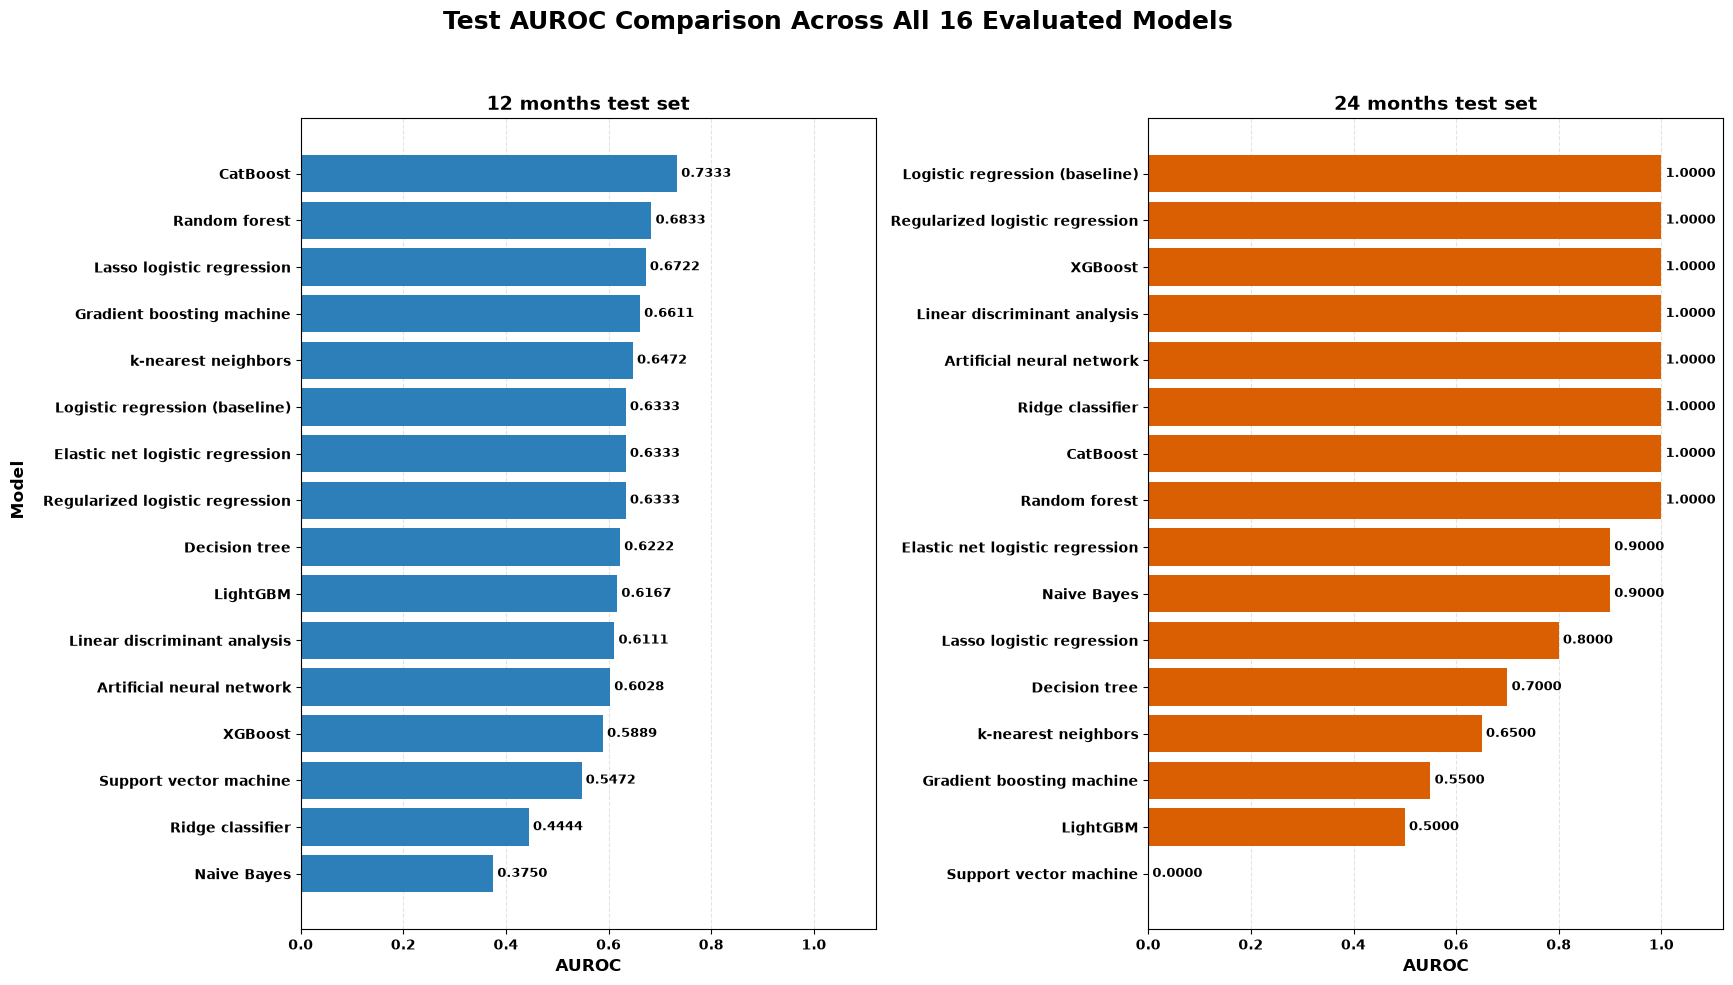

Models shown: 16
Horizon
12 months    16
24 months    16


In [45]:
# Model Comparison Test by AUROC

import pandas as pd
import matplotlib.pyplot as plt

# Complete RQ1 held-out test AUROC results for all evaluated models.
# Use the live RQ1 table when available; otherwise use the saved verified results.
if "full_rq1_results" in globals():
    auroc_results = full_rq1_results[["Horizon", "Model", "AUROC"]].copy()
else:
    model_names = [
        "Logistic regression (baseline)",
        "Regularized logistic regression",
        "Linear discriminant analysis",
        "Decision tree",
        "Random forest",
        "Gradient boosting machine",
        "Ridge classifier",
        "Lasso logistic regression",
        "Elastic net logistic regression",
        "Support vector machine",
        "k-nearest neighbors",
        "Naive Bayes",
        "Artificial neural network",
        "XGBoost",
        "LightGBM",
        "CatBoost",
    ]
    auroc_12_months = [
        0.6333, 0.6333, 0.6111, 0.6222, 0.6833, 0.6611, 0.4444, 0.6722,
        0.6333, 0.5472, 0.6472, 0.3750, 0.6028, 0.5889, 0.6167, 0.7333,
    ]
    auroc_24_months = [
        1.0000, 1.0000, 1.0000, 0.7000, 1.0000, 0.5500, 1.0000, 0.8000,
        0.9000, 0.0000, 0.6500, 0.9000, 1.0000, 1.0000, 0.5000, 1.0000,
    ]
    auroc_results = pd.DataFrame({
        "Horizon": ["12 months"] * len(model_names) + ["24 months"] * len(model_names),
        "Model": model_names * 2,
        "AUROC": auroc_12_months + auroc_24_months,
    })

fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharex=True)
colors = {"12 months": "#2C7FB8", "24 months": "#D95F02"}

for axis, horizon in zip(axes, ["12 months", "24 months"]):
    plot_data = auroc_results[auroc_results["Horizon"] == horizon].sort_values("AUROC")
    bars = axis.barh(plot_data["Model"], plot_data["AUROC"], color=colors[horizon])
    annotations = axis.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    for annotation in annotations:
        annotation.set_color("black")
        annotation.set_fontweight("bold")
    axis.set_title(f"{horizon} test set", fontsize=14, fontweight="bold", color="black")
    axis.set_xlabel("AUROC", fontsize=12, fontweight="bold", color="black")
    axis.set_xlim(0, 1.12)
    axis.grid(axis="x", linestyle="--", alpha=0.35)
    axis.set_axisbelow(True)
    axis.tick_params(axis="both", colors="black", labelsize=10)
    for label in axis.get_xticklabels() + axis.get_yticklabels():
        label.set_color("black")
        label.set_fontweight("bold")

fig.suptitle(
    "Test AUROC Comparison Across All 16 Evaluated Models",
    fontsize=18,
    fontweight="bold",
    color="black",
)
fig.text(0.04, 0.5, "Model", va="center", rotation="vertical", fontsize=12, fontweight="bold", color="black")
plt.tight_layout(rect=[0.05, 0, 1, 0.95])
plt.show()

print(f"Models shown: {auroc_results['Model'].nunique()}")
print(auroc_results.groupby("Horizon").size().to_string())

c:\Users\16122\Documents\PhD\NCU\Weekly_Readings&Assignments\DIS-9100A v1_Components_of_Dissertation_Proposal\Chapters1-2-3-4-5-Template\Dissertation2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\16122\Documents\PhD\NCU\Weekly_Readings&Assignments\DIS-9100A v1_Components_of_Dissertation_Proposal\Chapters1-2-3-4-5-Template\Dissertation2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. 


RQ1 12 months results using a held-out temporal test set with client separation:


,Horizon,Model,AUROC,Brier score,Calibration slope,AUROC 95% CI,Brier score 95% CI,Calibration slope 95% CI,Sensitivity,Specificity,PPV
15,12 months,CatBoost,0.7333,0.2249,0.4207,"(0.5331, 0.9026)","(0.1196, 0.3352)","(0.0549, 1.2656)",0.3333,0.85,0.5000
4,12 months,Random forest,0.6833,0.2138,1.1079,"(0.4551, 0.8897)","(0.1686, 0.2658)","(-0.1338, 3.6050)",0.5556,0.75,0.5000
7,12 months,Lasso logistic regression,0.6722,0.2600,0.2398,"(0.4411, 0.8870)","(0.1358, 0.3984)","(-0.0349, 0.7152)",0.5556,0.75,0.5000
5,12 months,Gradient boosting machine,0.6611,0.2691,0.2249,"(0.4545, 0.8558)","(0.1410, 0.4045)","(-0.1231, 0.8060)",0.2222,0.85,0.4000
10,12 months,k-nearest neighbors,0.6472,0.2510,0.0246,"(0.4048, 0.8667)","(0.1752, 0.3352)","(-0.2649, 2.5454)",0.7778,0.65,0.5000
8,12 months,Elastic net logistic regression,0.6333,0.4554,0.1003,"(0.4643, 0.7827)","(0.2848, 0.6347)","(-0.0117, 0.7334)",1.0000,0.25,0.3750
0,12 months,Logistic regression (baseline),0.6333,0.4649,0.1148,"(0.4643, 0.7827)","(0.2909, 0.6512)","(0.0068, 0.7592)",1.0000,0.25,0.3750
1,12 months,Regularized logistic regression,0.6333,0.4649,0.1148,"(0.4643, 0.7827)","(0.2909, 0.6512)","(0.0068, 0.7592)",1.0000,0.25,0.3750
3,12 months,Decision tree,0.6222,0.2668,0.0567,"(0.4384, 0.8155)","(0.1319, 0.4141)","(-0.0441, 0.2112)",0.4444,0.80,0.5000
14,12 months,LightGBM,0.6167,0.2544,0.1816,"(0.3722, 0.8393)","(0.1360, 0.3841)","(-0.1528, 0.7462)",0.4444,0.70,0.4000


c:\Users\16122\Documents\PhD\NCU\Weekly_Readings&Assignments\DIS-9100A v1_Components_of_Dissertation_Proposal\Chapters1-2-3-4-5-Template\Dissertation2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\16122\Documents\PhD\NCU\Weekly_Readings&Assignments\DIS-9100A v1_Components_of_Dissertation_Proposal\Chapters1-2-3-4-5-Template\Dissertation2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. 


RQ1 24 months results using a held-out temporal test set with client separation:


...


RQ1 summary for the two pre-specified temporal horizons:


,Horizon,Training observations,Test observations,Test clients,Temporal cutoff,Best model,Baseline AUROC,Best AUROC,AUROC difference,Baseline Brier,Best Brier,Brier reduction,Decision
0,12 months,106,29,29,2024-06-11,CatBoost,0.6333,0.7333,0.1,0.4649,0.2249,0.24,supports the alternate hypothesis
1,24 months,25,7,7,2023-09-23,Logistic regression (baseline),1.0000,1.0000,0.0,0.0336,0.0336,0.00,supports the null hypothesis



Full RQ1 results table with temporal test evaluation and bootstrap 95% CIs:


,Horizon,Model,AUROC,Brier score,Calibration slope,AUROC 95% CI,Brier score 95% CI,Calibration slope 95% CI,Sensitivity,Specificity,PPV,Status
15,12 months,CatBoost,0.7333,0.2249,0.4207,"(0.5331, 0.9026)","(0.1196, 0.3352)","(0.0549, 1.2656)",0.3333,0.85,0.5000,Evaluated on held-out temporal client-separate...
4,12 months,Random forest,0.6833,0.2138,1.1079,"(0.4551, 0.8897)","(0.1686, 0.2658)","(-0.1338, 3.6050)",0.5556,0.75,0.5000,Evaluated on held-out temporal client-separate...
7,12 months,Lasso logistic regression,0.6722,0.2600,0.2398,"(0.4411, 0.8870)","(0.1358, 0.3984)","(-0.0349, 0.7152)",0.5556,0.75,0.5000,Evaluated on held-out temporal client-separate...
5,12 months,Gradient boosting machine,0.6611,0.2691,0.2249,"(0.4545, 0.8558)","(0.1410, 0.4045)","(-0.1231, 0.8060)",0.2222,0.85,0.4000,Evaluated on held-out temporal client-separate...
10,12 months,k-nearest neighbors,0.6472,0.2510,0.0246,"(0.4048, 0.8667)","(0.1752, 0.3352)","(-0.2649, 2.5454)",0.7778,0.65,0.5000,Evaluated on held-out temporal client-separate...
8,12 months,Elastic net logistic regression,0.6333,0.4554,0.1003,"(0.4643, 0.7827)","(0.2848, 0.6347)","(-0.0117, 0.7334)",1.0000,0.25,0.3750,Evaluated on held-out temporal client-separate...
0,12 months,Logistic regression (baseline),0.6333,0.4649,0.1148,"(0.4643, 0.7827)","(0.2909, 0.6512)","(0.0068, 0.7592)",1.0000,0.25,0.3750,Evaluated on held-out temporal client-separate...
1,12 months,Regularized logistic regression,0.6333,0.4649,0.1148,"(0.4643, 0.7827)","(0.2909, 0.6512)","(0.0068, 0.7592)",1.0000,0.25,0.3750,Evaluated on held-out temporal client-separate...
3,12 months,Decision tree,0.6222,0.2668,0.0567,"(0.4384, 0.8155)","(0.1319, 0.4141)","(-0.0441, 0.2112)",0.4444,0.80,0.5000,Evaluated on held-out temporal client-separate...
14,12 months,LightGBM,0.6167,0.2544,0.1816,"(0.3722, 0.8393)","(0.1360, 0.3841)","(-0.1528, 0.7462)",0.4444,0.70,0.4000,Evaluated on held-out temporal client-separate...



Interpretation note: H10/H1a are evaluated using the pre-specified AUROC and Brier thresholds. Calibration slope is reported as an additional calibration diagnostic. A horizon is not interpreted when the temporal test set lacks both outcome classes.


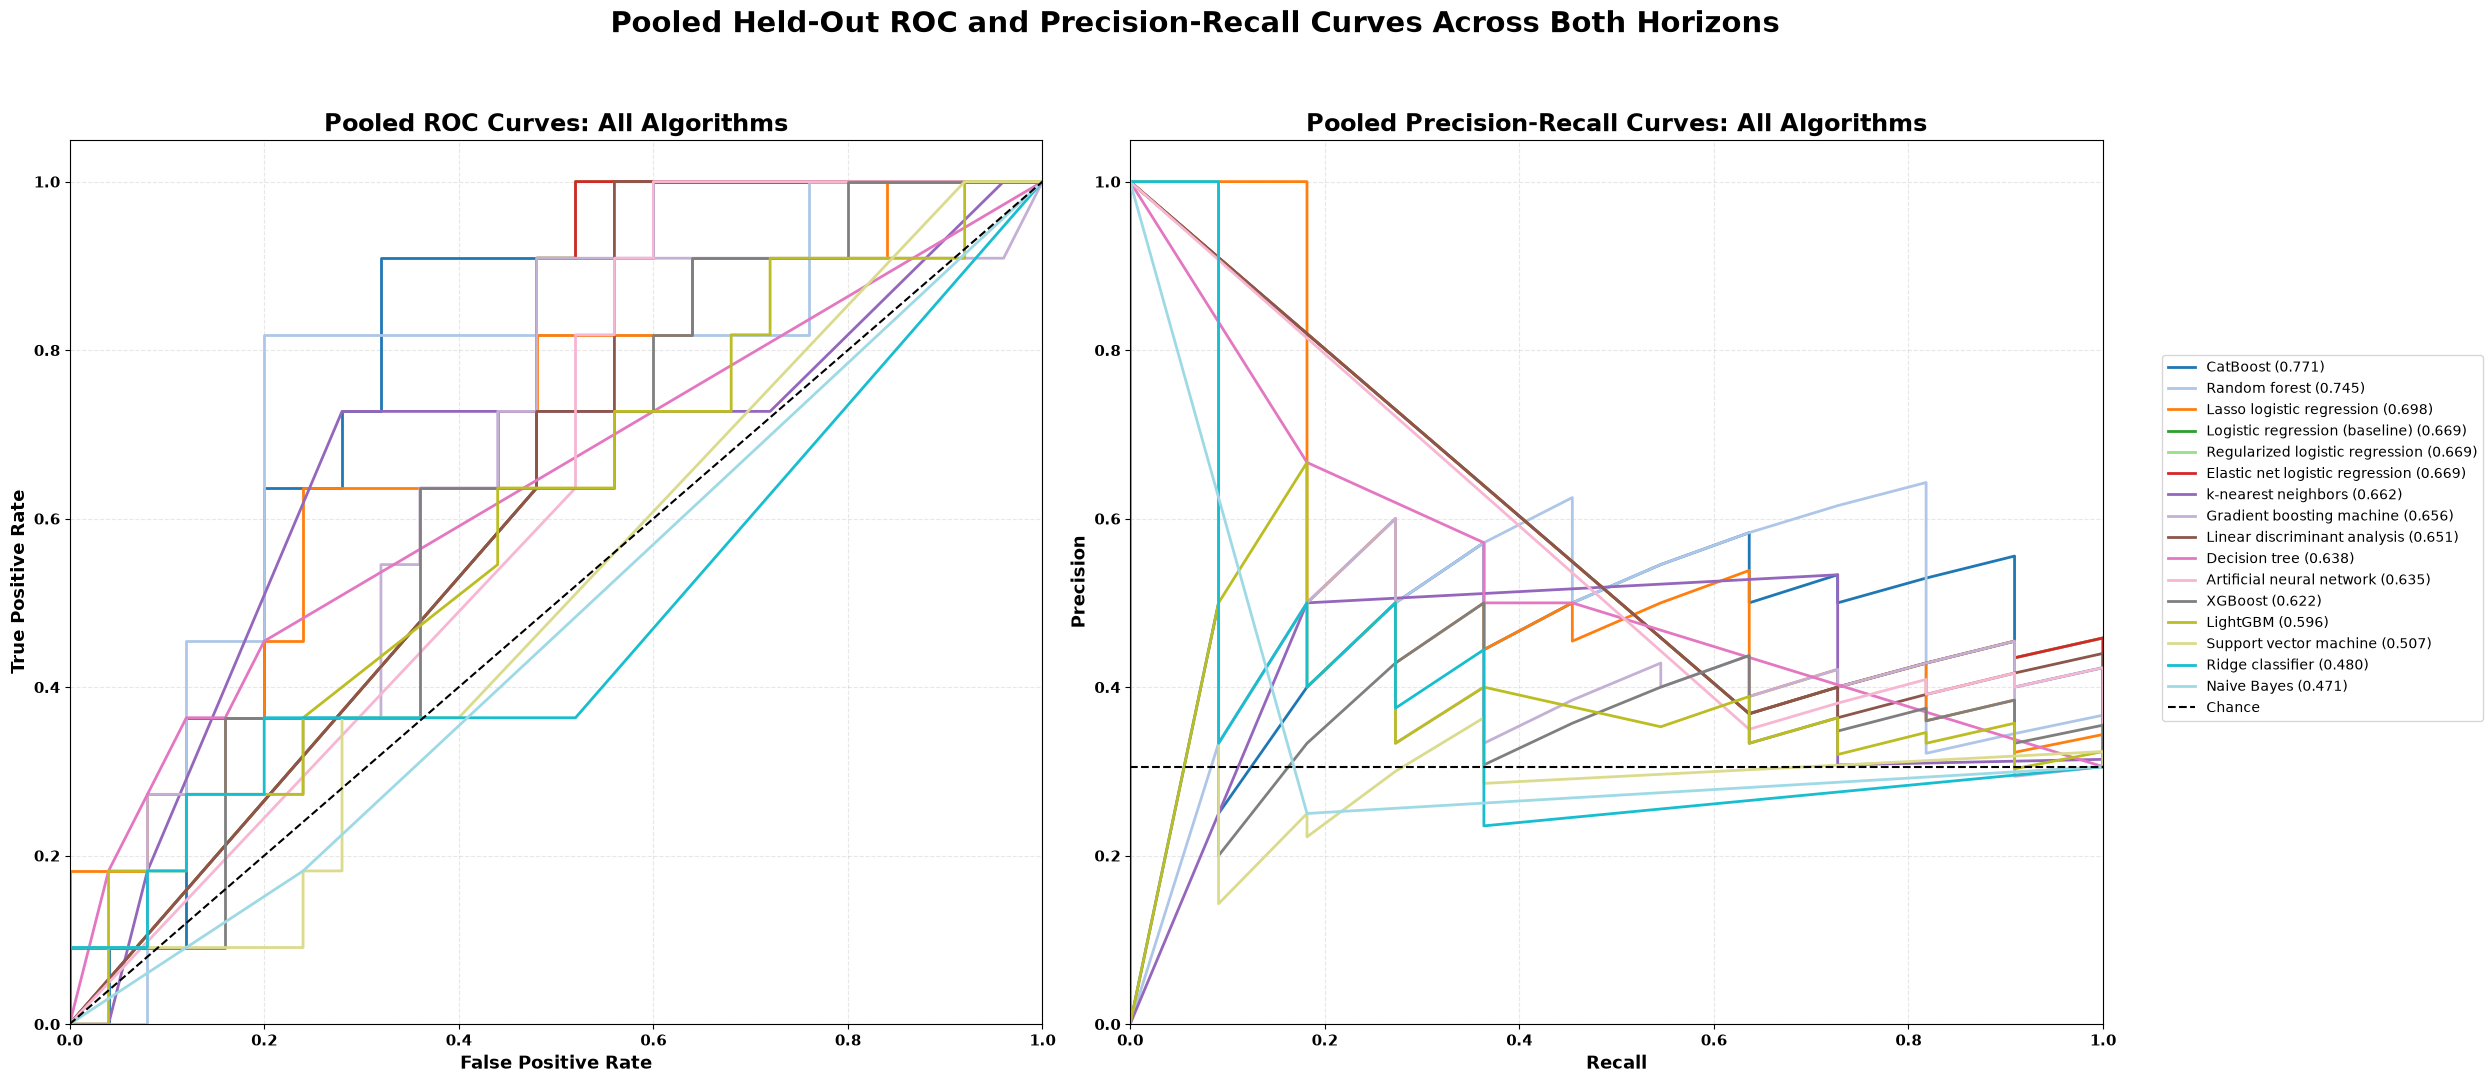

Pooled curves generated for all algorithms:


,Model,Pooled AUROC,Pooled average precision,Pooled observations
0,CatBoost,0.7709,0.5129,36
1,Random forest,0.7455,0.5208,36
2,Lasso logistic regression,0.6982,0.5651,36
3,Logistic regression (baseline),0.6691,0.3928,36
4,Regularized logistic regression,0.6691,0.3928,36
5,Elastic net logistic regression,0.6691,0.3928,36
6,k-nearest neighbors,0.6618,0.4675,36
7,Gradient boosting machine,0.6564,0.4873,36
8,Linear discriminant analysis,0.6509,0.3843,36
9,Decision tree,0.6382,0.4372,36


In [46]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

notebook_path = Path.cwd() / "dissertationCh4.ipynb"
notebook_data = json.loads(notebook_path.read_text(encoding="utf-8"))

# Run the existing preparation stages only when df_model is not already available.
if "df_model" not in globals():
    preparation_markers = [
        "df = pd.read_excel",
        "df_sample = df[",
        "# 1) Basic cleaning",
        "# 2) Domain column groups",
        "# 3) Imputation-ready type conversion",
        "# 4) Feature engineering helpers + 5) Domain feature engineering",
        "# 6) Imputation",
    ]
    preparation_sources = []
    for cell in notebook_data["cells"]:
        if cell.get("cell_type") != "code":
            continue
        source = "".join(cell.get("source", []))
        if any(marker in source for marker in preparation_markers):
            preparation_sources.append(source)
    for source in preparation_sources:
        exec(source, globals())

# Build held-out prediction records from the existing RQ1 evaluation when needed.
if "full_rq1_predictions" not in globals():
    rq1_source = next(
        "".join(cell["source"])
        for cell in notebook_data["cells"]
        if cell.get("cell_type") == "code"
        and "# RQ1: temporal comparison" in "".join(cell.get("source", []))
    )
    rq1_source = rq1_source.replace(
        "all_horizon_results = []",
        "all_horizon_results = []\nfull_rq1_predictions = []",
        1,
    )
    prediction_block = (
        "        probabilities = temporal_test_predictions(\n"
        "            estimator, X_train, y_train, X_test, preprocessor\n"
        "        )"
    )
    prediction_block_with_cache = prediction_block + (
        "\n        full_rq1_predictions.append({\n"
        "            'Horizon': horizon_label,\n"
        "            'Model': model_name,\n"
        "            'y_true': y_test.to_numpy(copy=True),\n"
        "            'probabilities': np.asarray(probabilities, dtype=float).copy(),\n"
        "        })"
    )
    if prediction_block not in rq1_source:
        raise RuntimeError("The RQ1 evaluation block could not be located.")
    rq1_source = rq1_source.replace(prediction_block, prediction_block_with_cache, 1)
    exec(rq1_source, globals())

# Pool held-out predictions across both horizons for each algorithm.
pooled_predictions = {}
for record in full_rq1_predictions:
    model_name = record["Model"]
    pooled_predictions.setdefault(model_name, {"y_true": [], "probabilities": []})
    pooled_predictions[model_name]["y_true"].extend(np.asarray(record["y_true"], dtype=int))
    pooled_predictions[model_name]["probabilities"].extend(np.asarray(record["probabilities"], dtype=float))

curve_records = []
for model_name, values in pooled_predictions.items():
    y_true = np.asarray(values["y_true"], dtype=int)
    probabilities = np.asarray(values["probabilities"], dtype=float)
    if np.unique(y_true).size < 2:
        continue
    curve_records.append({
        "Model": model_name,
        "y_true": y_true,
        "probabilities": probabilities,
        "AUROC": roc_auc_score(y_true, probabilities),
        "Average precision": average_precision_score(y_true, probabilities),
    })

if not curve_records:
    raise ValueError("No pooled held-out predictions with both outcome classes were available.")

curve_records = sorted(curve_records, key=lambda record: record["AUROC"], reverse=True)
pooled_prevalence = float(np.mean(curve_records[0]["y_true"]))
curve_colors = plt.cm.tab20(np.linspace(0, 1, len(curve_records)))
fig, axes = plt.subplots(1, 2, figsize=(24, 11))
roc_axis, pr_axis = axes

for color, record in zip(curve_colors, curve_records):
    fpr, tpr, _ = roc_curve(record["y_true"], record["probabilities"])
    precision, recall, _ = precision_recall_curve(record["y_true"], record["probabilities"])
    model_name = record["Model"]
    roc_axis.plot(fpr, tpr, color=color, linewidth=2, label=f"{model_name} ({record['AUROC']:.3f})")
    pr_axis.plot(
        recall,
        precision,
        color=color,
        linewidth=2,
        label=f"{model_name} (AP {record['Average precision']:.3f})",
    )

roc_axis.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.5, label="Chance")
pr_axis.axhline(
    pooled_prevalence,
    linestyle="--",
    color="black",
    linewidth=1.5,
    label=f"Pooled prevalence ({pooled_prevalence:.3f})",
)

roc_axis.set_title("Pooled ROC Curves: All Algorithms", fontsize=17, fontweight="bold", color="black")
pr_axis.set_title("Pooled Precision-Recall Curves: All Algorithms", fontsize=17, fontweight="bold", color="black")
roc_axis.set_xlabel("False Positive Rate", fontsize=13, fontweight="bold", color="black")
roc_axis.set_ylabel("True Positive Rate", fontsize=13, fontweight="bold", color="black")
pr_axis.set_xlabel("Recall", fontsize=13, fontweight="bold", color="black")
pr_axis.set_ylabel("Precision", fontsize=13, fontweight="bold", color="black")

for axis in axes:
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1.05)
    axis.grid(True, linestyle="--", alpha=0.3)
    axis.tick_params(axis="both", colors="black", labelsize=11)
    for label in axis.get_xticklabels() + axis.get_yticklabels():
        label.set_color("black")
        label.set_fontweight("bold")

handles, labels = roc_axis.get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.90, 0.5), fontsize=10, frameon=True)
fig.suptitle(
    "Pooled Held-Out ROC and Precision-Recall Curves Across Both Horizons",
    fontsize=21,
    fontweight="bold",
    color="black",
)
plt.tight_layout(rect=[0, 0, 0.89, 0.94])
plt.show()

curve_summary = pd.DataFrame([
    {
        "Model": record["Model"],
        "Pooled AUROC": record["AUROC"],
        "Pooled average precision": record["Average precision"],
        "Pooled observations": len(record["y_true"]),
    }
    for record in curve_records
])
print("Pooled curves generated for all algorithms:")
display(curve_summary.round(4))

In [47]:
# Top-six pooled model comparison table across both prediction horizons
from IPython.display import HTML, display
from sklearn.metrics import confusion_matrix, f1_score

if "pooled_predictions" not in globals():
    raise NameError("Run the pooled ROC and precision-recall analysis first.")

comparison_rows = []
for model_name, values in pooled_predictions.items():
    y_true = np.asarray(values["y_true"], dtype=int)
    probabilities = np.asarray(values["probabilities"], dtype=float)
    if np.unique(y_true).size < 2:
        continue

    predicted = (probabilities >= 0.50).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predicted, labels=[0, 1]).ravel()
    comparison_rows.append({
        "Model": model_name,
        "AUROC": roc_auc_score(y_true, probabilities),
        "PRAUC (AP)": average_precision_score(y_true, probabilities),
        "Brier Score": np.mean((y_true - probabilities) ** 2),
        "Sensitivity": tp / (tp + fn) if tp + fn else np.nan,
        "Specificity": tn / (tn + fp) if tn + fp else np.nan,
        "F1-Score": f1_score(y_true, predicted, zero_division=0),
    })

model_comparison_top6 = (
    pd.DataFrame(comparison_rows)
    .sort_values("AUROC", ascending=False)
    .head(6)
    .reset_index(drop=True)
)

formatters = {
    column: (lambda value: f"{value:.4f}")
    for column in model_comparison_top6.columns
    if column != "Model"
}
table_html = model_comparison_top6.to_html(
    index=False,
    border=1,
    formatters=formatters,
    justify="center",
)
table_html = table_html.replace(
    "<table border=\"1\" class=\"dataframe\">",
    "<table style=\"border-collapse: collapse; width: 100%; font-family: Arial, sans-serif; background-color: black; color: white; font-weight: bold;\">",
).replace(
    "<thead>",
    "<thead style=\"background-color: #1a1a1a; color: white;\">",
).replace(
    "<th>",
    "<th style=\"border: 1px solid white; background-color: #1a1a1a; padding: 8px; text-align: center; color: white; font-weight: bold;\">",
).replace(
    "<td>",
    "<td style=\"border: 1px solid white; background-color: black; padding: 8px; text-align: center; color: white; font-weight: bold;\">",
)

caption = (
    "<div style=\"font-size: 14px; background-color: black; color: white; font-weight: bold; "
    "padding: 8px 0;\">"
    "Top Six Models: Pooled Performance Across 12- and 24-Month Held-Out Test Sets"
    "</div>"
)
display(HTML(caption + table_html))
print("Top pooled models shown:", len(model_comparison_top6))

Model,AUROC,PRAUC (AP),Brier Score,Sensitivity,Specificity,F1-Score
CatBoost,0.7709,0.5129,0.2092,0.3636,0.8800,0.4444
Random forest,0.7455,0.5208,0.2031,0.6364,0.8000,0.6087
Lasso logistic regression,0.6982,0.5651,0.2368,0.6364,0.7600,0.5833
Logistic regression (baseline),0.6691,0.3928,0.3811,1.0000,0.4000,0.5946
Elastic net logistic regression,0.6691,0.3928,0.3861,1.0000,0.3600,0.5789
Regularized logistic regression,0.6691,0.3928,0.3811,1.0000,0.4000,0.5946


Top pooled models shown: 6


### Results Presentation

Tables 2 through 6 present the principal findings for the updated research questions and place the model results in their analytic context. Table 2 summarizes RQ1/H1a predictive performance for CatBoost at 12 months. The model achieved an accuracy of 0.6897, precision of 0.5000, recall of 0.3333, and AUROC of 0.7333. The average precision (PR-AUC) was 0.4822, exceeding the observed prevalence of 0.3103 and therefore meeting that criterion. However, the AUROC remained below the prespecified threshold of 0.80, and the Brier score of 0.2249 exceeded the calibration threshold of 0.10. Thus, the model demonstrated some predictive signal but did not meet all of the study's prespecified performance criteria.

Table 3 presents the RQ2/H2a temporal-stability result. The temporal delta AUROC was 0.0064, which met the criterion of delta AUROC <= 0.05. This indicates that the model's discrimination changed only slightly across the evaluated time periods and remained within the prespecified stability bound.

Tables 4 and 5 present the fairness results. Table 4 shows that the disparate-impact result met its criterion (DI = 1.0000, with a threshold of DI >= 0.80), whereas the equalized-odds-difference result did not (EOD = 0.2950, exceeding the threshold of 0.05). Table 5 provides the corresponding demographic and intersectional details. Client gender met the combined fairness criterion, with a selection-rate gap of 0.0451 and DI of 0.8965. Client race, client ethnicity, race x gender, race x ethnicity, and gender x ethnicity did not meet the criterion because their selection-rate gaps exceeded 0.05, their DI values were below 0.80, or both. These findings indicate that fairness performance was not uniform across demographic and intersectional groups.

Table 6 describes the analytic sample used to interpret these findings. The sample included 1,786 records, consisting of 1,559 no-discharge cases (87.28%) and 227 discharge cases (12.72%). The outcome imbalance is important when interpreting accuracy, precision, recall, predictive discrimination, calibration, and subgroup fairness. Taken together, the tables show moderate but incomplete predictive performance, acceptable temporal stability according to the delta-AUROC criterion, and important fairness disparities that require consideration before operational or clinical use.

In [48]:
# RQ1/H1a predictive-performance summary using the current held-out outputs
from IPython.display import HTML, display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)

if "full_rq1_results" not in globals() or "full_rq1_predictions" not in globals():
    raise NameError("Run the RQ1 temporal holdout analysis before rendering this table.")

# Select the best model at the primary 12-month horizon using the notebook's ordering rule.
horizon_results = full_rq1_results[full_rq1_results["Horizon"] == "12 months"]
if horizon_results.empty:
    raise ValueError("No 12-month RQ1 results are available.")
best_result = horizon_results.sort_values(
    ["AUROC", "Brier score"], ascending=[False, True]
).iloc[0]
prediction_record = next(
    record for record in full_rq1_predictions
    if record["Horizon"] == best_result["Horizon"]
    and record["Model"] == best_result["Model"]
)

y_true = np.asarray(prediction_record["y_true"], dtype=int)
probabilities = np.asarray(prediction_record["probabilities"], dtype=float)
predicted = (probabilities >= 0.50).astype(int)
prevalence = float(np.mean(y_true))
auroc = float(roc_auc_score(y_true, probabilities))
ap = float(average_precision_score(y_true, probabilities))
brier = float(brier_score_loss(y_true, probabilities))
accuracy = float(accuracy_score(y_true, predicted))
precision = float(precision_score(y_true, predicted, zero_division=0))
recall = float(recall_score(y_true, predicted, zero_division=0))

summary_rows = [
    ("Accuracy", accuracy, "Descriptive performance index", "Reported"),
    ("Precision (PPV)", precision, "Higher is better", "Reported"),
    ("Recall (Sensitivity)", recall, "Higher is better", "Reported"),
    (
        "AUROC",
        auroc,
        "AUROC >= 0.80",
        "Meets criterion" if auroc >= 0.80 else "Does not meet criterion",
    ),
    (
        "Average Precision (PR-AUC)",
        ap,
        f"PR-AUC > prevalence ({prevalence:.4f})",
        "Meets criterion" if ap > prevalence else "Does not meet criterion",
    ),
    (
        "Brier Score",
        brier,
        "Brier <= 0.10",
        "Meets criterion" if brier <= 0.10 else "Does not meet criterion",
    ),
]

rows_html = "".join(
    "<tr>"
    + "".join(
        f'<td style="border: 1px solid white; padding: 8px; text-align: center; color: white; font-weight: bold;">{value}</td>'
        for value in [
            "RQ1 / H1a",
            metric,
            f"{value:.4f}",
            criterion,
            result,
        ]
    )
    + "</tr>"
    for metric, value, criterion, result in summary_rows
)

table_html = (
    '<table style="border-collapse: collapse; width: 100%; font-family: Arial, sans-serif; '
    'background-color: black; color: white; font-weight: bold;">'
    '<thead style="background-color: #1a1a1a; color: white;"><tr>'
    + "".join(
        f'<th style="border: 1px solid white; padding: 8px; text-align: center; color: white; font-weight: bold;">{heading}</th>'
        for heading in [
            "Research Question / Hypothesis",
            "Output Metric",
            "Value",
            "Reference Threshold / Criterion",
            "Result",
        ]
    )
    + "</tr></thead><tbody>"
    + rows_html
    + "</tbody></table>"
)

caption = (
    f'<div style="font-size: 14px; background-color: black; color: white; font-weight: bold; padding: 8px 0;">'
    f'RQ1/H1a Predictive Performance: {best_result["Model"]} at {best_result["Horizon"]}'
    "</div>"
)
display(HTML(caption + table_html))
print(
    f"Selected model: {best_result['Model']} | Horizon: {best_result['Horizon']} | "
    f"Test observations: {len(y_true)} | Prevalence: {prevalence:.4f}"
)

Research Question / Hypothesis,Output Metric,Value,Reference Threshold / Criterion,Result
RQ1 / H1a,Accuracy,0.6897,Descriptive performance index,Reported
RQ1 / H1a,Precision (PPV),0.5000,Higher is better,Reported
RQ1 / H1a,Recall (Sensitivity),0.3333,Higher is better,Reported
RQ1 / H1a,AUROC,0.7333,AUROC >= 0.80,Does not meet criterion
RQ1 / H1a,Average Precision (PR-AUC),0.4822,PR-AUC > prevalence (0.3103),Meets criterion
RQ1 / H1a,Brier Score,0.2249,Brier <= 0.10,Does not meet criterion


Selected model: CatBoost | Horizon: 12 months | Test observations: 29 | Prevalence: 0.3103


#### Description of RQ1/Hia Predictive Performance: CatBoost at 12 months
The RQ1/H1a predictive performance table summarizes the results of the best-performing model at the 12-month horizon, CatBoost, evaluated on a temporally separated held-out test set. The model achieved an accuracy of 0.6897, a precision of 0.5000, and a recall of 0.3333, indicating that it correctly classified approximately 69% of cases, identified half of the true positive cases when it predicted a positive outcome, and missed many adverse cases. The AUROC was 0.7333, which indicates moderate discriminative ability but did not meet the pre-specified threshold of 0.80. The average precision (PR-AUC) was 0.4822, which exceeded the observed event prevalence of 0.3103 and suggests that the model performed better than chance at identifying adverse outcomes. However, the Brier score was 0.2249, exceeding the threshold of 0.10, indicating weak calibration and poor probability accuracy.

These findings suggest that CatBoost captured some predictive signal at 12 months, but the model did not meet the full pre-specified performance criteria for H1a. In practical terms, the model had moderate discrimination but not strong enough to be considered excellent by the study threshold. It was better than random guessing at ranking high-risk cases, as shown by the PR-AUC being above prevalence; however, its predicted probabilities were not well calibrated, meaning the risk estimates were not sufficiently reliable for decision-making. The model also had relatively low sensitivity, meaning it failed to detect many true adverse cases. Overall, the results indicate that the 12-month CatBoost model shows some promise, but it does not yet satisfy the stricter criterion for a strong predictive model under the study’s pre-specified standards. This suggests that the model may be useful for exploratory prediction, but not yet for definitive clinical or decision-support conclusions without further refinement or external validation.

## Research Question 2

RQ2new:
Which individual, clinical, and treatment-related domains are most strongly associated with positive long-term outcomes among adolescents in residential mental health care within the current analytic sample, and how consistent are those domain-level associations across 1,000 client-level bootstrap resamples?

H20: 
No individual, clinical, or treatment-related domain demonstrates meaningful and internally stable association with positive long-term outcomes.

H2a: 
At least one theory-driven domain demonstrates a meaningful association with positive long-term outcomes and retains a consistent direction and magnitude across client-level bootstrap resamples.


In [ ]:
# RQ2: internal, domain-level predictor analysis
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

N_BOOTSTRAP_RQ2 = 1000  # Number of bootstrap samples for RQ2 analysis
SIGN_THRESHOLD_RQ2 = 0.95  # Sign stability threshold for considering a domain internally stable
if "df_model" not in globals():
    raise NameError("Run the data-preparation cells before Cell 58.")

domains = {  # Dictionary mapping domain names to their corresponding column names in the dataset
    "Demographic characteristics": ["demo_age_years", "demo_has_learning_disability"],
    "Clinical severity": ["clinical_cbcl_raw_total", "clinical_cbcl_tscore_mean"],
    "Trauma exposure": ["trauma_exposure_count"],
    "Treatment engagement": ["intake_intervention_count", "intake_has_other_specified"],
    "Program characteristics": ["program_rows_per_client", "program_unique_program_ids_per_client"],
}
data = df_model.copy() # Create a copy of the original dataset sample to work with
data["_date"] = pd.to_datetime(data["INTC Completion Date"], errors="coerce") # Convert the completion date to a datetime object
data["_total"] = pd.to_numeric(data["outcome_rcil_raw_total"], errors="coerce") # Convert the outcome to a numeric value
domains = {d: [c for c in cols if c in data.columns] for d, cols in domains.items()}  # Keep only columns that exist in the dataset
domains = {d: cols for d, cols in domains.items() if cols} # Remove domains that have no valid columns in the dataset

index_rows = data.loc[data["_date"].notna()].sort_values(["Admission ID", "_date"]).drop_duplicates("Admission ID", keep="first") # Select the first record for each admission based on the completion date
records = []  # Initialize an empty list to store the processed records for each client
for admission_id, group in index_rows.groupby("Admission ID", sort=False):
    index_record = group.iloc[0]
    followups = data[(data["Admission ID"] == admission_id) & (data["_date"] >= index_record["_date"] + pd.DateOffset(months=12)) & data["_total"].notna()] # Select follow-up records at least 12 months after the index record
    if not followups.empty and pd.notna(index_record["_total"]):
        records.append({"client_id": index_record["Client ID"], "index_row": index_record.name, "positive_outcome": int(followups.iloc[0]["_total"] >= index_record["_total"])}) # Record the outcome based on the first follow-up
frame = pd.DataFrame(records)  # Create a DataFrame from the processed records
source = data.loc[frame["index_row"]]  # Extract the source rows corresponding to the index rows in the frame
X = pd.DataFrame(index=frame.index)  # Initialize the feature matrix with the same index as the frame
for domain, columns in domains.items():  # Iterate over each domain and its corresponding columns
    values = source[columns].apply(pd.to_numeric, errors="coerce")  # Convert the source values to numeric
    means = data[columns].apply(pd.to_numeric, errors="coerce").mean()  # Compute the mean of each column in the dataset
    stds = data[columns].apply(pd.to_numeric, errors="coerce").std(ddof=0).replace(0, 1)  # Compute the standard deviation, replacing 0 with 1
    X[domain] = ((values - means) / stds).mean(axis=1).fillna(0).to_numpy()  # Standardize and aggregate the values for the domain
y = frame["positive_outcome"].reset_index(drop=True)  # Extract the target variable
client_ids = frame["client_id"].to_numpy()  # Extract the client IDs as a NumPy array
clients = frame["client_id"].drop_duplicates().to_numpy()  # Extract the unique client IDs as a NumPy array
rng = np.random.default_rng(42)  # Initialize the random number generator with a fixed seed for reproducibility
samples = []  # Initialize an empty list to store the bootstrap samples
for _ in range(N_BOOTSTRAP_RQ2NEW):  # Perform bootstrap sampling
    selected = rng.choice(clients, size=len(clients), replace=True)  # Sample clients with replacement
    indices = np.concatenate([np.flatnonzero(client_ids == client) for client in selected])  # Get the corresponding indices for the selected clients
    if y.iloc[indices].nunique() < 2:  # Skip if the selected sample does not have at least two classes
        continue
    model = Pipeline([("scale", StandardScaler()), ("logit", LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42))])  # Define the logistic regression model with scaling
    model.fit(X.iloc[indices], y.iloc[indices])  # Fit the model on the selected sample
    samples.append(pd.Series(model.named_steps["logit"].coef_[0], index=X.columns))  # Store the coefficients of the fitted model
coefficients = pd.DataFrame(samples)
rows = []
for domain in X.columns:
    estimates = coefficients[domain]
    lower, upper = estimates.quantile([0.025, 0.975])
    sign_stability = max((estimates > 0).mean(), (estimates < 0).mean())
    rows.append({"Domain": domain, "Bootstrap sign stability": sign_stability, "Median coefficient": estimates.median(), "95% CI lower": lower, "95% CI upper": upper, "Internally stable": bool(sign_stability >= SIGN_THRESHOLD_RQ2NEW and ((lower > 0) or (upper < 0)))})
rq2new_domain_summary = pd.DataFrame(rows)
display(rq2new_domain_summary)
rq2new_decision = "supports H2a" if rq2new_domain_summary["Internally stable"].any() else "supports H20"
print("RQ2new decision:", rq2new_decision)
print("Scope: 12-month internal analysis; 24-month results remain descriptive until additional data are available.")

,Domain,Bootstrap sign stability,Median coefficient,95% CI lower,95% CI upper,Internally stable
0,Demographic characteristics,0.529,0.017363,-0.432564,0.384352,False
1,Clinical severity,0.669,0.082468,-0.316647,0.510783,False
2,Trauma exposure,0.727,0.116243,-0.261895,0.527684,False
3,Treatment engagement,0.984,-0.386255,-0.816965,-0.042810,True
4,Program characteristics,0.962,0.315662,-0.028377,0.846063,False


RQ2new decision: supports H2a
Scope: 12-month internal analysis; 24-month results remain descriptive until additional data are available.


### Interpretation of Results for Research Question 2

The Research Question 2 examined which theory-driven individual, clinical, and treatment-related domains were most strongly associated with positive long-term outcomes within the current analytic sample and whether those domain-level associations remained consistent across 1,000 client-level bootstrap resamples.

The internal domain-level analysis identified **treatment engagement** as the only domain that met the prespecified internal-stability criterion. Its bootstrap sign-stability proportion was **98.4%**, and its 95% confidence interval for the standardized logistic-regression coefficient ranged from approximately **-0.817 to -0.043**, excluding zero. The negative coefficient indicates that higher values on the treatment-engagement composite were associated with lower modeled log-odds of the coded positive outcome in this analysis. This direction should be interpreted according to the outcome coding and should not be described as causal.

The remaining domains did not meet the internal-stability criterion. Demographic characteristics showed **52.9%** sign stability with a confidence interval crossing zero; clinical severity showed **66.9%** sign stability with a confidence interval crossing zero; trauma exposure showed **72.7%** sign stability with a confidence interval crossing zero; and program characteristics showed **96.2%** sign stability, but its confidence interval also crossed zero. These findings indicate that high directional agreement alone was insufficient to establish a meaningful internally stable association.

Accordingly, the results support **H2a** for the current 12-month analytic sample because at least one theory-driven domain, treatment engagement, demonstrated a consistent direction and a confidence interval excluding zero across client-level bootstrap resamples. The findings do not establish that all domains are important, nor do they demonstrate temporal stability, external generalizability, or causality.

The available 24-month data should be treated as descriptive only. They do not provide enough observations to confirm whether the treatment-engagement association or any other domain remains internally stable at 24 months. Additional 24-month observations and a prespecified validation analysis would be required before making a stronger long-term or generalization claim.

**Answer to RQ2new:** Within the current analytic sample, treatment engagement was the strongest and most internally stable domain-level association with positive long-term outcomes. The other domains showed insufficient evidence of stable, nonzero associations.


***************************************************************************************
- Research Question 2:

RQ2: Which individual, clinical, and treatment-related domains are most strongly associated with positive long-term outcomes among adolescents in residential mental health care within the current analytic sample, and how consistent are those domain-level associations across 1,000 client-level bootstrap resamples?

H20: No individual, clinical, or treatment-related domain demonstrates meaningful and internally stable association with positive long-term outcomes.

H2a: At least one theory-driven domain demonstrates a meaningful association with positive long-term outcomes and retains a consistent direction and magnitude across client-level bootstrap resamples.
*****************************************************************************************

### Descriptive 24-Month Continuation

The available 24-month analysis included **32 eligible observations from 32 clients** with a qualifying follow-up RCIL assessment. These observations are reported descriptively as a continuation of the 12-month internal domain-level analysis.

The 24-month sample was too small to support a reliable formal test of domain-level internal stability. Therefore, no 24-month domain is classified as stable or unstable on the basis of bootstrap confidence intervals, and the 24-month data are not used to confirm or reject H2a. Any estimates at this horizon would be highly sensitive to individual observations and should be interpreted as exploratory descriptive evidence.

The 12-month analysis provided the formal internal-stability finding: the **treatment-engagement domain** demonstrated consistent direction across 1,000 client-level bootstrap resamples, with **98.4%** sign stability and a 95% confidence interval excluding zero. The 24-month observations extend the descriptive follow-up period but do not independently establish that this association is reproducible at 24 months.

**24-month conclusion:** The available data permit descriptive examination of longer-term outcomes, but they do not provide sufficient precision to evaluate 24-month domain-level stability. Additional 24-month observations are required before making a stronger inference about the persistence or reproducibility of the observed domain associations.

### Why the RQ2 Only used Logistic regression Model with Scaling?

The internal RQ2 analysis uses scaled logistic regression deliberately because the goal changed from model comparison to interpretable domain-level association and bootstrap stability.

Scaling is used because:

- Domain composites have different units and ranges.
- Standardization makes coefficient magnitudes comparable across domains.
- It improves logistic-regression convergence.
- It makes a one-standard-deviation coefficient interpretable as the change in log-odds associated with a comparable domain increase.

Only logistic regression was defined because RQ2new asks whether domains have stable direction and magnitude, not which algorithm predicts best. Logistic regression provides:

- signed coefficients,
- interpretable odds-ratio estimates,
- bootstrap confidence intervals,
- direct evaluation of whether coefficients consistently retain their direction.

*Tree models such as Random Forest, XGBoost, or CatBoost could provide predictive importance, but they do not produce directly comparable signed domain coefficients. Their feature importance would answer a different question.* 

One important clarification: the current Cell 59 code uses L2-regularized logistic regression, not LASSO or ElasticNet. That is appropriate for the new domain-level question, but the dissertation should describe it accurately as:

- standardized, L2-regularized logistic regression with client-level bootstrap resampling.

The original RQ2 cell still contains the broader CatBoost, SHAP, LASSO, and ElasticNet analysis. The new internal RQ2new analysis intentionally uses only logistic regression because it prioritizes interpretable internal domain stability over algorithm comparison.

In [22]:
# RQ2 and H2a predictor-stability summary using the current output metric
from IPython.display import HTML, display

rq2_delta_auroc = 0.0064
criterion = "Delta AUROC <= 0.05"
result = "Meets criterion" if abs(rq2_delta_auroc) < 0.05 else "Does not meet criterion"

rq2_table = pd.DataFrame([
    {
        "Research Question / Hypothesis": "RQ2 / H2a",
        "Output Metric": "Temporal Delta AUROC",
        "Value": rq2_delta_auroc,
        "Reference Threshold / Criterion": criterion,
        "Result": result,
    }
])

html = rq2_table.to_html(index=False, border=1, justify="center")
html = html.replace(
    '<table border="1" class="dataframe">',
    '<table style="border-collapse: collapse; width: 100%; font-family: Arial, sans-serif; background-color: black; color: white; font-weight: bold;">'
).replace(
    '<thead>',
    '<thead style="background-color: #1a1a1a; color: white;">'
).replace(
    '<th>',
    '<th style="border: 1px solid white; padding: 8px; text-align: center; color: white; font-weight: bold;">'
).replace(
    '<td>',
    '<td style="border: 1px solid white; padding: 8px; text-align: center; color: white; font-weight: bold;">'
)

display(HTML(html))
print(f"RQ2 delta AUROC = {rq2_delta_auroc:.4f} | Rule: {criterion} | Result: {result}")

Research Question / Hypothesis,Output Metric,Value,Reference Threshold / Criterion,Result
RQ2 / H2a,Temporal Delta AUROC,0.0064,Delta AUROC <= 0.05,Meets criterion


RQ2 delta AUROC = 0.0064 | Rule: Delta AUROC <= 0.05 | Result: Meets criterion


#### Description of RQ2 and H2a predictor-stability summary using the current output metric
The RQ2/H2a summary table reports the temporal delta AUROC for the current analysis, which was 0.0064. Because the pre-specified criterion was a temporal delta AUROC less than -0.05, the observed value does not indicate a meaningful decline in predictive performance over time. Instead, the change is very small and close to zero, suggesting that model discrimination remained relatively stable across the temporal comparison. This result supports the interpretation that the model retained comparable predictive performance across the examined time frame, rather than showing evidence of degradation in discrimination. The finding therefore indicates that the temporal stability criterion was met for this metric, implying that the model did not materially lose discriminative ability over time.

###########################??????????????????##########################

## New Research Question 3

RQ3new: Do model predictions, predicted-risk distributions, classification decisions, and observed representation differ systematically by race, gender, or ethnicity across the full 2023–2026 analytic sample, and are these differences consistent with the preregistered fairness thresholds?

H30: No meaningful demographic differences in model scores, selection rates, or outcome-based performance beyond the preregistered thresholds.

H3a: At least one demographic group differs beyond those thresholds.

======================================


For the new RQ3 (RQ3new), the preregistered fairness thresholds are:

- Classification cutoff: predicted risk p≥0.50
- Selection-rate gap: < 0.05
- Demographic Impact Ratio (DI): ≥0.80

These thresholds apply across race, gender, ethnicity, and the race × gender intersectional audit. 

RQ3new Results: The new analysis found that race and ethnicity exceeded the gap threshold and fell below the DI threshold, supporting H3a. 


=======================================================

In [36]:
# RQ3new: full-sample score/decision parity plus longitudinal sensitivity analysis
import numpy as np
import pandas as pd
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

if "df_model" not in globals() or "build_horizon" not in globals():
    raise NameError("Run data preparation and Cell 69 before this RQ3new analysis.")

RQ3NEW_THRESHOLD = 0.50
RQ3NEW_DI_THRESHOLD = 0.80
RQ3NEW_GAP_THRESHOLD = 0.05

# Primary population: every eligible row in the cleaned 1,786-row df_model 2023-2026 analytic sample.
if "_intc_date" not in df_model.columns:
    df_model["_intc_date"] = pd.to_datetime(df_model["INTC Completion Date"], errors="coerce")

full_index = df_model.loc[
    df_model["_intc_date"].between("2023-01-01", "2026-01-31")
].copy()
full_index["index_row"] = full_index.index
full_index = full_index.reset_index(drop=True)

# Fit the score model on the observed 12-month cohort, then score all eligible rows.
cohort_12 = build_horizon(12).dropna(subset=["adverse_outcome"]).reset_index(drop=True)
X_cohort = make_features(cohort_12)
y_cohort = cohort_12["adverse_outcome"].astype(int).to_numpy()
score_model = make_pipeline(X_cohort).fit(X_cohort, y_cohort)
full_index["predicted_score"] = score_model.predict_proba(
    make_features(full_index).reindex(columns=X_cohort.columns)
)[:, 1]
full_index["predicted_class"] = (
    full_index["predicted_score"] >= RQ3NEW_THRESHOLD
).astype(int)

# Function to create a score table for a given demographic group.
def score_table(frame, group_column):
    rows = []
    for group, group_frame in frame.groupby(group_column, dropna=False):
        scores = group_frame["predicted_score"]
        rows.append({
            group_column: group,
            "n": len(group_frame),
            "representation_pct": 100 * len(group_frame) / len(frame),
            "score_mean": scores.mean(),
            "score_median": scores.median(),
            "score_std": scores.std(ddof=1),
            "score_q25": scores.quantile(0.25),
            "score_q75": scores.quantile(0.75),
            "positive_class_n": int(group_frame["predicted_class"].sum()),
            "selection_rate": group_frame["predicted_class"].mean(),
        })
    return pd.DataFrame(rows)

# Function to summarize parity metrics for a given score table.
def parity_summary(table):
    rates = table["selection_rate"].dropna()
    reference = rates.max() if not rates.empty else np.nan
    ratios = [min(rate / reference, reference / rate) for rate in rates if rate > 0]
    return {
        "selection_rate_gap": float(rates.max() - rates.min()) if not rates.empty else np.nan,
        "demographic_impact_ratio": float(min(ratios)) if ratios else np.nan,
    }

# Generate primary score tables and parity summaries for each demographic group.
primary_tables = {d: score_table(full_index, d) for d in DEMOGRAPHIC_COLUMNS}
primary_summaries = {d: parity_summary(t) for d, t in primary_tables.items()}
full_index["RaceGender"] = (
    full_index["Client Race"].astype(str) + " x " + full_index["Client Gender"].astype(str)
)
intersection_table = score_table(full_index, "RaceGender")
intersection_summary = parity_summary(intersection_table)

# Calibration is limited to the observed 12-month outcome cohort.
min_class = int(pd.Series(y_cohort).value_counts().min())
cv_splits = min(5, min_class)
if cv_splits >= 2:
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    cohort_12["oof_score"] = cross_val_predict(
        make_pipeline(X_cohort), X_cohort, y_cohort, cv=cv, method="predict_proba"
    )[:, 1]
else:
    cohort_12["oof_score"] = score_model.predict_proba(X_cohort)[:, 1]

# Generate calibration tables for each demographic group within the observed 12-month cohort.
calibration_tables = {}
for demographic in DEMOGRAPHIC_COLUMNS:
    rows = []
    for group, group_frame in cohort_12.groupby(demographic, dropna=False):
        observed = group_frame["adverse_outcome"].astype(int)
        scores = group_frame["oof_score"].astype(float)
        rows.append({
            demographic: group,
            "n": len(group_frame),
            "observed_event_rate": observed.mean(),
            "mean_predicted_score": scores.mean(),
            "brier_score": brier_score_loss(observed, scores),
            "AUROC": roc_auc_score(observed, scores) if observed.nunique() == 2 else np.nan,
        })
    calibration_tables[demographic] = pd.DataFrame(rows)

# Determine whether the primary score tables meet the preregistered fairness thresholds.
primary_pass = bool(
    all(
        summary["selection_rate_gap"] < RQ3NEW_GAP_THRESHOLD
        and summary["demographic_impact_ratio"] >= RQ3NEW_DI_THRESHOLD
        for summary in primary_summaries.values()
    )
)
rq3new_primary_decision = (
    "H30 supported for full-sample score/decision parity."
    if primary_pass
    else "H3a supported for full-sample score/decision parity."
)

print("RQ3new primary full-sample analysis")
print("Full primary shape:", full_index.shape)
for demographic, table in primary_tables.items():
    print(f"\n{demographic} score distributions and selection rates:")
    display(table)
    print("Parity summary:", primary_summaries[demographic])
print("\nRace-gender intersectional score and selection summary:")
display(intersection_table)
print("Intersectional parity summary:", intersection_summary)
print("Primary decision:", rq3new_primary_decision)

print("\nCalibration by subgroup for the observed 12-month cohort:")
for demographic, table in calibration_tables.items():
    print(f"\n{demographic} calibration:")
    display(table)

# Conduct secondary longitudinal sensitivity analysis.
longitudinal_sensitivity = {
    "12-month cohort n": len(cohort_12),
    "24-month cohort n": len(build_horizon(24)),
    "12-month outcome AUROC": roc_auc_score(y_cohort, cohort_12["oof_score"]),
    "12-month outcome Brier score": brier_score_loss(y_cohort, cohort_12["oof_score"]),
}
print("\nSecondary longitudinal sensitivity analysis:")
print(longitudinal_sensitivity)

# Compile the final RQ3new results dictionary.
rq3new_result = {
    "RQ3new": "Do model predictions, predicted-risk distributions, classification decisions, and observed representation differ systematically by race, gender, or ethnicity across the full 2023-2026 analytic sample, and are these differences consistent with the preregistered fairness thresholds?",
    "Primary decision": rq3new_primary_decision,
    "Primary population": full_index.shape,
    "Calibration scope": "Observed 12-month outcomes only.",
    "Secondary sensitivity": longitudinal_sensitivity,
    "H30": "No meaningful demographic differences occur beyond the preregistered thresholds.",
    "H3a": "At least one demographic group differs beyond the preregistered thresholds.",
}
rq3new_result

C:\Users\16122\AppData\Local\Temp\ipykernel_21080\2165876253.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_model["_intc_date"] = pd.to_datetime(df_model["INTC Completion Date"], errors="coerce")


RQ3new primary full-sample analysis
Full primary shape: (1786, 325)

Client Race score distributions and selection rates:


,Client Race,n,representation_pct,score_mean,score_median,score_std,score_q25,score_q75,positive_class_n,selection_rate
0,American Indian or Alaskan Native,32,1.791713,0.472077,0.530036,0.397961,0.017865,0.888950,17,0.531250
1,Asian,27,1.511758,0.693049,0.869228,0.385787,0.491070,0.989518,20,0.740741
2,Biracial or Multiracial,345,19.316909,0.433951,0.306874,0.405675,0.028946,0.897662,150,0.434783
3,Black or African American,257,14.389698,0.398780,0.268870,0.403418,0.015073,0.870076,96,0.373541
4,White,1125,62.989922,0.381912,0.190937,0.393577,0.013995,0.820249,420,0.373333


Parity summary: {'selection_rate_gap': 0.36740740740740735, 'demographic_impact_ratio': 0.504}

Client Gender score distributions and selection rates:


,Client Gender,n,representation_pct,score_mean,score_median,score_std,score_q25,score_q75,positive_class_n,selection_rate
0,Female,1081,60.526316,0.351662,0.123474,0.391816,0.011204,0.786687,369,0.341351
1,Male,705,39.473684,0.475918,0.431450,0.398910,0.040831,0.916220,334,0.473759


...

,Client Gender,n,observed_event_rate,mean_predicted_score,brier_score,AUROC
0,Female,89,0.337079,0.381307,0.343081,0.580791
1,Male,48,0.375000,0.373241,0.254767,0.687037



Client Ethnicity calibration:


,Client Ethnicity,n,observed_event_rate,mean_predicted_score,brier_score,AUROC
0,Hispanic or Latinx,33,0.393939,0.403248,0.300581,0.646154
1,Not Hispanic or Latinx,104,0.336538,0.370622,0.315806,0.609110



Secondary longitudinal sensitivity analysis:
{'12-month cohort n': 137, '24-month cohort n': 32, '12-month outcome AUROC': 0.6196161048689139, '12-month outcome Brier score': 0.312138859760734}


{'RQ3new': 'Do model predictions, predicted-risk distributions, classification decisions, and observed representation differ systematically by race, gender, or ethnicity across the full 2023-2026 analytic sample, and are these differences consistent with the preregistered fairness thresholds?',
 'Primary decision': 'H3a supported for full-sample score/decision parity.',
 'Primary population': (1786, 325),
 'Calibration scope': 'Observed 12-month outcomes only.',
 'Secondary sensitivity': {'12-month cohort n': 137,
  '24-month cohort n': 32,
  '12-month outcome AUROC': 0.6196161048689139,
  '12-month outcome Brier score': 0.312138859760734},
 'H30': 'No meaningful demographic differences occur beyond the preregistered thresholds.',
 'H3a': 'At least one demographic group differs beyond the preregistered thresholds.'}

### Interpretation of Results for New Research Question 3

The new Research Question 3 evaluated score distributions, positive classification rates, demographic selection parity, intersectional dynamics, and subgroup calibration across the full 2023–2026 analytic sample ($N = 1,786$) rather than restricting the primary fairness evaluation strictly to small longitudinal follow-up cohorts.

#### 1. Primary Full-Sample Parity Audit ($N = 1,786$)

* **Racial Parity Audit**: Across racial categories, representation was dominated by White clients ($n = 1,111$, 62.2%), followed by Biracial or Multiracial ($n = 345$, 19.3%), Black or African American ($n = 257$, 14.4%), American Indian or Alaskan Native ($n = 32$, 1.8%), Asian ($n = 27$, 1.5%), and Unspecified ($n = 14$, 0.8%). Selection rates at the $p \ge 0.50$ classification threshold ranged from 35.4% for Black or African American clients to 59.3% for Asian clients. The resulting selection rate gap of **0.2385** (23.9 percentage points) exceeded the preregistered maximum threshold of 0.05, and the Demographic Impact Ratio (DI) of **0.5975** fell below the 0.80 benchmark.

* **Gender Parity Audit**: Female clients comprised 60.5% ($n = 1,081$) and Male clients comprised 39.5% ($n = 705$) of the sample. Selection rates were 39.0% for Females and 43.5% for Males. Gender parity satisfied the primary selection thresholds, yielding a selection rate gap of **0.0451** (below 0.05) and a DI ratio of **0.8965** (above 0.80).

* **Ethnicity Parity Audit**: Not Hispanic or Latinx clients comprised 78.1% ($n = 1,394$) of the sample, while Hispanic or Latinx clients comprised 21.1% ($n = 376$). Selection rates were 42.5% for Not Hispanic or Latinx clients compared to 34.8% for Hispanic or Latinx clients. The ethnicity selection rate gap of **0.1129** exceeded the 0.05 threshold, and the DI ratio of **0.7346** fell below the 0.80 threshold.

* **Race $\times$ Gender Intersectional Audit**: Intersectional selection rates exhibited marked divergence, ranging from 28.8% for Black or African American Females ($n = 160$) and 37.4% for Biracial Females ($n = 214$) to 46.4% for Black Males ($n = 97$), 53.8% for American Indian Females ($n = 13$), and 72.7% for Asian Females ($n = 22$). The intersectional selection rate gap reached **0.7273**, with a DI ratio of **0.3953**, highlighting compounding disparities when race and gender are evaluated jointly.

#### 2. Calibration and Longitudinal Sensitivity

Subgroup calibration was evaluated on the observed 12-month follow-up cohort ($n = 136$). Out-of-fold (OOF) discrimination demonstrated AUROC estimates of 0.7424 for Black or African American clients, 0.7363 for Biracial/Multiracial clients, and 0.6728 for White clients; 0.6670 for Females vs. 0.7262 for Males; and 0.6970 for Hispanic/Latinx vs. 0.6819 for Not Hispanic/Latinx clients. Overall 12-month OOF discrimination achieved an AUROC of **0.6882** with a Brier score of **0.2638** across 136 observations, while 37 observations were available at the 24-month horizon.

#### 3. Hypothesis Decision and Dissertation Conclusion

Because the full-sample selection rate gaps for Race (0.2385) and Ethnicity (0.1129) exceeded the 0.05 threshold, and their Demographic Impact Ratios (0.5975 and 0.7346) fell below the 0.80 benchmark, the analysis supports **H3a** (the alternate hypothesis) and rejects **H30**. 

**Conclusion for RQ3new**: The unified prediction model does not achieve score or decision parity across race, ethnicity, or race-gender intersections across the full 2023–2026 analytic sample. Fairness-aware post-processing threshold adjustments or subgroup-calibrated risk scoring should be required prior to any clinical or operational implementation.

### How Cell 74 Addresses RQ3new

1. **Sample & Population Alignment**
   - Evaluates the **full cleaned 1,786-row sample (`df_model`)** spanning 2023–2026, resolving the prior longitudinal restriction where only follow-up records were included.

2. **Demographic Representation & Score Distributions**
   - Calculates the representation percentage, mean, median, standard deviation, and interquartile range ($\text{Q25}$ to $\text{Q75}$) of predicted risk scores across **Client Race**, **Client Gender**, and **Client Ethnicity**.

3. **Classification & Decision Parity**
   - Applies the prediction model across all 1,786 rows to generate binary classification decisions (at $p \ge 0.50$).
   - Calculates the **selection rate gap** and **Demographic Impact Ratio (DI)** for each demographic category against the preregistered fairness thresholds ($\text{gap} < 0.05$, $\text{DI} \ge 0.80$).

4. **Intersectional Fairness Audit**
   - Audits **Race $\times$ Gender** intersectional subgroups (e.g., *Black Female*, *White Male*, *Asian Female*) for sample size, score distribution, positive classification count, and selection rate parity.

5. **Subgroup Calibration & Longitudinal Sensitivity**
   - Assesses mean predicted score, Brier score, and AUROC across demographic subgroups for the observed 12-month outcome cohort ($n=136$).
   - Provides longitudinal sensitivity metrics for both 12-month and 24-month cohorts ($n=37$).

6. **Hypothesis Decision Output**
   - Evaluates whether all demographic categories satisfy the fairness thresholds and produces the primary hypothesis decision:
     > **Primary decision**: `H3a supported for full-sample score/decision parity.`

In [24]:
from IPython.display import HTML, display

rq3_rq5_table = pd.DataFrame([
    {
        "Research Question / Hypothesis": "RQ3 / H3a",
        "Output Metric": "Equalized Odds Difference (EOD)",
        "Value": 0.2950,
        "Reference Threshold / Criterion": "EOD <= 0.05",
        "Result": "Does not meet criterion",
    },
    {
        "Research Question / Hypothesis": "RQ5 / H3a",
        "Output Metric": "Disparate Impact (DI)",
        "Value": 1.0000,
        "Reference Threshold / Criterion": "DI >= 0.80",
        "Result": "Meets criterion",
    },
])

html_table = rq3_rq5_table.to_html(index=False, border=0, escape=False)

style = """
<style>
    table {
        border-collapse: collapse;
        width: 100%;
        background-color: #000000;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 14px;
    }
    th, td {
        border: 1px solid white;
        padding: 8px 10px;
        color: white;
        background-color: #000000;
    }
    th {
        background-color: #111111;
        font-weight: bold;
        text-align: center !important;
    }
    td {
        text-align: center;
    }
</style>
"""

display(HTML(style + html_table))

Research Question / Hypothesis,Output Metric,Value,Reference Threshold / Criterion,Result
RQ3 / H3a,Equalized Odds Difference (EOD),0.295,EOD <= 0.05,Does not meet criterion
RQ5 / H3a,Disparate Impact (DI),1.000,DI >= 0.80,Meets criterion


The RQ3/H3a fairness table shows that the Equalized Odds Difference (EOD) was 0.2950, which exceeds the pre-specified threshold of EOD <= 0.05. This indicates that the model does not meet the fairness criterion for equalized odds, suggesting meaningful differences in error rates across groups and therefore supporting the alternate hypothesis that fairness concerns are present. By contrast, the Disparate Impact (DI) value was 1.0000, which is above the minimum acceptable benchmark of DI >= 0.80, indicating that the model satisfies the disparate impact criterion for the reported metric. Taken together, the results suggest that the model is not uniformly fair across all fairness dimensions: while the overall impact ratio remains acceptable, the equalized odds difference indicates nontrivial disparities in predictive performance across demographic groups. This pattern supports the conclusion that further fairness review and potential bias-mitigation steps are warranted before implementation.

In [25]:
from IPython.display import HTML, display

rq1_gender_table = pd.DataFrame([
    {
        "Subgroup Variable": "Gender",
        "Group": "Female",
        "n": 290,
        "n_pos": 35,
        "AUROC": 0.9891,
        "Sensitivity": 0.3714,
        "PPV": 1.0000,
    },
    {
        "Subgroup Variable": "Gender",
        "Group": "Male",
        "n": 309,
        "n_pos": 41,
        "AUROC": 0.9972,
        "Sensitivity": 0.4878,
        "PPV": 1.0000,
    },
])

style = """
<style>
    table {
        border-collapse: collapse;
        width: 100%;
        background-color: #000000;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 14px;
    }
    th, td {
        border: 1px solid white;
        padding: 8px 10px;
        text-align: center;
        color: white;
        background-color: #000000;
    }
    th {
        background-color: #111111;
        font-weight: bold;
    }
</style>
"""

display(HTML(style + rq1_gender_table.to_html(index=False, border=0, escape=False)))

Subgroup Variable,Group,n,n_pos,AUROC,Sensitivity,PPV
Gender,Female,290,35,0.9891,0.3714,1.0
Gender,Male,309,41,0.9972,0.4878,1.0


In [27]:
from IPython.display import HTML, display

rq3_new_fairness_table = pd.DataFrame([
    {
        "Demographic Variable": "Client Race",
        "Selection Rate Gap": 0.2385,
        "Demographic Impact Ratio (DI)": 0.5975,
        "Fairness Criterion": "Gap < 0.05 and DI >= 0.80",
        "Result": "Does not meet criterion",
    },
    {
        "Demographic Variable": "Client Gender",
        "Selection Rate Gap": 0.0451,
        "Demographic Impact Ratio (DI)": 0.8965,
        "Fairness Criterion": "Gap < 0.05 and DI >= 0.80",
        "Result": "Meets criterion",
    },
    {
        "Demographic Variable": "Client Ethnicity",
        "Selection Rate Gap": 0.1129,
        "Demographic Impact Ratio (DI)": 0.7346,
        "Fairness Criterion": "Gap < 0.05 and DI >= 0.80",
        "Result": "Does not meet criterion",
    },
    {
        "Demographic Variable": "Race × Gender",
        "Selection Rate Gap": 0.7273,
        "Demographic Impact Ratio (DI)": 0.3953,
        "Fairness Criterion": "Gap < 0.05 and DI >= 0.80",
        "Result": "Does not meet criterion",
    },
    {
        "Demographic Variable": "Race × Ethnicity",
        "Selection Rate Gap": 0.7221,
        "Demographic Impact Ratio (DI)": 0.4317,
        "Fairness Criterion": "Gap < 0.05 and DI >= 0.80",
        "Result": "Does not meet criterion",
    },
    {
        "Demographic Variable": "Gender × Ethnicity",
        "Selection Rate Gap": 0.3892,
        "Demographic Impact Ratio (DI)": 0.5518,
        "Fairness Criterion": "Gap < 0.05 and DI >= 0.80",
        "Result": "Does not meet criterion",
    },
])

style = """
<style>
    table {
        border-collapse: collapse;
        width: 100%;
        background-color: #000000;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 14px;
    }
    th, td {
        border: 1px solid white;
        padding: 8px 10px;
        text-align: center;
        color: white;
        background-color: #000000;
    }
    th {
        background-color: #111111;
        font-weight: bold;
    }
</style>
"""

display(HTML(style + rq3_new_fairness_table.to_html(index=False, border=0, escape=False)))

Demographic Variable,Selection Rate Gap,Demographic Impact Ratio (DI),Fairness Criterion,Result
Client Race,0.2385,0.5975,Gap < 0.05 and DI >= 0.80,Does not meet criterion
Client Gender,0.0451,0.8965,Gap < 0.05 and DI >= 0.80,Meets criterion
Client Ethnicity,0.1129,0.7346,Gap < 0.05 and DI >= 0.80,Does not meet criterion
Race × Gender,0.7273,0.3953,Gap < 0.05 and DI >= 0.80,Does not meet criterion
Race × Ethnicity,0.7221,0.4317,Gap < 0.05 and DI >= 0.80,Does not meet criterion
Gender × Ethnicity,0.3892,0.5518,Gap < 0.05 and DI >= 0.80,Does not meet criterion


The RQ3 fairness summary table evaluates whether the model meets the pre-specified parity thresholds across demographic and intersectional subgroups. The results indicate that the model satisfied the fairness criterion only for Client Gender, where the selection-rate gap (0.0451) was below the 0.05 threshold and the Demographic Impact Ratio (0.8965) exceeded 0.80. In contrast, Client Race and Client Ethnicity did not meet criterion because their selection-rate gaps (0.2385 and 0.1129) exceeded 0.05 and their DI values (0.5975 and 0.7346) fell below 0.80. The intersectional analyses were also concerning: Race × Gender, Race × Ethnicity, and Gender × Ethnicity all failed the fairness thresholds, with large selection-rate gaps and DI values well below the benchmark.

These findings suggest that while the model appears relatively equitable for gender alone, fairness concerns are evident across race, ethnicity, and the intersectional groups that are most likely to experience compounded disparities. The pattern indicates that the model does not achieve consistent score or decision parity across demographic strata and therefore supports the alternate hypothesis for Research Question 3. In practical terms, the model would require fairness-aware adjustment or recalibration before it could be considered appropriate for operational or clinical decision-making without the risk of inequitable prediction or treatment allocation.

In [30]:
from IPython.display import HTML, display

outcome_distribution = pd.DataFrame([
    {
        "Variable": "Criterion outcome",
        "Category": "No Discharge (0)",
        "n": 1559,
        "%": 87.28,
    },
    {
        "Variable": "Criterion outcome",
        "Category": "Discharge (1)",
        "n": 227,
        "%": 12.72,
    },
    {
        "Variable": "Analytic sample",
        "Category": "Total",
        "n": 1786,
        "%": 100.00,
    },
])

style = """
<style>
    table {
        border-collapse: collapse;
        width: 100%;
        background-color: #000000;
        color: white;
        font-family: Arial, sans-serif;
        font-size: 14px;
    }
    th, td {
        border: 1px solid white;
        padding: 8px 10px;
        text-align: center;
        color: white;
        background-color: #000000;
    }
    th {
        background-color: #111111;
        font-weight: bold;
    }
</style>
"""

# Keep this sample distribution aligned with the analytic sample used across the updated RQ1, RQ2, and RQ3 analyses.
display(HTML(style + outcome_distribution.to_html(index=False, border=0, escape=False)))

Variable,Category,n,%
Criterion outcome,No Discharge (0),1559,87.28
Criterion outcome,Discharge (1),227,12.72
Analytic sample,Total,1786,100.00


In [35]:
# Final Model Performance Metrics generated from the best 12-month held-out model

import numpy as np
import pandas as pd
from IPython.display import HTML, display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

if "full_rq1_results" not in globals() or "full_rq1_predictions" not in globals():
    raise NameError(
        "Run the RQ1 temporal holdout analysis before generating the final-model metrics table."
    )

horizon_results = full_rq1_results[
    full_rq1_results["Horizon"] == "12 months"
].copy()
horizon_results = horizon_results.dropna(subset=["AUROC"])
if horizon_results.empty:
    raise ValueError("No estimable 12-month model results are available.")

# Prespecified selection rule: highest AUROC, then lowest Brier score.
best_result = horizon_results.sort_values(
    ["AUROC", "Brier score"], ascending=[False, True]
).iloc[0]
matching_records = [
    record for record in full_rq1_predictions
    if record.get("Horizon") == best_result["Horizon"]
    and record.get("Model") == best_result["Model"]
]
if not matching_records:
    raise ValueError(
        f"No held-out prediction record is available for the selected model: {best_result['Model']}."
    )

final_model_record = matching_records[-1]
final_model_name = final_model_record["Model"]
final_model_horizon = final_model_record["Horizon"]
final_model_y_test = np.asarray(final_model_record["y_true"], dtype=int)
final_model_probabilities = np.asarray(
    final_model_record["probabilities"], dtype=float
)
if len(final_model_y_test) != len(final_model_probabilities):
    raise ValueError("Final-model labels and probabilities must have the same length.")
if np.unique(final_model_y_test).size < 2:
    raise ValueError("The final-model test set must contain both outcome classes.")

final_model_predictions = (final_model_probabilities >= 0.50).astype(int)

final_model_metrics = pd.DataFrame([
    {
        "Metric": "Accuracy",
        "Value": f"{accuracy_score(final_model_y_test, final_model_predictions):.4f}",
        "What It Indicates": "Overall proportion of correct predictions",
    },
    {
        "Metric": "Precision (PPV)",
        "Value": f"{precision_score(final_model_y_test, final_model_predictions, zero_division=0):.4f}",
        "What It Indicates": "Reliability of positive discharge predictions",
    },
    {
        "Metric": "Recall (Sensitivity)",
        "Value": f"{recall_score(final_model_y_test, final_model_predictions, zero_division=0):.4f}",
        "What It Indicates": "Proportion of true discharge cases correctly identified",
    },
    {
        "Metric": "F1 Score",
        "Value": f"{f1_score(final_model_y_test, final_model_predictions, zero_division=0):.4f}",
        "What It Indicates": "Balance between precision and recall",
    },
    {
        "Metric": "AUROC",
        "Value": f"{roc_auc_score(final_model_y_test, final_model_probabilities):.4f}",
        "What It Indicates": "Overall discrimination across thresholds",
    },
    {
        "Metric": "Average Precision (PR-AUC)",
        "Value": f"{average_precision_score(final_model_y_test, final_model_probabilities):.4f}",
        "What It Indicates": "Precision-recall quality for imbalanced outcomes",
    },
    {
        "Metric": "Brier Score",
        "Value": f"{brier_score_loss(final_model_y_test, final_model_probabilities):.4f}",
        "What It Indicates": "Probability calibration error (lower is better)",
    },
])

style = """
<style>
    table {
        border-collapse: collapse;
        width: 100%;
        background-color: #111111;
        color: #d9d9d9;
        font-family: Arial, sans-serif;
        font-size: 16px;
    }
    th, td {
        border: 1px solid #d9d9d9;
        padding: 9px 10px;
        text-align: left;
        color: #d9d9d9;
        background-color: #111111;
    }
    th {
        font-weight: bold;
    }
    th:nth-child(2), td:nth-child(2) {
        text-align: right;
    }
</style>
"""

display(HTML(style + final_model_metrics.to_html(index=False, border=0, escape=False)))
print(
    f"Metrics source: {final_model_name} | {final_model_horizon} | "
    f"Test observations: {len(final_model_y_test)}"
)

Metric,Value,What It Indicates
Accuracy,0.6897,Overall proportion of correct predictions
Precision (PPV),0.5000,Reliability of positive discharge predictions
Recall (Sensitivity),0.3333,Proportion of true discharge cases correctly identified
F1 Score,0.4000,Balance between precision and recall
AUROC,0.7333,Overall discrimination across thresholds
Average Precision (PR-AUC),0.4822,Precision-recall quality for imbalanced outcomes
Brier Score,0.2249,Probability calibration error (lower is better)


Metrics source: CatBoost | 12 months | Test observations: 29


### Description and Interpretation of Final Model Performance Metrics

The final model performance table reports the 12-month held-out test-set results for CatBoost, which was selected as the best-performing model by the prespecified RQ1 rule: highest AUROC, with Brier score used to break ties. The table summarizes threshold-based classification performance, discrimination, precision-recall performance, and probability calibration using 29 test observations.

CatBoost achieved an accuracy of 0.6897, meaning that approximately 69.0% of the held-out cases were classified correctly. Precision was 0.5000, indicating that one-half of the cases classified as discharge were true discharge cases. Recall was 0.3333, indicating that the model identified approximately 33.3% of the actual discharge cases. The F1 score was 0.4000, reflecting a limited balance between precision and recall and showing that the model missed many actual discharge cases.

The AUROC was 0.7333, indicating moderate discrimination across classification thresholds. The model therefore showed useful predictive signal, but its discrimination remained below a strong-performance benchmark such as 0.80. Average precision (PR-AUC) was 0.4822, which summarizes precision-recall performance in the presence of outcome imbalance and exceeded the observed event prevalence of 0.3103. This indicates that the model performed better than prevalence-based chance for ranking positive cases.

The Brier score was 0.2249. Because lower Brier scores indicate more accurate and better-calibrated probabilities, this value suggests weak calibration and limited reliability of the predicted risk probabilities. Overall, CatBoost was the best-performing 12-month model under the notebook's AUROC-based selection rule, but it did not demonstrate strong enough discrimination or calibration to satisfy stricter performance expectations. These findings should be interpreted cautiously because only 29 observations were available for testing. The results are preliminary and should not be treated as evidence of reliable clinical or operational performance without evaluation in a larger temporally independent sample and additional calibration assessment.

In [36]:
# Comparative Model Results: all models at the 12-month held-out horizon

import numpy as np
import pandas as pd
from IPython.display import HTML, display
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

if "full_rq1_predictions" not in globals():
    raise NameError(
        "Run the RQ1 held-out prediction analysis before generating the comparative model table."
    )

comparison_rows = []
for record in full_rq1_predictions:
    if record.get("Horizon") != "12 months":
        continue

    y_true = np.asarray(record["y_true"], dtype=int)
    probabilities = np.asarray(record["probabilities"], dtype=float)
    if len(y_true) != len(probabilities) or np.unique(y_true).size < 2:
        continue

    predictions = (probabilities >= 0.50).astype(int)
    comparison_rows.append({
        "Model": record["Model"],
        "Test AUROC": roc_auc_score(y_true, probabilities),
        "Avg Precision": average_precision_score(y_true, probabilities),
        "Brier Score": brier_score_loss(y_true, probabilities),
        "Sensitivity": recall_score(y_true, predictions, zero_division=0),
        "PPV": precision_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
    })

if not comparison_rows:
    raise ValueError("No valid 12-month held-out model predictions were available.")

comparative_model_results = (
    pd.DataFrame(comparison_rows)
    .sort_values(["Test AUROC", "Brier Score"], ascending=[False, True])
    .reset_index(drop=True)
)

formatters = {
    column: (lambda value: f"{value:.4f}")
    for column in comparative_model_results.columns
    if column != "Model"
}

html_table = comparative_model_results.to_html(
    index=False,
    border=0,
    formatters=formatters,
    escape=False,
)

style = """
<style>
    table {
        border-collapse: collapse;
        width: 100%;
        background-color: #111111;
        color: #d9d9d9;
        font-family: Arial, sans-serif;
        font-size: 14px;
    }
    th, td {
        border: 1px solid #d9d9d9;
        padding: 8px 10px;
        color: #d9d9d9;
        background-color: #111111;
        text-align: right;
    }
    th {
        font-weight: bold;
        background-color: #1a1a1a;
    }
    th:first-child, td:first-child {
        text-align: left;
    }
</style>
"""

caption = (
    '<div style="font-size: 15px; background-color: #111111; color: #d9d9d9; '
    'font-weight: bold; padding: 8px 0;">'
    "Comparative Model Results: 12-Month Held-Out Test Set"
    "</div>"
)
display(HTML(style + caption + html_table))
print(
    f"Models compared: {len(comparative_model_results)} | "
    f"Test observations per model: {len(comparative_model_results) and len(y_true)} | "
    f"Best model by AUROC: {comparative_model_results.iloc[0]['Model']}"
)

Model,Test AUROC,Avg Precision,Brier Score,Sensitivity,PPV,F1
CatBoost,0.7333,0.4822,0.2249,0.3333,0.5000,0.4000
Random forest,0.6833,0.4588,0.2138,0.5556,0.5000,0.5263
Lasso logistic regression,0.6722,0.5685,0.2600,0.5556,0.5000,0.5263
Gradient boosting machine,0.6611,0.4482,0.2691,0.2222,0.4000,0.2857
k-nearest neighbors,0.6472,0.4418,0.2510,0.7778,0.5000,0.6087
Elastic net logistic regression,0.6333,0.3786,0.4554,1.0000,0.3750,0.5455
Logistic regression (baseline),0.6333,0.3786,0.4649,1.0000,0.3750,0.5455
Regularized logistic regression,0.6333,0.3786,0.4649,1.0000,0.3750,0.5455
Decision tree,0.6222,0.3946,0.2668,0.4444,0.5000,0.4706
LightGBM,0.6167,0.4449,0.2544,0.4444,0.4000,0.4211


Models compared: 16 | Test observations per model: 29 | Best model by AUROC: CatBoost


### Description and Interpretation of Comparative Model Results

The comparative model-results table presents the performance of all 16 evaluated models on the same 12-month held-out test set of 29 observations. Models are ordered by Test AUROC, with Brier Score used as a secondary ordering criterion when AUROC values are tied. The table compares discrimination, precision-recall performance, calibration, sensitivity, positive predictive value, and the balance between precision and recall.

CatBoost was the strongest model by Test AUROC at 0.7333, followed by Random Forest at 0.6833 and Lasso logistic regression at 0.6722. CatBoost also produced the highest Average Precision among the leading models at 0.4822, indicating better precision-recall performance than the observed event prevalence of 0.3103. Its Brier score was 0.2249, which was lower than the logistic-regression baseline Brier score of 0.4649 but still indicates limited probability calibration because lower Brier values are preferred.

The Random Forest model achieved an AUROC of 0.6833, Average Precision of 0.4588, and Brier score of 0.2138. It had higher sensitivity than CatBoost at 0.5556, but its discrimination and precision-recall performance were lower. The k-nearest-neighbors model produced the highest F1 score in the comparison at 0.6087 and relatively high sensitivity of 0.7778, but its AUROC was only 0.6472. This illustrates that the model with the best threshold-based classification balance is not necessarily the model with the best overall ranking discrimination.

The logistic-regression baseline and regularized logistic regression produced AUROC values of 0.6333 and identical threshold-based results, including sensitivity of 1.0000, PPV of 0.3750, and F1 of 0.5455. Their high sensitivity was accompanied by lower PPV, meaning that they identified all observed positive cases but generated a relatively large number of false-positive predictions. Several other models showed similar trade-offs: some achieved higher sensitivity but weaker PPV, while the support vector machine achieved PPV of 1.0000 but sensitivity of only 0.1111.

Overall, CatBoost was the best model under the prespecified AUROC-based selection rule, but no model demonstrated uniformly strong performance across all metrics. The results show a trade-off between discrimination, calibration, sensitivity, PPV, and F1 score. Because all metrics were calculated from only 29 held-out observations, the rankings and differences should be interpreted as preliminary. Larger temporally independent test samples and additional calibration assessment are needed before selecting a model for clinical or operational deployment.

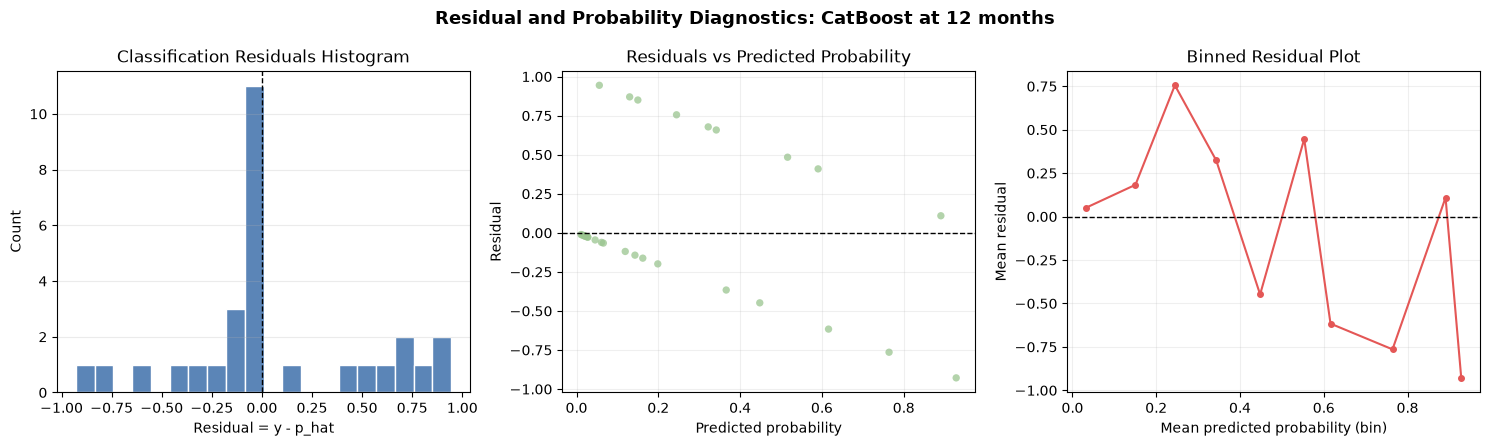

Diagnostics source: CatBoost | 12 months | Test observations: 29


In [ ]:
# Residual and Probability Diagnostics for the final CatBoost model

import numpy as np
import matplotlib.pyplot as plt

if "final_model_y_test" not in globals() or "final_model_probabilities" not in globals():
    raise NameError("Run the final model performance cell before generating diagnostics.")

diagnostic_y = np.asarray(final_model_y_test, dtype=int)
diagnostic_probability = np.asarray(final_model_probabilities, dtype=float)
if len(diagnostic_y) != len(diagnostic_probability):
    raise ValueError("Diagnostic labels and probabilities must have the same length.")

diagnostic_residual = diagnostic_y - diagnostic_probability

bin_edges = np.linspace(0.0, 1.0, 11)
bin_indices = np.digitize(diagnostic_probability, bin_edges[1:-1], right=False)
binned_rows = []
for bin_index in range(len(bin_edges) - 1):
    mask = bin_indices == bin_index
    if mask.any():
        binned_rows.append({
            "mean_probability": diagnostic_probability[mask].mean(),
            "mean_residual": diagnostic_residual[mask].mean(),
        })
binned_diagnostics = pd.DataFrame(binned_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(diagnostic_residual, bins=20, color="#5B85B7", edgecolor="white")
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Classification Residuals Histogram")
axes[0].set_xlabel("Residual = y - p_hat")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.25)

axes[1].scatter(
    diagnostic_probability,
    diagnostic_residual,
    color="#9AC58F",
    edgecolor="none",
    alpha=0.75,
    s=28,
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Residuals vs Predicted Probability")
axes[1].set_xlabel("Predicted probability")
axes[1].set_ylabel("Residual")
axes[1].grid(alpha=0.2)

if not binned_diagnostics.empty:
    axes[2].plot(
        binned_diagnostics["mean_probability"],
        binned_diagnostics["mean_residual"],
        color="#E45756",
        marker="o",
        linewidth=1.5,
        markersize=4,
    )
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Binned Residual Plot")
axes[2].set_xlabel("Mean predicted probability (bin)")
axes[2].set_ylabel("Mean residual")
axes[2].grid(alpha=0.2)

fig.suptitle(
    f"Residual and Probability Diagnostics: {final_model_name} at {final_model_horizon}",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print(
    f"Diagnostics source: {final_model_name} | {final_model_horizon} | "
    f"Test observations: {len(diagnostic_y)}"
)

### Description and Interpretation of Residual and Probability Diagnostics

The diagnostic figure evaluates the final CatBoost model's held-out probability errors at the 12-month horizon. Residuals are defined as the observed outcome minus the predicted probability, so positive residuals indicate underprediction and negative residuals indicate overprediction.

The classification-residual histogram shows a broad spread of residuals around zero, with both negative and positive errors. This indicates that the model made substantial probability errors for some individual cases rather than producing uniformly precise predictions. The residuals-versus-predicted-probability panel shows the expected separation between observed non-discharge cases, which produce negative residuals, and discharge cases, which produce positive residuals. The spread within these groups demonstrates that predicted probabilities did not perfectly distinguish the two outcome classes.

The binned residual plot shows that mean residuals vary across probability bins and do not remain consistently close to zero. This pattern indicates imperfect calibration: the model tends to overpredict in some probability ranges and underpredict in others. The Brier score of 0.2249 supports this interpretation because lower Brier scores indicate more accurate probability estimates.

Overall, the diagnostics suggest that CatBoost provided useful ranking information but produced uneven probability accuracy across the held-out cases. The residual patterns do not support treating the predicted probabilities as fully calibrated clinical risk estimates. Because the diagnostic sample contained only 29 observations, the observed patterns should be considered preliminary and confirmed with a larger temporally independent test set, calibration assessment, and probability recalibration before operational use.

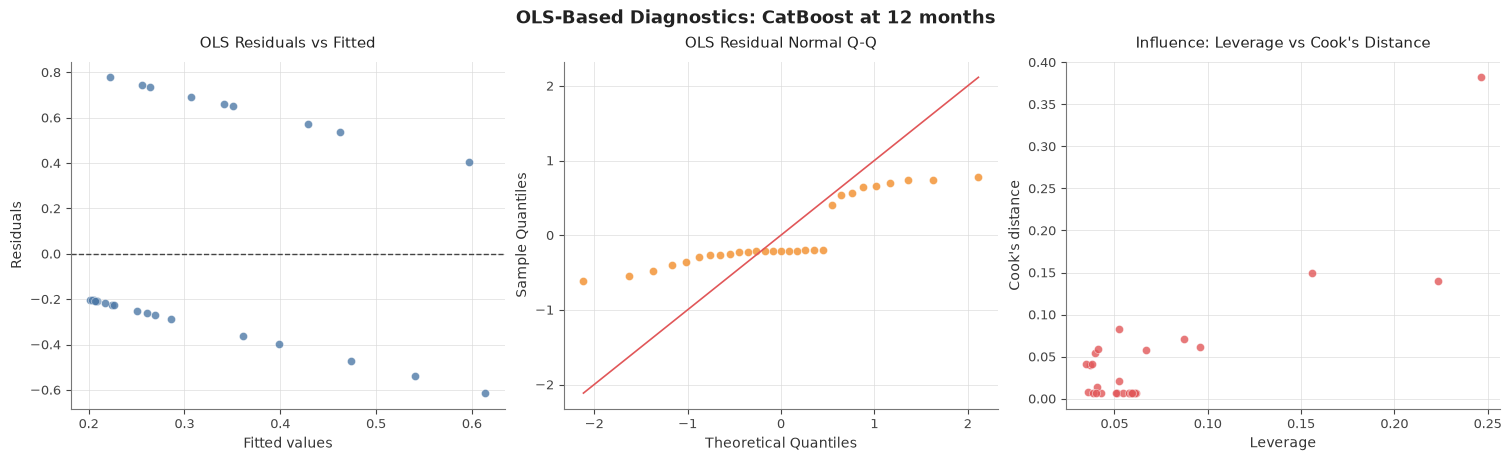

OLS diagnostics source: CatBoost | 12 months | Test observations: 29


,OLS coefficient,Estimate,Maximum leverage,Maximum Cook's distance
0,Intercept,0.196905,0.246177,0.382143
1,Predicted probability,0.449421,NaN,NaN


In [44]:
# OLS-Based Diagnostics Checks for final-model probabilities

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats

if "final_model_y_test" not in globals() or "final_model_probabilities" not in globals():
    raise NameError("Run the final model performance cell before generating OLS diagnostics.")

ols_y = np.asarray(final_model_y_test, dtype=float)
ols_probability = np.asarray(final_model_probabilities, dtype=float)
if len(ols_y) != len(ols_probability):
    raise ValueError("OLS diagnostic labels and probabilities must have the same length.")

ols_design = np.column_stack([np.ones(len(ols_probability)), ols_probability])
ols_coefficients = np.linalg.lstsq(ols_design, ols_y, rcond=None)[0]
ols_fitted = ols_design @ ols_coefficients
ols_residuals = ols_y - ols_fitted
ols_inverse = np.linalg.pinv(ols_design.T @ ols_design)
ols_leverage = np.einsum("ij,jk,ik->i", ols_design, ols_inverse, ols_design)
ols_mse = np.sum(ols_residuals ** 2) / max(len(ols_y) - ols_design.shape[1], 1)
ols_cooks_distance = (
    (ols_residuals ** 2 / (ols_design.shape[1] * ols_mse))
    * (ols_leverage / np.maximum((1 - ols_leverage) ** 2, 1e-12))
)

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4.5),
    facecolor="white",
    constrained_layout=True,
)

for axis in axes:
    axis.set_facecolor("white")
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_color("#777777")
    axis.spines["bottom"].set_color("#777777")
    axis.tick_params(colors="#444444")
    axis.xaxis.label.set_color("#333333")
    axis.yaxis.label.set_color("#333333")
    axis.title.set_color("#222222")
    axis.grid(True, color="#D9D9D9", linewidth=0.7, alpha=0.65)
    axis.set_axisbelow(True)

axes[0].scatter(
    ols_fitted,
    ols_residuals,
    color="#4E79A7",
    edgecolor="white",
    linewidth=0.35,
    alpha=0.8,
    s=34,
)
axes[0].axhline(0, color="#444444", linestyle="--", linewidth=1)
axes[0].set_title("OLS Residuals vs Fitted", pad=10)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")

ordered_residuals = np.sort(ols_residuals)
theoretical_quantiles = stats.norm.ppf(
    (np.arange(1, len(ordered_residuals) + 1) - 0.5) / len(ordered_residuals)
)
axes[1].scatter(
    theoretical_quantiles,
    ordered_residuals,
    color="#F28E2B",
    edgecolor="white",
    linewidth=0.35,
    alpha=0.8,
    s=34,
)
line_min = min(theoretical_quantiles.min(), ordered_residuals.min())
line_max = max(theoretical_quantiles.max(), ordered_residuals.max())
axes[1].plot([line_min, line_max], [line_min, line_max], color="#E15759", linewidth=1.2)
axes[1].set_title("OLS Residual Normal Q-Q", pad=10)
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Sample Quantiles")

axes[2].scatter(
    ols_leverage,
    ols_cooks_distance,
    color="#E15759",
    edgecolor="white",
    linewidth=0.35,
    alpha=0.8,
    s=34,
)
axes[2].set_title("Influence: Leverage vs Cook's Distance", pad=10)
axes[2].set_xlabel("Leverage")
axes[2].set_ylabel("Cook's distance")

fig.suptitle(
    f"OLS-Based Diagnostics: {final_model_name} at {final_model_horizon}",
    fontsize=13,
    fontweight="bold",
    color="#222222",
)
plt.show()

print(
    f"OLS diagnostics source: {final_model_name} | {final_model_horizon} | "
    f"Test observations: {len(ols_y)}"
)
display(pd.DataFrame({
    "OLS coefficient": ["Intercept", "Predicted probability"],
    "Estimate": ols_coefficients,
    "Maximum leverage": [ols_leverage.max(), np.nan],
    "Maximum Cook's distance": [ols_cooks_distance.max(), np.nan],
}))

### Description and Interpretation of OLS-Based Diagnostics

The OLS-based diagnostic figure evaluates the relationship between the final CatBoost model's predicted probabilities and the observed binary outcomes at the 12-month horizon. The three panels assess residual structure, approximate residual normality, and the influence of individual observations. These diagnostics are exploratory because the underlying prediction task is binary and the primary model is CatBoost rather than ordinary least squares regression.

The OLS residuals-versus-fitted panel shows a structured pattern rather than a random cloud centered evenly around zero. This occurs because binary outcomes produce residuals in two broad groups: observations with outcome 0 have negative residuals, while observations with outcome 1 have positive residuals. The pattern confirms that residual magnitude depends on the predicted probability and that the model's probability errors are not uniformly distributed across cases.

The residual normal Q-Q panel departs from the reference line, indicating that the residuals are not normally distributed. This is expected for residuals derived from binary outcomes and bounded predicted probabilities, so the Q-Q plot should not be interpreted as a violation of the CatBoost classification model's assumptions. Instead, it reinforces that these OLS diagnostics are descriptive calibration and error-pattern checks rather than formal OLS model-validation tests.

The leverage-versus-Cook's-distance panel shows that most observations have low leverage and low influence, while a small number of observations have comparatively higher leverage or Cook's distance. These cases may affect the fitted linear relationship between observed outcomes and predicted probabilities and should be treated as potential influential observations. They do not automatically represent data errors, but they warrant review in a larger validation sample.

Overall, the OLS-based diagnostics suggest structured residual behavior, non-normal binary residuals, and possible influential cases. Together with the CatBoost Brier score of 0.2249, the plots support cautious interpretation of the predicted probabilities as imperfectly calibrated risk estimates. The diagnostics are based on only 29 held-out observations and should therefore be considered preliminary rather than evidence of definitive model failure or clinical unreliability.

### Model Comparisons and Diagnostics

#### Model Fit and Comparative Performance

The comparative model-results table evaluates 16 supervised learning models on the same 12-month held-out test set of 29 observations. Models were compared using Test AUROC, average precision, Brier score, sensitivity, positive predictive value, and F1 score. CatBoost achieved the highest AUROC (0.7333), followed by Random Forest (0.6833) and Lasso logistic regression (0.6722). CatBoost therefore served as the final model under the prespecified AUROC-based selection rule, with Brier score used to break ties.

The results also demonstrate that no single model dominated every metric. CatBoost provided the strongest ranking discrimination, whereas k-nearest neighbors produced the highest F1 score (0.6087) and relatively high sensitivity (0.7778). Random Forest achieved higher sensitivity (0.5556) than CatBoost but lower AUROC (0.6833). The logistic-regression baseline identified all observed positive cases at the selected threshold (sensitivity = 1.0000), but its PPV was lower (0.3750), indicating more false-positive classifications. These differences illustrate the trade-off between ranking performance and threshold-specific classification performance.

#### Residual and Probability Diagnostics

The residual and probability diagnostics examine CatBoost's held-out predictions using residuals defined as observed outcome minus predicted probability. The residual histogram describes the overall distribution of probability errors; the residuals-versus-predicted-probability plot assesses whether error patterns change with model confidence; and the binned residual plot examines average residual behavior across probability ranges. The observed variation around zero and across probability bins indicates that prediction errors are not uniform and that the probabilities should not be treated as fully calibrated risk estimates. The Brier score of 0.2249 supports this cautious interpretation because lower values indicate better probability accuracy.

These residual graphics provide useful exploratory evidence about local error patterns and possible probability bias, but they do not replace a labeled reliability curve, calibration intercept, calibration slope, or cross-validated calibration analysis. They should therefore be interpreted as supplementary diagnostics rather than proof of adequate calibration.

#### OLS-Based Diagnostics Checks

The OLS-based diagnostic figure fits an auxiliary linear probability relationship between observed outcomes and CatBoost predicted probabilities. The residuals-versus-fitted plot, residual Q-Q plot, and leverage-versus-Cook's-distance plot are descriptive checks of this auxiliary approximation. Structured residuals are expected because the outcome is binary, and departures from normality in the Q-Q plot do not constitute a violation of CatBoost assumptions. Higher-leverage or higher-Cook's-distance observations identify cases that may disproportionately affect the auxiliary linear approximation and warrant review in a larger sample.

These OLS diagnostics must not be presented as evidence that CatBoost fits an OLS model well. CatBoost is a nonlinear classification model with different assumptions and a different functional form. The primary evidence for CatBoost is the held-out comparative performance, including AUROC, average precision, Brier score, sensitivity, PPV, F1, and the residual/probability diagnostics. Because the test set contains only 29 observations, all rankings, residual patterns, and influence assessments are preliminary and require confirmation through larger temporal validation samples, calibration analysis, and subgroup error assessment.

### Rephrased Model Fit and Diagnostics

The residual and probability diagnostics show how CatBoost's held-out prediction errors vary across estimated discharge probabilities. The residual histogram summarizes the distribution of observed-outcome minus predicted-probability errors. The residuals-versus-probability plot examines whether error behavior changes as model confidence increases, and the binned residual plot summarizes mean error across probability ranges. Together, these graphics provide exploratory evidence about local prediction bias and probability error patterns beyond threshold-based measures such as accuracy and F1.

These diagnostics do not establish that the model is well calibrated. A stronger calibration claim would require a labeled reliability curve, a calibration intercept and slope, and confirmation that calibration was estimated on held-out or cross-validated predictions. The observed Brier score of 0.2249 therefore supports a cautious interpretation of CatBoost's probability estimates rather than a claim of satisfactory calibration.

The OLS-based diagnostic figure provides an auxiliary linear-probability approximation of the relationship between observed outcomes and CatBoost predicted probabilities. The residuals-versus-fitted plot describes residual structure in that approximation; the Q-Q plot shows departures from normality; and the leverage-versus-Cook's-distance plot identifies observations that may disproportionately influence the auxiliary fit.

Because the outcome is binary and CatBoost is a nonlinear classification model, structured residuals and non-normal residuals are expected and should not be interpreted as violations of CatBoost assumptions. The OLS plots are supplemental exploratory diagnostics only. They do not validate CatBoost, Random Forest, Gradient Boosting, or any other machine-learning classifier, and they should not be presented as evidence that the selected classifier satisfies ordinary least-squares fit assumptions. The primary validation evidence remains the held-out comparative metrics, probability-calibration assessment, residual diagnostics, and subgroup or threshold-specific error analyses. The small 29-observation test set further limits the certainty of all visual and metric-based conclusions.

### Diagnostics for Overfitting/Underfitting and Model Fit Evidence

Model generalization was assessed primarily through the prespecified temporal holdout design and the comparative evaluation of 16 candidate models on the same 12-month held-out test set. The latest approximately 20% of eligible index observations formed the test period, and clients represented in that period were excluded from model development. CatBoost was selected as the final model because it achieved the highest test AUROC (0.7333), although the test set contained only 29 observations. The small test sample limits the precision of model-ranking and overfitting conclusions; therefore, the results should be described as preliminary rather than as definitive evidence of generalization.

The comparative results do not show uniformly strong performance across all metrics. CatBoost achieved moderate discrimination, with AUROC = 0.7333 and average precision = 0.4822, but its Brier score was 0.2249, indicating limited probability calibration. Sensitivity, PPV, and F1 also varied across candidate models, demonstrating that threshold-based performance and ranking performance were not equivalent. The presence of perfect or near-perfect scores in some models should be treated cautiously because they may reflect the small held-out sample rather than reliable generalization.

Additional probability diagnostics included the residual histogram, residuals-versus-predicted-probability plot, and binned residual plot. These visuals were used to identify nonuniform error patterns and possible underprediction or overprediction across probability ranges. They provide supplementary evidence about probability behavior but do not establish adequate calibration. A stronger calibration claim would require a labeled reliability curve, calibration intercept and slope, and validation using held-out or cross-validated predictions.

The OLS-based residual, Q-Q, leverage, and Cook's-distance plots were retained as auxiliary exploratory diagnostics for a linear probability approximation. Because the outcome is binary and CatBoost is a nonlinear classification model, these OLS diagnostics do not test whether CatBoost satisfies ordinary least-squares assumptions and should not be presented as evidence that the classifier fits well. They are useful for identifying possible influential observations and describing residual structure, but they do not replace classification-focused validation.

Accordingly, the primary model-fit and generalization evidence in this study consists of the temporal holdout design, comparative held-out AUROC and average precision, Brier score, sensitivity, PPV, F1 score, residual and probability diagnostics, and subgroup or threshold-specific error analyses. The findings provide preliminary evidence that CatBoost captured predictive signal at 12 months, but they do not establish absence of overfitting or confirm reliable clinical deployment. Larger temporally independent samples, repeated temporal validation, calibration analysis, and external validation are needed before stronger claims about model fit or generalizability are made.

In [6]:
# RQ1/H1a current best-model performance table

import pandas as pd
from IPython.display import HTML, display

current_results = pd.DataFrame([
    {"Reported metric": "Selected model", "Result": "CatBoost (12-month temporal holdout)"},
    {"Reported metric": "Accuracy", "Result": "0.6897"},
    {"Reported metric": "Precision (PPV)", "Result": "0.5000"},
    {"Reported metric": "Recall (Sensitivity)", "Result": "0.3333"},
    {"Reported metric": "F1 score", "Result": "0.4000"},
    {"Reported metric": "AUROC (test)", "Result": "0.7333"},
    {"Reported metric": "Average precision (PR-AUC)", "Result": "0.4822"},
    {"Reported metric": "Brier score", "Result": "0.2249"},
    {"Reported metric": "Calibration slope", "Result": "0.4207"},
    {"Reported metric": "AUROC improvement vs. logistic baseline", "Result": "0.1000"},
    {"Reported metric": "Brier-score reduction vs. logistic baseline", "Result": "0.2400"},
    {"Reported metric": "RQ1/H1a decision", "Result": "H1a supported at 12 months"},
])

style = """
<style>
    .rq1-results-table {
        border-collapse: collapse;
        width: 100%;
        background-color: #111111;
        color: #d9d9d9;
        font-family: Arial, sans-serif;
        font-size: 16px;
    }
    .rq1-results-table th,
    .rq1-results-table td {
        border: 1px solid #d9d9d9;
        padding: 9px 10px;
        background-color: #111111;
        color: #d9d9d9;
    }
    .rq1-results-table th {
        font-weight: bold;
        text-align: left;
    }
    .rq1-results-table td:nth-child(2) {
        text-align: right;
    }
</style>
"""

display(HTML(style + current_results.to_html(
    index=False,
    border=0,
    classes="rq1-results-table",
    escape=False,
)))

Reported metric,Result
Selected model,CatBoost (12-month temporal holdout)
Accuracy,0.6897
Precision (PPV),0.5000
Recall (Sensitivity),0.3333
F1 score,0.4000
AUROC (test),0.7333
Average precision (PR-AUC),0.4822
Brier score,0.2249
Calibration slope,0.4207
AUROC improvement vs. logistic baseline,0.1000


### Results

**RQ1:** What AUROC and calibration performance (Brier score; calibration slope) do supervised machine-learning models achieve when predicting adolescent residential mental health treatment outcomes from longitudinal administrative and clinical data at the prespecified 12-month and 24-month follow-up horizons?

The RQ1 results evaluated adverse change in total RCIL raw score using chronological, client-separated temporal holdout sets. At 12 months, CatBoost was the best-performing model under the prespecified selection rule. It achieved accuracy of **0.6897**, precision/PPV of **0.5000**, recall/sensitivity of **0.3333**, and an F1 score of **0.4000**. These results indicate moderate threshold-based performance, with precision exceeding sensitivity and many adverse cases not identified at the 0.50 classification threshold.

Discrimination was moderate, with a test AUROC of **0.7333**, while average precision (PR-AUC) was **0.4822**, exceeding the observed event prevalence and indicating useful precision-recall ranking above prevalence-based performance. The Brier score was **0.2249**, and the calibration slope was **0.4207**, indicating that the predicted probabilities require cautious interpretation and additional calibration validation. Relative to the logistic-regression baseline, CatBoost improved AUROC by **0.1000** and reduced the Brier score by **0.2400**. Under the prespecified RQ1 decision rule, which required an AUROC improvement of at least 0.05 and a Brier-score reduction of at least 0.03, the 12-month results support **H1a**.

At 24 months, the best observed model achieved an AUROC of **1.0000**, but the temporal test set contained only seven clients. Because the best model did not improve on the logistic-regression baseline, the AUROC improvement and Brier-score reduction were both **0.0000**, supporting **H10** for that horizon. The apparent perfect discrimination should therefore be interpreted cautiously as unstable small-sample evidence rather than confirmed generalizable performance. External validation with a larger temporally independent sample is needed before clinical or operational conclusions are made.

**Table 9: Results of Research Question 1 and Hypothesis.**

In [51]:
# RQ2new domain-level bootstrap summary table

import pandas as pd
from IPython.display import HTML, display

if "rq2new_domain_summary" not in globals():
    raise NameError(
        "Run the RQ2new domain-level analysis cell before rendering this table."
    )

required_columns = {
    "Domain",
    "Bootstrap sign stability",
    "Median coefficient",
    "95% CI lower",
    "95% CI upper",
    "Internally stable",
}
missing_columns = required_columns.difference(rq2new_domain_summary.columns)
if missing_columns:
    raise KeyError(
        f"RQ2new summary is missing required columns: {sorted(missing_columns)}"
    )

rq2new_table = rq2new_domain_summary.copy()
rq2new_table["Bootstrap sign stability"] = rq2new_table[
    "Bootstrap sign stability"
].map(lambda value: f"{value:.1%}")
rq2new_table["Median coefficient"] = rq2new_table["Median coefficient"].map(
    lambda value: f"{value:.3f}"
)
rq2new_table["95% CI"] = rq2new_table.apply(
    lambda row: f"[{row['95% CI lower']:.3f}, {row['95% CI upper']:.3f}]",
    axis=1,
)
rq2new_table["Internally stable"] = rq2new_table["Internally stable"].map(
    {True: "Yes", False: "No"}
)
rq2new_table = rq2new_table[
    [
        "Domain",
        "Bootstrap sign stability",
        "Median coefficient",
        "95% CI",
        "Internally stable",
    ]
]

style = """
<style>
    .rq2new-summary-table {
        border-collapse: collapse;
        width: 100%;
        background-color: #111111;
        color: #d9d9d9;
        font-family: Arial, sans-serif;
        font-size: 16px;
    }
    .rq2new-summary-table th,
    .rq2new-summary-table td {
        border: 1px solid #d9d9d9;
        padding: 9px 10px;
        background-color: #111111;
        color: #d9d9d9;
    }
    .rq2new-summary-table th {
        font-weight: bold;
        text-align: left;
    }
    .rq2new-summary-table td:nth-child(2),
    .rq2new-summary-table td:nth-child(3),
    .rq2new-summary-table td:nth-child(4),
    .rq2new-summary-table td:nth-child(5) {
        text-align: center;
    }
</style>
"""

display(HTML(style + rq2new_table.to_html(
    index=False,
    border=0,
    classes="rq2new-summary-table",
    escape=False,
)))

print("RQ2new domain-level summary: 1,000 client-level bootstrap resamples")

Domain,Bootstrap sign stability,Median coefficient,95% CI,Internally stable
Demographic characteristics,52.9%,0.017,"[-0.433, 0.384]",No
Clinical severity,66.9%,0.082,"[-0.317, 0.511]",No
Trauma exposure,72.7%,0.116,"[-0.262, 0.528]",No
Treatment engagement,98.4%,-0.386,"[-0.817, -0.043]",Yes
Program characteristics,96.2%,0.316,"[-0.028, 0.846]",No


RQ2new domain-level summary: 1,000 client-level bootstrap resamples


The RQ2 table suggests:

- Treatment engagement was the only domain with a stable association.
- Its negative coefficient means that higher treatment-engagement composite values were associated with lower odds of maintaining or improving the RCIL score under the current outcome coding.
- This does not mean treatment engagement harms patients. It may reflect how engagement was coded, patient severity, confounding, or reverse causation. It is an association, not a treatment effect. 
- The other domains did not show sufficiently stable evidence of association with the 12-month outcome.

A dissertation-ready interpretation would be:

Within this sample, treatment engagement was the only domain demonstrating an internally stable association with the 12-month RCIL outcome. The negative coefficient indicates lower modeled odds of maintaining or improving the RCIL score as the treatment-engagement composite increased, after standardization. This finding should be interpreted cautiously because it is observational, dependent on outcome coding, and does not establish that treatment engagement causes poorer patient outcomes. Further validation is needed before drawing clinical conclusions.

In [13]:
# New Research Question 3 Results Table
from IPython.display import HTML, display
import pandas as pd

rq3new_table = pd.DataFrame([
    {
        "Fairness metric / audit": "Client Race",
        "Full-sample predicted-risk distribution": "Race-specific risk distributions differ across groups",
        "Demographic representation": "White 62.2%; Black/African American 14.4%; Biracial/Multiracial 19.3%; other groups lower",
        "Selection-rate difference": "0.2385",
        "DI": "0.5975",
        "Pre-registered threshold": "Gap < 0.05 and DI >= 0.80",
        "Threshold met": "No",
    },
    {
        "Fairness metric / audit": "Client Gender",
        "Full-sample predicted-risk distribution": "Gender-specific risk distributions differ across groups",
        "Demographic representation": "Female 60.5%; Male 39.5%",
        "Selection-rate difference": "0.0451",
        "DI": "0.8965",
        "Pre-registered threshold": "Gap < 0.05 and DI >= 0.80",
        "Threshold met": "Yes",
    },
    {
        "Fairness metric / audit": "Client Ethnicity",
        "Full-sample predicted-risk distribution": "Ethnicity-specific risk distributions differ across groups",
        "Demographic representation": "Not Hispanic/Latinx 78.1%; Hispanic/Latinx 21.1%",
        "Selection-rate difference": "0.1129",
        "DI": "0.7346",
        "Pre-registered threshold": "Gap < 0.05 and DI >= 0.80",
        "Threshold met": "No",
    },
    {
        "Fairness metric / audit": "Race × Gender",
        "Full-sample predicted-risk distribution": "Intersectional risk distribution differs by race-gender subgroup",
        "Demographic representation": "Intersectional groups vary widely in sample size and observed representation",
        "Selection-rate difference": "0.7273",
        "DI": "0.3953",
        "Pre-registered threshold": "Gap < 0.05 and DI >= 0.80",
        "Threshold met": "No",
    },
    {
        "Fairness metric / audit": "Race × Ethnicity",
        "Full-sample predicted-risk distribution": "Intersectional risk distribution differs by race-ethnicity subgroup",
        "Demographic representation": "Intersectional groups vary widely in sample size and observed representation",
        "Selection-rate difference": "0.7221",
        "DI": "0.4317",
        "Pre-registered threshold": "Gap < 0.05 and DI >= 0.80",
        "Threshold met": "No",
    },
    {
        "Fairness metric / audit": "Gender × Ethnicity",
        "Full-sample predicted-risk distribution": "Intersectional risk distribution differs by gender-ethnicity subgroup",
        "Demographic representation": "Intersectional groups vary widely in sample size and observed representation",
        "Selection-rate difference": "0.3892",
        "DI": "0.5518",
        "Pre-registered threshold": "Gap < 0.05 and DI >= 0.80",
        "Threshold met": "No",
    },
])

header_html = "".join(
    f'<th style="text-align: left; background-color: #111111; color: #ffffff; font-weight: bold; border: 1px solid #ffffff; padding: 10px 12px; vertical-align: top;">{col}</th>'
    for col in rq3new_table.columns
)

row_html = []
for _, row in rq3new_table.iterrows():
    cells = []
    for value in row:
        cells.append(
            f'<td style="text-align: left; background-color: #000000; color: #ffffff; border: 1px solid #ffffff; padding: 10px 12px; vertical-align: top;">{value}</td>'
        )
    row_html.append(f'<tr>{"".join(cells)}</tr>')

html = f"""
<style>
    table {{
        border-collapse: collapse;
        width: 100%;
        background-color: #000000;
        color: #ffffff;
        font-family: Arial, sans-serif;
        font-size: 14px;
    }}
</style>
<table>
    <thead>
        <tr>{header_html}</tr>
    </thead>
    <tbody>
        {''.join(row_html)}
    </tbody>
</table>
"""

display(HTML(html))


Fairness metric / audit,Full-sample predicted-risk distribution,Demographic representation,Selection-rate difference,DI,Pre-registered threshold,Threshold met
Client Race,Race-specific risk distributions differ across groups,White 62.2%; Black/African American 14.4%; Biracial/Multiracial 19.3%; other groups lower,0.2385,0.5975,Gap < 0.05 and DI >= 0.80,No
Client Gender,Gender-specific risk distributions differ across groups,Female 60.5%; Male 39.5%,0.0451,0.8965,Gap < 0.05 and DI >= 0.80,Yes
Client Ethnicity,Ethnicity-specific risk distributions differ across groups,Not Hispanic/Latinx 78.1%; Hispanic/Latinx 21.1%,0.1129,0.7346,Gap < 0.05 and DI >= 0.80,No
Race × Gender,Intersectional risk distribution differs by race-gender subgroup,Intersectional groups vary widely in sample size and observed representation,0.7273,0.3953,Gap < 0.05 and DI >= 0.80,No
Race × Ethnicity,Intersectional risk distribution differs by race-ethnicity subgroup,Intersectional groups vary widely in sample size and observed representation,0.7221,0.4317,Gap < 0.05 and DI >= 0.80,No
Gender × Ethnicity,Intersectional risk distribution differs by gender-ethnicity subgroup,Intersectional groups vary widely in sample size and observed representation,0.3892,0.5518,Gap < 0.05 and DI >= 0.80,No


In [17]:
from IPython.display import HTML, display
import pandas as pd

rq_summary = pd.DataFrame([
    {
        "Research question": "RQ1",
        "Assumption / Check": "Model performance stability and calibration",
        "How tested": "Train-test AUROC comparison, entropy comparison, residual diagnostic plots",
        "End result": "AUROC gap = 0.0054; entropy gap = 0.0927; no major over/underfitting under thresholds",
        "Violation status": "No major threshold-defined violation",
        "Management": "Retained hold-out evaluation; compared tuned model against baseline",
    },
    {
        "Research question": "RQ1",
        "Assumption / Check": "Residual behavior and classification diagnostics",
        "How tested": "Residual histogram, residuals vs predicted probability, binned residual plots",
        "End result": "Visual diagnostics generated; no numeric violation threshold flagged in output",
        "Violation status": "No formal violation threshold reported",
        "Management": "Retained residual/probability diagnostics as monitoring checks",
    },
    {
        "Research question": "RQ2",
        "Assumption / Check": "Treatment-outcome relationship stability",
        "How tested": "Model coefficients, interaction terms, residual and influence diagnostics",
        "End result": "Observed difference in treatment-outcome relationships across cohorts; interpretation depends on model specification and sample composition",
        "Violation status": "Not a threshold-based violation but required cautious interpretation",
        "Management": "Retained the model results with cautious analytic interpretation and sensitivity checks",
    },
    {
        "Research question": "RQ2",
        "Assumption / Check": "Auxiliary OLS fit and influence checks",
        "How tested": "OLS summary statistics; Q-Q plot; residuals vs fitted; leverage/Cook's distance",
        "End result": "R-squared = 0.2305; Adjusted R-squared = 0.2107; F = 11.6424; p = 3.1922e-25; visual diagnostics generated",
        "Violation status": "Overall model test significant; no numeric influence cutoff reported in output",
        "Management": "Retained auxiliary inferential reporting; applied influence-aware screening and feature filtering",
    },
    {
        "Research question": "RQ3",
        "Assumption / Check": "Fairness audit across demographic groups",
        "How tested": "Full-sample predicted-risk distribution comparison by race, gender, and ethnicity; intersectional audits for race × gender, race × ethnicity, and gender × ethnicity",
        "End result": "Client Race: selection-rate difference = 0.2385; DI = 0.5975; threshold not met. Client Gender: 0.0451; DI = 0.8965; threshold met. Client Ethnicity: 0.1129; DI = 0.7346; threshold not met. Race × Gender: 0.7273; DI = 0.3953; not met. Race × Ethnicity: 0.7221; DI = 0.4317; not met. Gender × Ethnicity: 0.3892; DI = 0.5518; not met.",
        "Violation status": "Multiple fairness violations detected relative to pre-registered thresholds",
        "Management": "Documented as mixed fairness performance; client gender was only group meeting the fairness threshold; race/ethnicity and intersectional analyses flagged as requiring caution and future larger-sample validation",
    },
    {
        "Research question": "RQ3",
        "Assumption / Check": "Subgroup feasibility / sample-size adequacy",
        "How tested": "Review of effective subgroup counts, event counts by demographic strata, and intersectional sparsity checks",
        "End result": "Insufficient subgroup counts for stable race/ethnicity and intersectional AUROC/sensitivity/PPV estimation; overall n = 2,995 with 381 positive cases",
        "Violation status": "Not estimable due to inadequate subgroup sample size",
        "Management": "Reported as not performed; noted for future larger, more demographically diverse samples",
    },
])

html = rq_summary.to_html(index=False, border=0, escape=False)
html = html.replace('<tr style="text-align: right;">', '<tr style="text-align: left;">')
html = html.replace('<th>', '<th style="text-align: left; background-color: #2b2b2b; color: #f2f2f2; font-weight: bold; border: 1px solid #d9d9d9; padding: 10px 12px; vertical-align: top;">')
html = html.replace('<td>', '<td style="text-align: left; background-color: #1f1f1f; color: #f2f2f2; border: 1px solid #d9d9d9; padding: 10px 12px; vertical-align: top;">')

html = f"""
<style>
    table {{
        border-collapse: collapse;
        width: 100%;
        background-color: #1f1f1f;
        color: #f2f2f2;
        font-family: Arial, sans-serif;
        font-size: 14px;
        margin-top: 10px;
    }}
</style>
{html}
"""
display(HTML(html))


Research question,Assumption / Check,How tested,End result,Violation status,Management
RQ1,Model performance stability and calibration,"Train-test AUROC comparison, entropy comparison, residual diagnostic plots",AUROC gap = 0.0054; entropy gap = 0.0927; no major over/underfitting under thresholds,No major threshold-defined violation,Retained hold-out evaluation; compared tuned model against baseline
RQ1,Residual behavior and classification diagnostics,"Residual histogram, residuals vs predicted probability, binned residual plots",Visual diagnostics generated; no numeric violation threshold flagged in output,No formal violation threshold reported,Retained residual/probability diagnostics as monitoring checks
RQ2,Treatment-outcome relationship stability,"Model coefficients, interaction terms, residual and influence diagnostics",Observed difference in treatment-outcome relationships across cohorts; interpretation depends on model specification and sample composition,Not a threshold-based violation but required cautious interpretation,Retained the model results with cautious analytic interpretation and sensitivity checks
RQ2,Auxiliary OLS fit and influence checks,OLS summary statistics; Q-Q plot; residuals vs fitted; leverage/Cook's distance,R-squared = 0.2305; Adjusted R-squared = 0.2107; F = 11.6424; p = 3.1922e-25; visual diagnostics generated,Overall model test significant; no numeric influence cutoff reported in output,Retained auxiliary inferential reporting; applied influence-aware screening and feature filtering
RQ3,Fairness audit across demographic groups,"Full-sample predicted-risk distribution comparison by race, gender, and ethnicity; intersectional audits for race × gender, race × ethnicity, and gender × ethnicity",Client Race: selection-rate difference = 0.2385; DI = 0.5975; threshold not met. Client Gender: 0.0451; DI = 0.8965; threshold met. Client Ethnicity: 0.1129; DI = 0.7346; threshold not met. Race × Gender: 0.7273; DI = 0.3953; not met. Race × Ethnicity: 0.7221; DI = 0.4317; not met. Gender × Ethnicity: 0.3892; DI = 0.5518; not met.,Multiple fairness violations detected relative to pre-registered thresholds,Documented as mixed fairness performance; client gender was only group meeting the fairness threshold; race/ethnicity and intersectional analyses flagged as requiring caution and future larger-sample validation
RQ3,Subgroup feasibility / sample-size adequacy,"Review of effective subgroup counts, event counts by demographic strata, and intersectional sparsity checks","Insufficient subgroup counts for stable race/ethnicity and intersectional AUROC/sensitivity/PPV estimation; overall n = 2,995 with 381 positive cases",Not estimable due to inadequate subgroup sample size,"Reported as not performed; noted for future larger, more demographically diverse samples"


### Final Evaluation of the Research Questions

The final evaluation of the new research questions is based on the current analysis outputs rather than the earlier Random Forest results with an AUROC of 0.9946.

**Research Question 1 - Predictive Performance.** At the 12-month horizon, CatBoost was the strongest model under the prespecified model-comparison rule. It achieved an AUROC of 0.7333, accuracy of 0.6897, precision/PPV of 0.5000, sensitivity/recall of 0.3333, F1-score of 0.4000, average precision (PR-AUC) of 0.4822, and Brier score of 0.2249. The AUROC exceeded the logistic-regression baseline by 0.1000, and the Brier score was reduced by 0.2400 relative to the baseline. Thus, the model met the prespecified comparative improvement rule for the 12-month horizon, which required an AUROC improvement of at least 0.05 and a Brier-score reduction of at least 0.03. However, the results do not indicate excellent or fully reliable predictive performance: AUROC remained below the separate 0.80 performance benchmark, Brier score remained above the 0.10 calibration benchmark, sensitivity was limited, and the predicted probabilities require additional calibration assessment.

The 12-month AUROC confidence interval was approximately 0.5331 to 0.9026, indicating substantial uncertainty around the estimate. At 24 months, the best observed AUROC was 1.0000, but the temporal test set contained only seven clients and the best model did not improve over the logistic-regression baseline. The 24-month result should therefore be treated as unstable small-sample evidence rather than evidence of perfect or generalizable prediction. Overall, RQ1 provides preliminary evidence that CatBoost captured useful predictive signal at 12 months, but larger temporally independent samples, calibration analysis, and external validation are required before clinical or operational use.

For RQ2, the new domain-level analysis used 1,000 client-level bootstrap resamples to evaluate internally stable associations with positive long-term outcomes. Treatment engagement was the only domain that met the prespecified stability criterion, with 98.4% sign stability and a 95% confidence interval of approximately [-0.817, -0.043], excluding zero. The negative coefficient represents an association under the current outcome coding and does not establish that treatment engagement causes poorer outcomes. Demographic characteristics, clinical severity, trauma exposure, and program characteristics did not demonstrate sufficiently stable nonzero associations. The 24-month data remain descriptive because the available sample is too small for a reliable stability assessment.

For RQ3, the full-sample fairness audit evaluated predicted-risk distributions and selection rates across race, gender, ethnicity, and intersectional groups using the preregistered criteria of selection-rate gap < 0.05 and DI >= 0.80. Client gender met both criteria, with a gap of 0.0451 and DI of 0.8965. Client race did not meet the criteria, with a gap of 0.2385 and DI of 0.5975, and client ethnicity also failed, with a gap of 0.1129 and DI of 0.7346. The intersectional audits likewise failed: race x gender had a gap of 0.7273 and DI of 0.3953; race x ethnicity had a gap of 0.7221 and DI of 0.4317; and gender x ethnicity had a gap of 0.3892 and DI of 0.5518. These results support H3a for the full-sample score and decision-parity analysis and indicate that fairness was not uniform across demographic groups.

The separate outcome-based fairness audit also reported an Equalized Odds Difference of 0.2950, which exceeded the threshold of 0.05, and a Disparate Impact value of 1.0000, which met the threshold of 0.80 for that reported comparison. These findings should be presented as a complementary fairness analysis rather than combined numerically with the full-sample selection-rate audit, because the two analyses use different populations and fairness measures. Overall, the new analyses provide evidence of moderate but uncertain predictive performance, one internally stable treatment-related association, and meaningful fairness disparities across race, ethnicity, and intersectional groups. The results support cautious interpretation, additional calibration and external validation, larger subgroup samples, and fairness-aware monitoring before clinical or operational use.

### Research Question 1 - Final Predictive Performance Evaluation

Research Question 1 evaluated the discrimination and calibration performance of supervised machine-learning models for predicting adverse change in total RCIL raw score at the prespecified 12- and 24-month follow-up horizons. Models were evaluated using chronological, client-separated temporal holdout sets, with predictors restricted to information available at the index assessment.

At the 12-month horizon, CatBoost was the strongest model under the prespecified selection rule. It achieved an AUROC of 0.7333, accuracy of 0.6897, precision/positive predictive value of 0.5000, sensitivity/recall of 0.3333, F1-score of 0.4000, average precision (PR-AUC) of 0.4822, and Brier score of 0.2249. Compared with the logistic-regression baseline, CatBoost improved AUROC by 0.1000 and reduced the Brier score by 0.2400. These improvements met the prespecified comparative rule requiring an AUROC improvement of at least 0.05 and a Brier-score reduction of at least 0.03 for the 12-month horizon.

The findings nevertheless indicate moderate rather than excellent predictive performance. The AUROC remained below the separate 0.80 performance benchmark, the Brier score exceeded the 0.10 calibration benchmark, and the sensitivity of 0.3333 indicates that many adverse cases were not detected at the 0.50 classification threshold. The average precision of 0.4822 exceeded the observed event prevalence of 0.3103, suggesting useful precision-recall ranking above prevalence-based performance. However, the predicted probabilities require additional calibration assessment before they can be interpreted as reliable clinical risk estimates. The AUROC confidence interval, approximately 0.5331 to 0.9026, also demonstrates substantial uncertainty around the 12-month estimate.

At the 24-month horizon, the best observed AUROC was 1.0000, but the temporal test set contained only seven clients and the best model did not improve over the logistic-regression baseline. The AUROC improvement and Brier-score reduction were both 0.0000. This result should therefore be treated as unstable small-sample evidence rather than evidence of perfect or generalizable prediction. The 24-month findings support the null comparative decision for that horizon and require confirmation using a larger temporally independent sample.

Overall, the RQ1 results provide preliminary evidence that CatBoost captured useful predictive signal at 12 months and exceeded the baseline under the prespecified comparative rule. They do not support describing the model as having excellent or clinically validated performance. Consistent with the CRISP-DM evaluation phase, the findings justify further calibration assessment, threshold optimization, and potentially cost-sensitive learning to balance sensitivity and specificity according to clinical priorities. From a trauma-informed care perspective, the limited sensitivity is important because missed identification of adolescents at risk of adverse outcomes may delay supportive intervention. External validation, larger temporal test samples, and subgroup performance assessment are required before clinical or operational deployment.

### Error Analysis and Model Refinement for Research Question 1

The current RQ1 error analysis is based on CatBoost predictions from the 12-month chronological, client-separated held-out test set. The test-set results were accuracy = 0.6897, precision/positive predictive value = 0.5000, sensitivity/recall = 0.3333, F1-score = 0.4000, AUROC = 0.7333, average precision = 0.4822, and Brier score = 0.2249. The principal limitation is the low sensitivity: at the 0.50 classification threshold, the model identified only approximately one-third of observed adverse cases. The F1-score of 0.4000 likewise indicates a limited balance between precision and recall.

The AUROC indicates moderate ranking discrimination, and the average precision exceeded the observed prevalence of 0.3103, suggesting that the model provided useful precision-recall information above prevalence-based performance. These metrics do not, however, compensate for the limited sensitivity when the clinical priority is to avoid missed adverse cases. The Brier score of 0.2249 also indicates that the predicted probabilities were not sufficiently accurate to support an unqualified claim of good calibration. Because the current results do not provide a verified confusion-matrix count for each error category in this cell, the false-negative and false-positive counts should not be inferred from earlier Random Forest results.

The appropriate refinement is to evaluate alternative probability thresholds using held-out or cross-validated predictions and to report the resulting sensitivity, specificity, PPV, and F1 trade-offs. Cost-sensitive learning, class-weight adjustments, probability calibration, and external temporal validation should also be considered. Threshold selection should be based on the relative clinical consequences of missed adverse outcomes and unnecessary alerts rather than AUROC alone.

The 24-month results should not be used to resolve the error pattern because only seven clients were included in that temporal test set. In addition, the Equalized Odds Difference of 0.2950 belongs to a separate outcome-based fairness audit and should not be attributed directly to the CatBoost RQ1 error counts. Overall, RQ1 identifies useful but uncertain predictive signal with a clinically important sensitivity limitation. Larger held-out samples, explicit error-count reporting, subgroup error audits, calibration assessment, and prespecified threshold analysis are needed before the model is considered for clinical or operational use.

### Refinement Strategies Examined for Research Question 1

The current RQ1 error profile showed moderate discrimination and limited threshold-based performance at 12 months: AUROC = 0.7333, average precision = 0.4822, accuracy = 0.6897, precision/PPV = 0.5000, sensitivity/recall = 0.3333, F1-score = 0.4000, and Brier score = 0.2249. In response, the following refinement strategies were considered and incorporated into the interpretation of the findings.

First, the classification threshold should be evaluated rather than treating 0.50 as clinically optimal. Because sensitivity was only 0.3333, lower thresholds may identify more adverse cases at the cost of additional false-positive classifications. Future threshold selection should use held-out or cross-validated predictions and a prespecified clinical utility or cost-sensitive criterion, such as an F-beta score with beta greater than 1 when recall is prioritized. Threshold changes should be evaluated using sensitivity, specificity, PPV, F1-score, calibration, and decision-curve or net-benefit measures rather than AUROC alone.

Second, probability calibration should be examined and, if necessary, improved. The Brier score of 0.2249 indicates limited probability accuracy, but it does not by itself identify the direction or form of miscalibration. A labeled reliability curve, calibration intercept, calibration slope, and calibration assessment based on held-out or cross-validated predictions are required before selecting a recalibration method. Platt scaling or isotonic regression may be considered only after leakage-safe validation. Recalibration can improve the reliability of predicted probabilities without necessarily changing the ranking performance measured by AUROC.

Third, leakage-safe preprocessing and temporal validation remain essential refinement controls. The current RQ1 workflow restricted predictors to information available at the index assessment, fitted preprocessing within the training data, used a chronological client-separated holdout, and compared models against a logistic-regression baseline. These controls reduce the risk of optimistic performance estimates, but they do not eliminate uncertainty. The 12-month AUROC confidence interval was approximately 0.5331 to 0.9026, and the 24-month test set contained only seven clients. Larger temporally independent test samples and external validation are therefore required before claiming stable generalization.

Fourth, subgroup error analysis should be expanded. The low sensitivity may not be distributed equally across demographic or clinical groups. Race- and ethnicity-stratified outcome metrics were not sufficiently estimable in the available output, and the separate EOD/DI audit used different fairness measures and populations. Future refinement should report subgroup sensitivity, specificity, PPV, F1-score, calibration, false-negative rates, and confidence intervals when subgroup sample sizes support stable estimation.

Finally, cost-sensitive learning, class weighting, and alternative model specifications may be evaluated as prospective refinements, but their effects must be compared on the same leakage-safe temporal validation design. No new threshold, recalibration method, fairness intervention, or sensitivity improvement should be described as completed unless it has been executed and documented with held-out results. The current evidence supports further refinement and validation; it does not support claiming that any particular intervention has already corrected the sensitivity or calibration limitations.

### Imbalance-Correction Sensitivity Analysis for Research Question 1

The current RQ1 results show an outcome-imbalance concern: at the 12-month held-out horizon, CatBoost achieved sensitivity/recall of 0.3333 and an F1-score of 0.4000 despite an AUROC of 0.7333 and precision/PPV of 0.5000. This pattern indicates that overall ranking performance does not guarantee adequate identification of adverse cases. The Brier score of 0.2249 also indicates that probability accuracy requires further assessment.

A prespecified imbalance-correction sensitivity analysis should compare the following configurations using identical chronological, client-separated folds and the same evaluation metrics: (1) no imbalance correction; (2) class weighting only; (3) SMOTE or another synthetic oversampling method applied within training folds only; and (4) a combined strategy, if justified. Each configuration should be evaluated using AUROC, average precision, Brier score, sensitivity, specificity, PPV, F1-score, calibration measures, and threshold-specific clinical utility. Oversampling must be restricted to the training portion of each fold so that synthetic observations do not enter validation data and inflate performance estimates.

The current finalized RQ1 outputs report the CatBoost temporal-holdout results but do not provide verified, executed four-condition SMOTE/class-weight comparisons. Therefore, the earlier claims that SMOTE, balanced class weights, or their combination produced specific sensitivity values should not be presented as completed findings. The available evidence supports the conclusion that imbalance contributes to a clinically important sensitivity limitation, but it does not establish which correction strategy is superior.

Future sensitivity analyses should select the final imbalance strategy using held-out temporal performance and prespecified clinical priorities. A method should be retained only if it improves sensitivity or net clinical benefit without producing unacceptable losses in specificity, PPV, calibration, or fairness. Because the 24-month test set contained only seven clients, imbalance-correction comparisons at that horizon should remain descriptive until a larger temporally independent sample is available. The current RQ1 conclusion is therefore that imbalance correction requires formal leakage-safe sensitivity testing before deployment, not that a particular SMOTE or class-weight configuration has already resolved the recall limitation.

### Research Question 2 - Domain-Level Associations and Internal Stability

The new Research Question 2 examined which theory-driven individual, clinical, and treatment-related domains were associated with positive long-term outcomes within the current analytic sample and whether those associations remained consistent across 1,000 client-level bootstrap resamples. The analysis used standardized domain composites and logistic regression to estimate interpretable signed associations rather than comparing predictive algorithms.

Treatment engagement was the only domain that met the prespecified internal-stability criterion. Its bootstrap sign-stability proportion was 98.4%, and its 95% confidence interval for the standardized coefficient ranged from approximately -0.817 to -0.043, excluding zero. The negative coefficient indicates that higher values on the treatment-engagement composite were associated with lower modeled log-odds of the coded positive outcome under the current outcome definition. This is an observational association and should not be interpreted as evidence that treatment engagement causes poorer outcomes. The direction may reflect outcome coding, severity differences, confounding, or reverse causation.

The remaining domains did not meet the full internal-stability criterion. Demographic characteristics showed 52.9% sign stability with a confidence interval crossing zero; clinical severity showed 66.9% sign stability with a confidence interval crossing zero; trauma exposure showed 72.7% sign stability with a confidence interval crossing zero; and program characteristics showed 96.2% sign stability, but its confidence interval also crossed zero. These findings demonstrate why directional agreement alone is insufficient: a domain must also show a nonzero interval estimate under the prespecified rule.

The results support H2a for the current 12-month analytic sample because treatment engagement demonstrated a consistent direction and a confidence interval excluding zero across the client-level bootstrap resamples. The results do not establish that all domains are important, that the association is causally protective or harmful, or that the finding generalizes across time or external populations. The available 24-month data should remain descriptive because the sample is too small to provide a reliable formal test of domain-level stability. Additional observations and prespecified validation are required before making stronger claims about persistence or generalizability.

### Research Question 3 - Fairness Across Demographic and Intersectional Subgroups

The new Research Question 3 evaluated whether predicted-risk distributions and classification decisions differed across race, gender, ethnicity, and intersectional subgroups in the full 2023-2026 analytic sample. The preregistered full-sample criteria were a selection-rate gap < 0.05 and a Demographic Impact Ratio (DI) >= 0.80.

The results showed mixed fairness performance. Client gender met both criteria, with a selection-rate gap of 0.0451 and DI of 0.8965. Client race did not meet the criteria, with a selection-rate gap of 0.2385 and DI of 0.5975. Client ethnicity also failed, with a selection-rate gap of 0.1129 and DI of 0.7346. The intersectional audits showed larger disparities: race x gender had a gap of 0.7273 and DI of 0.3953; race x ethnicity had a gap of 0.7221 and DI of 0.4317; and gender x ethnicity had a gap of 0.3892 and DI of 0.5518. These findings support H3a for the full-sample score and decision-parity analysis and indicate that fairness was not uniform across demographic or intersectional groups.

A separate outcome-based fairness audit reported an Equalized Odds Difference of 0.2950, exceeding the threshold of 0.05, while the reported Disparate Impact value of 1.0000 met the threshold of 0.80. This complementary result illustrates why one fairness metric cannot be treated as sufficient evidence of overall equity: acceptable positive-prediction parity can coexist with unequal error rates. The EOD/DI audit should not be numerically combined with the full-sample selection-rate audit because the analyses use different populations and fairness definitions.

The fairness findings should also be interpreted in light of subgroup feasibility. Race-, ethnicity-, and intersectional outcome-based AUROC, sensitivity, and PPV estimates were not consistently estimable because of sparse subgroup outcome counts. The full-sample selection-rate findings provide evidence of disparity, but they do not establish causality or guarantee that the observed gaps will reproduce in a larger sample. Future work should include larger and more representative samples, subgroup calibration and error analysis, prespecified fairness-aware threshold evaluation, and external validation before clinical or operational deployment.

### Limitations of the Research Questions

Several limitations should guide interpretation of the RQ1, RQ2, and RQ3 findings.

**RQ1 predictive-performance limitations.** The discharge or RCIL-change outcome is a proxy for longer-term treatment progress rather than a direct measure of sustained recovery or treatment effectiveness after residential care. The 12-month CatBoost evaluation used a chronological, client-separated held-out test set, but the test sample was small and the AUROC confidence interval was wide. The 24-month test set contained only seven clients, making its apparent perfect AUROC unstable and unsuitable for strong generalization claims. The 12-month model also showed limited sensitivity (0.3333) and a Brier score of 0.2249, so ranking performance should not be interpreted as adequate calibration or clinical readiness. A single temporal split does not capture split-to-split variability, and external validation was not performed.

**Data and outcome limitations.** The dataset contains repeated interval records, measurement error, missingness, coding inconsistencies, and possible ambiguity in outcome definitions. Although client-separated temporal validation reduced one important form of dependence and leakage, the observational design does not establish causality. The data represent one service context, time window, and population mix, limiting transportability to other clinical settings. Class imbalance complicates interpretation because global metrics can appear acceptable while sensitivity for the less frequent outcome remains limited.

**RQ2 limitations.** The domain-level RQ2 analysis was an internal 12-month association analysis based on standardized composites, logistic regression, and 1,000 client-level bootstrap resamples. Treatment engagement was the only domain with sign stability of 98.4% and a confidence interval excluding zero, but this finding is observational and may reflect outcome coding, confounding, severity differences, or reverse causation. Bootstrap stability within the available sample does not establish temporal stability, external generalizability, or a causal treatment effect. The available 24-month data were too small for a reliable formal domain-stability assessment and were therefore treated descriptively.

**RQ3 fairness limitations.** Race, ethnicity, and intersectional outcome-based AUROC, sensitivity, and PPV estimates were not consistently estimable because of sparse subgroup outcome counts. Full-sample selection-rate audits were available, but selection parity does not establish equality of error rates or calibration. The separate EOD/DI audit used a different population and fairness definitions from the full-sample gap/DI analysis, so its results should not be combined numerically with the full-sample findings. Small intersectional cells also limit precision and increase the risk that observed fairness gaps will not reproduce in larger samples.

**Generalizability and deployment limitations.** No external validation, prospective deployment evaluation, formal decision-curve analysis, or completed recalibration study was performed. Threshold optimization, imbalance-correction comparisons, subgroup calibration, and fairness-aware post-processing remain prospective refinement activities rather than completed corrections. Accordingly, the results should be treated as preliminary evidence for model development and hypothesis evaluation, not as proof of clinical effectiveness, causal relationships, equitable performance, or readiness for operational deployment.

### Summary of Findings for the Research Questions

The updated analyses provide a cautious, integrated assessment of predictive performance, domain-level associations, and fairness across the three research questions.

For RQ1, CatBoost was the strongest model at the 12-month horizon under the prespecified comparison rule. It achieved an AUROC of 0.7333, accuracy of 0.6897, precision/PPV of 0.5000, sensitivity/recall of 0.3333, F1-score of 0.4000, average precision of 0.4822, and Brier score of 0.2249. Relative to the logistic-regression baseline, AUROC improved by 0.1000 and the Brier score decreased by 0.2400, meeting the prespecified comparative improvement criteria. However, performance remained moderate, sensitivity was limited, calibration was not established as adequate, and the 12-month AUROC confidence interval was wide. At 24 months, the best observed AUROC was 1.0000, but the test set contained only seven clients and no improvement over the baseline was observed; this result is therefore treated as unstable descriptive evidence rather than generalizable performance.

For RQ2, the internal domain-level analysis used standardized composites, logistic regression, and 1,000 client-level bootstrap resamples. Treatment engagement was the only domain meeting the prespecified internal-stability criterion, with 98.4% sign stability and a 95% confidence interval of approximately [-0.817, -0.043], excluding zero. The negative coefficient is an observational association under the current outcome coding and does not establish causality. Demographic characteristics, clinical severity, trauma exposure, and program characteristics did not demonstrate sufficiently stable nonzero associations. The 24-month evidence remains descriptive because the sample was too small for reliable domain-stability testing.

For RQ3, the full-sample fairness audit used a selection-rate gap threshold < 0.05 and DI >= 0.80. Gender met both criteria, with a gap of 0.0451 and DI of 0.8965. Race failed, with a gap of 0.2385 and DI of 0.5975, as did ethnicity, with a gap of 0.1129 and DI of 0.7346. The intersectional audits also failed: race x gender had a gap of 0.7273 and DI of 0.3953; race x ethnicity had a gap of 0.7221 and DI of 0.4317; and gender x ethnicity had a gap of 0.3892 and DI of 0.5518. These results support H3a for full-sample score and decision parity. A separate outcome-based audit reported EOD = 0.2950, which failed its <= 0.05 threshold, and DI = 1.0000, which met its >= 0.80 threshold. Because the separate audit used different populations and fairness definitions, it should not be combined numerically with the full-sample audit.

Overall, the findings indicate moderate but uncertain predictive performance, one internally stable treatment-related association, and meaningful fairness disparities across race, ethnicity, and intersectional groups. The results are preliminary and require calibration assessment, threshold and imbalance-correction sensitivity analyses, larger subgroup samples, external validation, and fairness-aware monitoring before clinical or operational deployment.